# Download and prepare `G` for the `FF1` soil heat flux plates (2004-2025)

**notebook version**: `2` (4 Sep 2026)

## ℹ️ About this notebook

This notebook downloads the screened soil heat flux of the `FF1` forest-floor plates, joins the
three acquisition setups the record is spread across, puts them onto one scale, and writes a single
product to the external data folder.

::: {.callout-important title="The field names change on different dates than the measurement does"}
The name `G_FF1_*` does not refer to one installation, and the dates on which the archive renames
the fields are not the dates on which the measurement changes. Three HFP01 plates were buried at the
forest-floor station before the record begins, and the archive has stored them under two names at
two different declared depths.

Until the end of 2011 they appear as `G_FF1_0.05_1..3`. From the last half-hour of 2011 until March
2021 the same station appears as `G_FF1_0.025_1..3`, a different name at half the declared depth.
Then, at the logger-box rebuild of March 2021, one plate was discarded and the two survivors
reappear as `G_FF1_0.05_1..2`, this time screened by diive.

The rename at the end of 2011 left the measurement alone: the section *The seam between the two mst
names* shows the values running straight through it without a step. What did change the measurement
is the forest-floor logger reconfiguration of March and April 2012, which the section *When the
acquisition actually changed* locates from the data. So the source flag names the **acquisition
state**, not the field name, and the two boundaries are reported as the separate facts they are.

Whether the plates also moved to a shallower depth is a third question, and the section *Did the
plates move shallower in 2012?* measures it.
:::

**What the notebook exports**

- `G_FF1_0.05_<n>` is the soil heat flux in W m-2, one column per plate, exactly as it was screened.
  Where a plate did not measure, the value is `NaN`.
- `FLAG_G_FF1_0.05_<n>_SOURCE` says which acquisition setup produced each value: `0` no measurement,
  `1` the original forest-floor acquisition screened by the MeteoScreeningTool, `2` the same station
  after the 2012 logger reconfiguration, still screened by the MeteoScreeningTool, `3` the record
  after the 2021 logger-box rebuild, screened by diive, `4` the 2012 reconfiguration itself,
  whose values sit on neither setup's scale, and `5` a stretch in which the plate read with its sign
  reversed. Codes `4` and `5` are measurements of a station in a known state and are exported with
  their values intact, but they belong to no setup and should be excluded from any calculation. The
  codes are listed in `FLAG_SOURCE_LEGEND`.
- `G_FF1_0.05_HOMOGENIZED` is the average of **two** plates, `_1` and `_2`, after each of their
  non-reference setups has been put onto the modern setup's scale **and onto its zero point**: a
  multiplicative gain per calendar month, then one additive constant per setup. The third plate does
  not enter it, because it was discarded before the reference setup began and neither term can be
  fitted for it. The column is a derived estimate rather than a measurement.
- `FLAG_G_FF1_0.05_HOMOGENIZED_NPLATES` counts how many of those two plates went into the average at
  each record, so it takes the values `0`, `1` and `2`.

Nothing in this product is gap-filled. There is also no plain average of the measured columns, and
that is deliberate. Such an average would jump at a setup boundary for two reasons at once: because
the plates' scale changed, and, at the 2021 rebuild, because one of the three plates stopped. A
reader could not tell those two apart.

The heat stored in the soil above the plates is not added either. The section *The storage term
above the plates* estimates how large that missing term is, so that anyone using the product can
judge what leaving it out costs them.

Downloading uses diive's `InfluxIO`, which needs `influxdb-client` from the `diive[db]` extra.

***

## 📇 Data sources

### The three setups behind two sets of names

| setup | field names it is stored under | screening | data version | plates | period claimed |
|---|---|---|---|---|---|
| 1 | `G_FF1_0.05_1..3`, then `G_FF1_0.025_1..3` | MeteoScreeningTool | `meteoscreening_mst` | 3 | 2004-09-07 to the March 2012 reconfiguration |
| 2 | `G_FF1_0.025_1..3` | MeteoScreeningTool | `meteoscreening_mst` | 3 | the April 2012 reconfiguration to 2021-03-24 |
| 3 | `G_FF1_0.05_1..2` | diive | `meteoscreening_diive` | 2 | 2021-03-26 to 2025-12-31 |

: The three acquisition setups behind the `G_FF1_*` field names. Every period in this table is a
claim, and the notebook re-derives all of them from the data further down. Setup 1 spans **both**
mst field names, because the archive renamed the fields at the end of 2011 while the measurement
carried on unchanged for another three months. {#tbl-setups}

The renames happen on their own dates, which are facts about the archive rather than about the
station:

| what the archive does | when |
|---|---|
| `G_FF1_0.05_*` becomes `G_FF1_0.025_*` | 2011-12-31 23:45, with no step in the values |
| `G_FF1_0.025_*` becomes `G_FF1_0.05_*` again | 2021-03-26, at the logger-box rebuild |

: The two renames. The notebook reports them separately from the acquisition changes it flags,
because only one of the two coincides with a change in the measurement. {#tbl-renames}

The GIN device records list three HFP01 plates at `CH-LAE_FF1_0.05`. One of them was discarded in
March 2021 and the other two were kept across the rebuild. `docs/Instrumentation.md` gives this
location one row, `HFP01` at 0.05 m throughout, and states no plate count; the count below is what
this notebook uses, and the depth test further down is what tests the depth in that row.

### Fields that exist but are not used here

- `G_M1_0.05_1` to `G_M3_0.05_1` are the raw 10MIN fields of the station as it was before 2021, and
  they live in `ch-lae_raw`. They are usually taken to be the same three plates under the naming the
  acquisition system used. The section *Are the raw `G_M*` fields the same plates* prints their own
  span, checks whether it really does end where the pre-rebuild screened record ends, and correlates
  each raw field against each screened plate. They are read for that test alone, because this
  product takes its values from the screened record.
- No FLUXNET gap-filled soil heat flux is published for this site, so there is nothing to inherit
  from one and nothing to contradict.

### Products of this folder that are read here

Two finished products supply the diagnostics: `10_METEO_TS_FF1_2004-2025.parquet` for soil
temperature at 0.05 m, and `09_METEO_SWC_FF1_2004-2025.parquet` for soil water content. Between them
they carry the depth test and the storage-term estimate. Both of those notebooks run before this
one, so reading them keeps the dependency pointing one way, and neither contributes to an exported
value.

### Fieldbook

The maintenance record is `CH-LAE-laegeren-export_20260719.csv`, read below through `FIELDBOOK`. It
supplies the plate count, the discarding of the third plate, and the logger-box rebuild.

Setup 1 begins in 2004, and that creates a problem a reader should know about: the site record for
2006 to 2011 was pasted into GIN as a single row, so filtering the export by date cannot find any of
it. This notebook parses that row separately, as `09` and `10` do.

Legend: mst means the record was screened with the deprecated MeteoScreeningTool, and diive means it
was screened with [diive](https://github.com/holukas/diive).

## ⚠️ Three setups, two renames, and a signed variable

Soil heat flux swings between positive and negative values and averages close to zero. That single
fact changes how the three setups can be joined, and it is why this notebook does not simply copy
what `09` does for soil moisture.

1. **This record moved both its level and its spread, so the correction has two terms.** A plate
   reports `gain * true + offset`, and the two terms show in different statistics. The *spread* is
   what a change of plate, of depth or of logger multiplier moves most visibly, and a standard
   deviation measures it without seeing the offset at all. The *level* is fixed by physics: over a
   full year the soil ends up at roughly the temperature it started at, so a soil heat flux record
   at a few centimetres must average near zero. The section *Additive and multiplicative* shows the
   two later setups meeting that constraint to a few tenths of a W m-2 and the first missing it by
   several, which is what makes the additive term necessary rather than optional.
2. **That near-zero average is a calibration check, and it is free.** No weather service measures
   soil heat flux at this plot, so there is no reference to score the record against. But each setup
   can be asked whether its own years average out to nearly zero. If one does not, its zero point or
   its gain is wrong, and no reference was needed to find that out.
3. **The plates are not repeat measurements of the same thing.** Plates `_1` and `_2` sit metres
   apart beneath a deciduous canopy. When the leaves are off, a patch of sunlight can fall on one
   and not the other, so one plate reads several times the other. Their disagreement is therefore
   information about where the light fell, not error.

::: {.callout-important title="What `G_FF1_0.05_HOMOGENIZED` is for"}
Use this column when your analysis has to run across the 2012 or 2021 setup changes: energy-balance
work, seasonal cycles, or anything where a scale error that differs between setups is what you want
removed.

Do not read it as the soil heat flux of the plot at a given moment. It is an average over two plates
whose availability changes, each put onto the modern setup using a gain and an offset fitted on
climatology. If you want the measured record, take the `G_FF1_0.05_<n>` columns and filter on the
source flag.

The correction removes a difference in spread and a difference in level, and the section *Does the
reconciled column still step?* measures what is left at each boundary against a null of dates where
nothing changed. What no constant can remove is a zero point that *moves* inside a setup, and the
residual trend that leaves is measured too.
:::

Notebook `08` was able to say which of its two precipitation eras was right, because thirteen
independent gauges measured through the break. No such evidence exists here, so, as in `09`, that
question cannot be answered at all. The diive setup serves as the reference because it is the modern
one, it is still running, and diive screened it. Nothing shows that it is the correct one.

## ⏱️ Timestamp convention

The database stores every timestamp in UTC and as `TIMESTAMP_END`. When `InfluxIO` downloads a
series it shifts those stamps by `TIMEZONE_OFFSET_TO_UTC_HOURS` into local time, but they are still
`TIMESTAMP_END`. `TimestampSanitizer(output_middle_timestamp=True)` then converts them to
`TIMESTAMP_MID`, and it raises an error if the data are not 30MIN. Everything after that point in
this notebook works on `TIMESTAMP_MID`, and so do the `09` and `10` products it reads.

::: {.callout-note title="Timestamps quoted from the screening notebooks do not line up with these"}
The notebooks in `20_SCREENING/G/` stay on `TIMESTAMP_END` from start to finish, because
`StepwiseMeteoScreeningDb` converts to the middle stamp internally and then hands back
`TIMESTAMP_END`, ready for upload. So a timestamp copied out of one of those notebooks is a
`TIMESTAMP_END`, so it names the end of the averaging interval where the same stamp here names its
middle. Carrying a stamp across therefore means shifting it by +15 min, which is the stage
convention, applied in the other direction from the one a `20_SCREENING/` notebook needs when it
reads a `30_PRODUCTS/` file.

Every date this notebook uses as a boundary is derived from the data it downloads. One date is taken
from elsewhere, `FF_WIRING_BREAK`, quoted from `09`; it is used only to ask a question of these
plates and never to place a boundary.
:::

***

## ⚙️ Settings

### Data settings

In [1]:
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configuration files
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'

# --- The exported plate set --------------------------------------------------------------------
# One notebook for the whole plate set: a heat flux plate under a deciduous canopy is only
# interpretable next to the others, because a single plate under a sunfleck says nothing about the
# plot. The exported column names carry the MODERN name of each plate. Which setup produced a value
# is in the flag, not in the column name, as in 09 and 10.
PROFILE = 'FF1'
DEPTH = '0.05'          # the depth in the exported column names
DEPTH_MID = '0.025'     # the depth the middle setup is stored under
PLATES = ['1', '2', '3']
BUCKET = 'ch-lae_processed'
BUCKET_RAW = 'ch-lae_raw'
MEASUREMENT = 'G'


def field(plate: str, depth: str = None) -> str:
    """The InfluxDB field name of one plate, at the depth token a setup stores it under."""
    return f'G_{PROFILE}_{DEPTH if depth is None else depth}_{plate}'


def flagcol(plate: str) -> str:
    return f'FLAG_{field(plate)}_SOURCE'


# The reconciled series and its composition flag. No plate suffix, as in 10: it is the profile's
# series rather than any one sensor's.
OVERALL = f'G_{PROFILE}_{DEPTH}_HOMOGENIZED'
OVERALL_NPLATES = f'FLAG_{OVERALL}_NPLATES'

FIELDS_EARLY = [field(p) for p in PLATES]                 # setups 1 and 3 share these names
FIELDS_MID = [field(p, DEPTH_MID) for p in PLATES]        # setup 2

# The raw fields of the pre-2021 acquisition system, read ONLY for the identity test.
FIELDS_RAW_M = [f'G_M{i}_0.05_1' for i in (1, 2, 3)]

# The record starts with the first plate measurement, not on 1 January 2004. Asserted against the
# downloaded data below.
RECORD_START = '2004-09-07'
RECORD_END = '2025-12-31'

# --- Dates that are claims, and are re-derived from the data before being used ------------------
# THE RENAME and THE ACQUISITION CHANGE ARE TWO DIFFERENT EVENTS, three months apart, and an earlier
# version of this notebook conflated them. The archive renames G_FF1_0.05_* to G_FF1_0.025_* in the
# last half-hour of 2011; the values run straight through that join without a step, which the seam
# section measures. The measurement changes later, at the March/April 2012 reconfiguration of the
# forest-floor logger, which the section "When the acquisition actually changed" locates from the
# level of each plate. Both are claims here and both are re-derived below.
NAME_CHANGE_CLAIMED = '2011-12-31 23:45'   # the archive rename, a fact about the field names only
SETUP2_CLAIMED_START = '2012-04-12'        # the first record of the reconfigured acquisition
SETUP1_CLAIMED_END = '2012-03-22'          # the last record of the original acquisition
# The logger-box rebuild. Setup 2 stops, one plate is discarded, and the raw resolution goes from
# 10MIN to 1MIN. Both boundaries are re-derived below.
REBUILD_CLAIMED = '2021-03-25'

# --- The stretches in which a plate read backwards ----------------------------------------------
# Two plates reverse their sign inside the original acquisition. The section "Which way is positive,
# and did it stay that way?" finds both from the data, one calendar month at a time, and asserts
# that what it finds is what stands here. Calendar months, because that is the resolution the check
# reads at.
SIGN_FAULT_CLAIMED = {'2': ('2011-06', '2011-12'),
                      '3': ('2004-11', '2005-03')}

# --- Locating the 2012 reconfiguration from the data --------------------------------------------
# The boundary is found by asking, of every unbroken run of records under the 0.025 name, whether it
# sits at the level the reconfigured acquisition settles at. The settled period is a stretch of the
# 0.025 name that is more than a year clear of both boundaries on any reading, so it cannot be
# contaminated by the question being asked.
SETUP2_SETTLED = ('2013-01-01', '2020-12-31')
# A gap this long ends a run. A logger program is uploaded once, so its effect starts and stops at a
# record boundary, and the runs between the station's outages are the blocks to classify.
RUN_GAP_DAYS = 5
# Every run is classified, however short, because a run left out of the classification would keep
# its provisional flag and sit in the wrong setup with nothing saying so. The helper keeps the
# parameter so a caller that only wants substantial runs can ask for them.
RUN_MIN_RECORDS = 1
# How far a run's season-matched level may sit from the settled level and still belong to it. The
# cell below prints the largest departure any settled run actually shows, and asserts it stays well
# under this wall, so the threshold is checked against the record rather than asserted.
SETUP2_RUN_TOL_WM2 = 3.0

# --- Physical plausibility, in W m-2 -----------------------------------------------------------
# Wide on purpose. The screening notebooks already applied each plate's own absolute limits, so this
# band only has to catch a wrong unit, a wrong multiplier or a decode failure that survived. Soil
# heat flux under a closed canopy rarely leaves +/-100 W m-2; a leaf-off sunfleck on a plate can
# reach a few hundred and is real.
#
# A guard has to be wider than the data it guards, or it silently deletes measurements, and it has
# to be narrow enough to catch a scale error. Both directions are checked below: the export asserts
# nothing survives outside the band, and the download cell asserts the band still leaves the record
# at least G_PLAUSIBLE_HEADROOM of clearance, so a growing record makes the notebook say the band is
# too tight instead of quietly trimming it.
G_PLAUSIBLE_WM2 = (-200.0, 250.0)
G_PLAUSIBLE_HEADROOM = 1.5

# The absolute limits the two diive-era screening notebooks were run with, per plate, copied from
# `20_SCREENING/G/G_FF1_0.05_<n>_2021-2025.ipynb`. They are not stored in the database, so they are
# declared here as a claim and the notebook asserts the downloaded diive values lie inside them -
# the same "declare the constant, then verify it" pattern the logger constants use in 01.
SCREENING_ABSLIM = {'1': (-20.0, 40.0), '2': (-25.0, 999.0)}

# Output: data files live in the external (untracked) data folder, with the same numeric prefix as
# this notebook. No GAPFILLED in the name, because nothing is filled.
OUTNAME = "11_METEO_G_FF1_2004-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"

# Fieldbook: the GIN export for this site. Read here rather than quoted from memory, so the device
# history below is re-derived when a newer export replaces this one.
FIELDBOOK = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
             r"\fieldbook_gin\CH-LAE-laegeren-export_20260719.csv")

In [2]:
# --- The two products this notebook reads ------------------------------------------------------
# Both are finished products of this folder, both stored on TIMESTAMP_MID as this notebook is, so
# neither needs the +15 min shift: that rule applies to a 20_SCREENING/ notebook reading a product,
# not to a 30_PRODUCTS/ one. Neither enters an exported value. They carry the sign test, the depth
# test and the storage-term estimate.
PATH_TS = OUTPATH + r"\10_METEO_TS_FF1_2004-2025.parquet"
PATH_SWC = OUTPATH + r"\09_METEO_SWC_FF1_2004-2025.parquet"

# The shallowest column of each. `10`'s gap-filled column is used because a diagnostic that drops
# every half-hour either sensor missed samples the record rather than describing it. `09`'s
# homogenised column is used for the reason `10` uses it: the measured column steps at the 2020
# probe change, and the storage term would inherit that step as a fake change in heat capacity.
COL_TS_005 = 'TS_FF1_0.05_HOMOGENIZED_GAPFILLED'
COL_SWC_005 = 'SWC_FF1_0.05_1_HOMOGENIZED'

# --- The diurnal diagnostics -------------------------------------------------------------------
# The composite mean day is restricted to the growing season. Outside it the canopy is open, the
# plates see direct sun for part of the day, and the diurnal shape is dominated by which plate a
# sunfleck happened to cross. April-September is the window `01`'s radiation ratios use, for the
# neighbouring reason of snow and low sun.
DIURNAL_MONTHS = (4, 5, 6, 7, 8, 9)
# A composite has to average at least two full growing seasons, so that one anomalous summer cannot
# set the amplitude a setup is then characterised by. Every composite this notebook builds from the
# record clears this by a factor of three or more; the negative controls pass their own, smaller
# value explicitly, because they are built from synthetic series.
DIURNAL_MIN_DAYS = 300
# Half-hours searched either side when measuring a phase lag. This is +/-12 h, a full cycle: the
# lags this notebook measures reach 5 h, and a search window of +/-6 h would put the answer close
# enough to its own edge that a larger lag could not be distinguished from a truncated one.
DIURNAL_MAX_LAG = 24

# The damping depth of the diurnal temperature wave in this soil, in m. It sets what a change from
# 0.05 m to 0.025 m WOULD look like, so the depth test has a quantitative expectation rather than
# only a direction. 0.10 m is the usual order for a moist forest soil. The test reports the observed
# ratio and lag beside the expectation and does not tune this to fit them.
DIURNAL_DAMPING_DEPTH_M = 0.10

# Below this correlation with the warming of the soil beside it, a plate is reported as weakly
# coupled. It is not a failure: the sign test asserts on the SIGN, because a flipped plate
# correlates clearly negatively, while a weak positive correlation only says the plate and the
# thermistor 20 cm away do not see the same sunflecks.
SIGN_TEST_WEAK_R = 0.3

# The two windows the sign test compares, in hours of the local day. Heat moves down into the soil
# during the afternoon and back up before dawn, so a plate whose positive direction is downwards
# must read higher in the first window than in the second. These windows avoid sunrise and sunset,
# where the flux crosses zero and the sign carries no information.
SIGN_AFTERNOON = (12.0, 18.0)
SIGN_NIGHT = (0.0, 5.0)

# --- The monthly sign check ---------------------------------------------------------------------
# The per-setup sign test averages a whole setup, so it can only see a reversal at a setup boundary.
# A plate that reverses inside a setup and reverses back, or that reverses and then stops recording,
# is averaged together with years of sound records and passes. The monthly check below closes that
# gap by comparing the plates with each other, which needs no reference instrument and therefore
# works in every setup and in every season.
SIGN_MONTHLY_MIN_RECORDS = 500   # ~11 days; a month with fewer shared records is not read
# A plate at or below this correlation with EVERY other plate moves against all of them, which is
# what a reversed sign looks like. Every other plate, not their mean: one reversed plate pulls the
# mean of the others towards itself and would drag a sound neighbour below the line with it.
SIGN_MONTHLY_FAULT_R = -0.3
# A month beside a fault month joins the fault unless it clearly moves WITH the other plates. A
# reversal that happens mid-month leaves that month a mixture of the two states, and a mixture
# correlates near zero, so it belongs to neither and is excluded rather than kept.
SIGN_MONTHLY_SOUND_R = 0.6
# The months that fail outright and the months outside every reversed stretch have to be two
# clearly different populations. This is the gap in correlation the check demands between the
# weakest of each, so that a threshold set anywhere inside that gap would give the same answer.
SIGN_MONTHLY_SEPARATION = 0.3

# --- Homogenisation knobs ----------------------------------------------------------------------
# MULTIPLICATIVE per calendar month, fitted on the ratio of within-month standard deviations. The
# choice is measured in "Additive and multiplicative"; these are the guards on it.
HOMOG_MIN_RECORDS_PER_MONTH = 500   # ~11 days of 30MIN data
HOMOG_MIN_MONTHS = 6
# A gain outside this band is a unit or multiplier error rather than a setup change, and the product
# should stop rather than ship a series scaled by it.
HOMOG_GAIN_BAND = (0.25, 4.0)
# How far the twelve monthly gains of one setup may spread before they stop looking like an
# instrument gain. A real gain is a property of the electronics and does not know what month it is,
# so a wide spread here is the seasonal climate leaking into the correction, which is the failure
# mode the homogenisation callout warns about. Reported, not fatal: the correction is still the best
# available, and what the reader needs is to know how much of it is instrument and how much season.
HOMOG_GAIN_SPREAD_WARN = 1.5
# The hold-out check fits the gains on half the source years and scores them on the other half. A
# relative departure larger than this says the gains do not generalise inside their own setup.
HOMOG_HOLDOUT_TOL = 0.30
# The wall: a hold-out departure this large is a misaligned gain series rather than a noisy fit.
HOMOG_HOLDOUT_WALL = 3.00

# --- The additive offset ------------------------------------------------------------------------
# A heat flux plate reports `gain * true + offset`, so putting two setups on one scale needs both
# terms. The gain is fitted on standard deviations and is therefore blind to the offset, which is
# what lets the two be fitted one after the other rather than jointly.
#
# ONE constant per plate per setup, not one per calendar month: the zero point of a plate is a
# property of the instrument and does not know what month it is. It is ESTIMATED season-matched all
# the same, comparing like calendar months, so that the different year and season coverage of the
# setups cannot leak into it.
#
# An offset larger than this is not a zero-point error, it is a wrong sensitivity or a wrong field.
HOMOG_OFFSET_BAND_WM2 = 25.0
# The offset hold-out fits the constant on half the source years and scores it on the other half.
# A held-out residual larger than this says the zero point is not constant within the setup.
HOMOG_OFFSET_HOLDOUT_TOL = 0.5

# --- The near-zero annual mean -----------------------------------------------------------------
# What an annual mean of soil heat flux may be before it says something about the instrument rather
# than about the year. A few W m-2 of genuine warming is possible; ten is not, at any site.
ANNUAL_MEAN_TOLERANCE_WM2 = 5.0
ANNUAL_MEAN_MIN_COVERAGE = 0.5   # a year below this coverage is reported but not judged

# --- The storage term above the plates ---------------------------------------------------------
# S = C * dz * dT/dt, the heat stored in the soil layer ABOVE the plate, which the plate cannot see.
# Two of the three terms are measured at this station. The third is not, and that is where the
# estimate's uncertainty lives.
#
# (!) BULK DENSITY IS NOT MEASURED AT THIS SITE. The dry volumetric heat capacity below is a
#     literature value for a mineral forest soil (about 1300 kg m-3 at 900 J kg-1 K-1). The section
#     reports the estimate at this value and at +/-30 % of it, so the reader sees the range.
C_DRY_J_M3_K = 1.17e6
C_DRY_SENSITIVITY = 0.30
RHO_W_C_W = 4.18e6      # J m-3 K-1, water
# The layer thickness is the depth of the plate. It is ONE number, 0.05 m, for every setup, and that
# is a consequence of what the depth test finds rather than an assumption made ahead of it: the
# observed amplitude and phase match neither a plate that stayed at 0.05 m nor one that moved to
# 0.025 m, so the 0.025 label the archive carries between 2012 and 2021 has no support in the data
# and is not used. The GIN device records place these plates at `CH-LAE_FF1_0.05` throughout, which
# is the only depth statement anything corroborates. The storage section reports what taking the
# 0.025 label at face value would do to the estimate, and the depth test asserts that this constant
# still agrees with its verdict, so a future re-run that finds a real move breaks this setting
# instead of silently keeping it.
LAYER_DEPTH_M = 0.05
LAYER_DEPTH_IF_MOVED_M = 0.025   # reported as a sensitivity, never used in the exported product

### Imports

In [3]:
from datetime import datetime
from pathlib import Path
import importlib.metadata
import html
import re
import textwrap

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv
from diive.core.io.db.influx import InfluxIO  # diive's in-house InfluxDB engine (via diive[db])
from diive.core.times.times import TimestampSanitizer

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 40)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)


# --- Captions ----------------------------------------------------------------------------------
# Tables are captioned ABOVE, figures BELOW. Captions state what the output shows and what it
# settles; the numbers stay in the output itself, so a caption cannot go stale on a re-run.
def tabcap(text: str, width: int = 100) -> None:
    """Print a table caption. Call immediately before the display() it belongs to."""
    print(textwrap.fill(f"Table — {text}", width) + "\n")


def figcap(fig, text: str, width: int = 125) -> None:
    """Place a caption under a figure. Call after the last axes of that figure is drawn."""
    fig.supxlabel(textwrap.fill(f"Figure — {text}", width), fontsize=9, ha='left', x=0.005)


# Start time is kept so the last cell can report the total runtime of the notebook.
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-09-04 10:35:32
diive version: v0.91.1


### 🏷️ The source flag

Each plate gets its own flag, and all three use the same set of codes. A code above `0` means that
this plate measured this value, and it names the acquisition setup that produced it. These are not
the gap-filling codes used by `01` to `03`, and not the reconstruction codes used by `04`, because
nothing in this notebook is modelled or reconstructed.

**The codes name the acquisition, not the field name.** Those two are not the same thing here, and
an earlier version of this notebook assumed they were. The archive renames `G_FF1_0.05_*` to
`G_FF1_0.025_*` in the last half-hour of 2011, and the values run straight through that join; the
measurement changes three months later, at the March/April 2012 reconfiguration of the forest-floor
logger. So code `1` covers records stored under **both** mst names, and the field name each record
came from is recoverable from its timestamp against @tbl-renames.

- `0` no measurement, either because there is a gap or because the record of that plate had not
  started or had already ended
- `1` the original forest-floor acquisition, screened by the MeteoScreeningTool: from the start of
  the record to the 2012 reconfiguration, stored as `G_FF1_0.05_*` until the end of 2011 and as
  `G_FF1_0.025_*` after that
- `2` the reconfigured forest-floor acquisition, still stored as `G_FF1_0.025_*` and still screened
  by the MeteoScreeningTool, from the 2012 reconfiguration to the logger-box rebuild
- `3` stored as `G_FF1_0.05_*` and screened by diive, after the logger-box rebuild. Only two plates
  remain
- `4` the 2012 reconfiguration itself: the plate was recording, but at a level that belongs to
  neither the setup before nor the setup after. These records are exported with their values intact
  and are excluded from every fit, from every setup statistic and from the reconciled column

Codes `1` and `2` stay separate even if the depth test finds that nothing moved, because they are
two states of the acquisition either way. Code `4` exists rather than a removal because the records
are real readings of a station in a known state, and deleting them would hide a month of site
history that the fieldbook explains.

In [4]:
# Provenance flag. NOT the ISFILLED flag of notebooks 01-03, whose codes name the model that
# produced a value, and NOT the MISSING flag of notebook 04, which marks reconstruction: nothing
# here is modelled or reconstructed. It names the ACQUISITION SETUP.
FLAG_SOURCE_LEGEND = {
    0: '0 = no measurement (gap, or outside this plate\'s record)',
    1: '1 = original forest-floor acquisition, mst screening (record start -> the 2012 '
       'reconfiguration; stored under BOTH mst field names)',
    2: '2 = reconfigured forest-floor acquisition, mst screening (the 2012 reconfiguration -> the '
       'logger-box rebuild)',
    3: '3 = diive screening, after the logger-box rebuild (two plates only)',
    4: '4 = the 2012 reconfiguration itself: measured, but on neither setup\'s scale; excluded '
       'from every fit and from the reconciled column',
    5: '5 = the plate read against the other plates: measured, but with its sign reversed; '
       'excluded from every fit and from the reconciled column',
}
FLAG_NOT_MEASURED = 0
FLAG_MST_ORIGINAL = 1
FLAG_MST_RECONFIGURED = 2
FLAG_DIIVE_005 = 3
FLAG_RECONFIG_2012 = 4
FLAG_SIGN_REVERSED = 5

MEASURED_FLAGS = (1, 2, 3, 4, 5)    # codes that carry a measurement
SETUP_FLAGS = (1, 2, 3)             # codes that name a settled setup; 4 and 5 belong to none
REFERENCE_FLAG = FLAG_DIIVE_005     # the setup every other setup is scaled onto
SCALED_FLAGS = (FLAG_MST_ORIGINAL, FLAG_MST_RECONFIGURED)   # the setups a gain is fitted for

# The setups, in the order they are spliced. Kept as data rather than as prose so the tables and
# the assertions below can loop over it. SETUP_NAMES holds the three settled setups only, which is
# what every per-setup statistic in this notebook is computed over.
SETUP_NAMES = {FLAG_MST_ORIGINAL: 'mst, original',
               FLAG_MST_RECONFIGURED: 'mst, reconfigured',
               FLAG_DIIVE_005: 'diive, after the rebuild'}
ALL_FLAG_NAMES = dict(SETUP_NAMES)
ALL_FLAG_NAMES[FLAG_RECONFIG_2012] = '2012 reconfiguration (neither)'
ALL_FLAG_NAMES[FLAG_SIGN_REVERSED] = 'sign reversed (neither)'

for _v in FLAG_SOURCE_LEGEND.values():
    print(_v)

0 = no measurement (gap, or outside this plate's record)
1 = original forest-floor acquisition, mst screening (record start -> the 2012 reconfiguration; stored under BOTH mst field names)
2 = reconfigured forest-floor acquisition, mst screening (the 2012 reconfiguration -> the logger-box rebuild)
3 = diive screening, after the logger-box rebuild (two plates only)
4 = the 2012 reconfiguration itself: measured, but on neither setup's scale; excluded from every fit and from the reconciled column
5 = the plate read against the other plates: measured, but with its sign reversed; excluded from every fit and from the reconciled column


### 🧭 Helpers

Fourteen helpers do the work that could go wrong quietly rather than loudly, and every one of them
is listed here so that a helper added later cannot go undescribed:

- `load_redactions`, `redact_people` and `audit_unmapped_names` replace the people the fieldbook
  names and raise on a name the map has never seen;
- `plaintext` and `bulk_plaintext` flatten its HTML, the second preserving the line structure the
  pasted legacy block needs, and `split_legacy_entries` cuts that block into its dated sub-entries;
- `require_data` refuses to hand back an empty series, and `check_unit_tag` checks the stored unit
  against the magnitude of the stored values;
- `assert_no_overlap` refuses to join two setups that share a timestamp;
- `diurnal_composite` builds a composite mean day and `composite_lag` measures the phase difference
  between two of them;
- `season_level` gives the season-matched level of a stretch of record, which is what locates the
  2012 reconfiguration and what measures whether the reconciled column still steps at a boundary;
- `data_runs` cuts a series into the unbroken runs a logger program can have acted on;
- `derive_monthly_gains` derives the per-month gains the correction applies; the additive
  constant that follows them is derived by `derive_offset`, defined beside its own section
  because it needs `season_level` and the gained series.

Every one of them raises an error rather than returning something empty, mis-scaled, or fitted on a
handful of records. The cells after them then feed each helper the input it must reject, so that
none of these guards can quietly stop working.

In [5]:
# --- Fieldbook redaction -----------------------------------------------------------------------
# The GIN fieldbook is also a personnel record: its entries name the people who did the work, and
# this notebook renders to a public page. Names are replaced at the single point every fieldbook
# string passes through on its way to being printed, so a print site added later is covered without
# anyone having to remember it.
#
# The map lives beside the export, OUTSIDE this repository, so the repo never carries a real name.
# Its path is derived from FIELDBOOK so the two cannot drift apart. Pseudonyms are stable and
# append-only, so re-running reproduces the same text.
REDACT_MAP = Path(FIELDBOOK).with_name('redact_names.csv')
ALLOW_LIST = Path(FIELDBOOK).with_name('redact_allow.csv')
UNMAPPED_REPORT = Path(FIELDBOOK).with_name('redact_unmapped.txt')


def load_redactions(path=None) -> dict:
    """Load the name -> pseudonym map used to redact the fieldbook.

    Raises FileNotFoundError if the map is missing. That is the point: carrying on with redaction
    quietly disabled prints real names into a published page and looks exactly like success.
    """
    path = REDACT_MAP if path is None else Path(path)
    if not path.is_file():
        raise FileNotFoundError(
            f"the fieldbook redaction map is missing: {path}. Without it the names the fieldbook "
            f"records would print unredacted. Restore the file rather than skipping this.")
    tab = pd.read_csv(path, encoding='utf-8')
    missing = {'name', 'pseudonym'}.difference(tab.columns)
    if missing:
        raise ValueError(f"{path}: missing column(s) {sorted(missing)}.")
    pairs = {str(n).strip(): str(p).strip()
             for n, p in zip(tab['name'], tab['pseudonym']) if str(n).strip()}
    if not pairs:
        raise ValueError(f"{path}: holds no usable name -> pseudonym pairs.")
    return pairs


REDACTIONS = load_redactions()
ALLOWED_TERMS = set(pd.read_csv(ALLOW_LIST, encoding='utf-8')['term'].astype(str).str.strip())

# Longest surface form first, which is not cosmetic: the map holds both a bare surname and a
# double-barrelled one that starts with it ('Lovelace' and 'Lovelace-Byron', to use names that
# belong to nobody here), and replacing the short form first would corrupt the long one. The
# boundaries are lookarounds rather than \b because some forms end in an initial ('A. Lovelace'),
# where \b does not match. Matching is case-sensitive: these are capitalised names, and a
# case-insensitive pass would eat ordinary words.
_REDACT_RX = re.compile(r'(?<!\w)(' + '|'.join(re.escape(n) for n in
                                               sorted(REDACTIONS, key=len, reverse=True))
                        + r')(?!\w)')


def redact_people(s) -> str:
    """Replace every mapped person's name in a fieldbook string with its stable pseudonym."""
    return _REDACT_RX.sub(lambda m: REDACTIONS[m.group(1)], str(s))


# --- The unknown-name net ----------------------------------------------------------------------
# The map can only redact names it already knows; this catches the rest. After redaction, a token
# sitting in one of the two shapes that actually carry names - the author parenthesis entries are
# signed with, and bylines such as 'with X' or 'durch X' - and that is neither a known technical
# term nor an all-caps device code is a candidate name.
#
# Candidates are never printed. An unmapped token is most likely a real name and an exception
# message is stored in a notebook like any other output, so the list goes beside the map and only
# the count is shown here.
_NAME_TOKEN = r"[A-ZÄÖÜ][\wÄÖÜäöüß'-]{1,20}"
_NAME_UNIT = _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r'){0,2}'
_NAME_SHAPES = (
    re.compile(r'\((' + _NAME_UNIT + r'(?:\s*[,+&]\s*' + _NAME_UNIT + r')*)\s*'
               r'(?:\d{1,2}\.\d{1,2}\.\d{4})?\)'),
    re.compile(r'(?:with|by|durch|von|gemaess)\s+('
               + _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r')?)'),
)


def audit_unmapped_names(texts, label='fieldbook', write_report: bool = True) -> int:
    """Raise if any name-shaped token survived redaction.

    A newer export can name someone the map has never seen. Stopping here is the point: the
    alternative is that person's name printing into a page that gets published.
    """
    found = {}
    for _t in texts:
        for _rx in _NAME_SHAPES:
            for _m in _rx.finditer(str(_t)):
                for _tok in re.findall(_NAME_TOKEN, _m.group(1)):
                    if _tok.isupper() or any(ch.isdigit() for ch in _tok) or _tok in ALLOWED_TERMS:
                        continue
                    found[_tok] = found.get(_tok, 0) + 1
    if found:
        if write_report:
            UNMAPPED_REPORT.write_text(
                '\n'.join(f'{n}\t{t}' for t, n in sorted(found.items(), key=lambda kv: -kv[1])),
                encoding='utf-8')
        raise ValueError(
            f"{label}: {len(found)} name-shaped token(s) survived redaction. They are deliberately "
            f"NOT shown here - see {UNMAPPED_REPORT}. Add the people to redact_names.csv and the "
            f"technical terms to redact_allow.csv, then re-run.")
    print(f"  {label}: no unmapped name-shaped tokens ({len(ALLOWED_TERMS)} allowlisted terms)")
    return 0


# The net is only worth having if it fires. 'Ada Lovelace' is nobody at this site, so the control
# can spell her out without disclosing anything - and it writes no report, so the real one is not
# overwritten by a test.
try:
    audit_unmapped_names(['12.05.2019 (Ada Lovelace) replaced the logger battery'],
                         'positive control', write_report=False)
except ValueError:
    print('  OK, the unknown-name net fired on a name that is not in the map')
else:
    raise AssertionError('(!) the unknown-name net did not fire on an unmapped name - it is broken.')


def plaintext(s) -> str:
    """Flatten one GIN fieldbook entry to plain text, with the people it names redacted.

    The export stores the body as HTML. Redaction happens on the way out, so no caller can obtain
    the raw text by accident.
    """
    flat = re.sub(r'\s+', ' ',
                  html.unescape(re.sub(r'<[^>]+>', ' ', str(s))).replace('\xa0', ' ')).strip()
    return redact_people(flat)


def bulk_plaintext(s) -> str:
    """Like plaintext(), but preserves line structure. Redacts the people it names, as plaintext().

    The bulk row is a ~29 k-character paste in which every sub-entry begins on its own line. The
    ordinary tag strip turns that into a single line and destroys the only structure there is, so
    <br> and closing block tags become newlines BEFORE the tags are removed.
    """
    t = str(s)
    t = re.sub(r'(?i)<br\s*/?>', '\n', t)
    t = re.sub(r'(?i)</\s*(p|div|li|ul|ol|tr|table|h[1-6])\s*>', '\n', t)
    t = re.sub(r'<[^>]+>', ' ', t)
    t = html.unescape(t).replace('\xa0', ' ')
    t = re.sub(r'[ \t]+', ' ', t)
    return redact_people('\n'.join(ln.strip() for ln in t.split('\n')))


# A sub-entry starts with a dd.mm.yyyy date at the start of a line, possibly behind wiki emphasis
# or a bullet. The fallback pattern (used only if the line structure did not survive) accepts a
# date anywhere when it is followed by the author parenthesis these entries carry.
_SUB_ANCHORED = re.compile(
    r'(?m)^[\s=*\-•>]*((?:0?[1-9]|[12]\d|3[01])\.(?:0?[1-9]|1[0-2])\.(?:19|20)\d{2})')
_SUB_LOOSE = re.compile(
    r'((?:0?[1-9]|[12]\d|3[01])\.(?:0?[1-9]|1[0-2])\.(?:19|20)\d{2})(?=\s*[\(=])')


def split_legacy_entries(body: str, min_entries: int = 50) -> pd.DataFrame:
    """Split the pasted legacy fieldbook into its dated sub-entries.

    Raises ValueError if neither pattern finds at least `min_entries` dated sub-entries - a silent
    return of two or three would leave the notebook claiming those years are undocumented, which is
    exactly the wrong conclusion and the reason this row is parsed at all.
    """
    for _pat, _how in ((_SUB_ANCHORED, 'line-anchored'), (_SUB_LOOSE, 'loose')):
        hits = list(_pat.finditer(body))
        if len(hits) < min_entries:
            continue
        rows = []
        for i, m in enumerate(hits):
            end = hits[i + 1].start() if i + 1 < len(hits) else len(body)
            rows.append({'date': pd.to_datetime(m.group(1), format='%d.%m.%Y', errors='coerce'),
                         'text': re.sub(r'\s+', ' ', body[m.start():end]).strip()})
        out = pd.DataFrame(rows).dropna(subset=['date']).sort_values('date').reset_index(drop=True)
        if len(out) >= min_entries:
            print(f"  parsed with the {_how} pattern: {len(out)} dated sub-entries")
            return out
    raise ValueError(
        f"the legacy row did not split into at least {min_entries} dated sub-entries. Its HTML "
        f"structure has changed - fix bulk_plaintext() rather than concluding those years are "
        f"undocumented.")

  OK, the unknown-name net fired on a name that is not in the map


In [6]:
# --- Data helpers ------------------------------------------------------------------------------

def require_data(series: pd.Series, label: str) -> pd.Series:
    """Return the series, refusing to hand back one that carries no data at all.

    A renamed field or data_version returns an empty frame from the database, and an empty frame
    propagates through combine_first as a silent multi-year hole. So it is an error, not a result.
    """
    n = int(series.notna().sum())
    if n == 0:
        raise ValueError(f"{label}: no data at all. Check the field name and the data_version.")
    print(f"  {label:<34} n={n:>7,}   {series.first_valid_index()} -> {series.last_valid_index()}   "
          f"mean {float(series.mean()):6.2f} W m-2")
    return series


def check_unit_tag(series: pd.Series, declared_unit: str, label: str,
                   expected_units=('W m-2', 'W/m2', 'W m^-2', 'Wm-2'),
                   plausible=None, max_out_of_band: float = 0.01) -> int:
    """Confirm the database's unit tag against the magnitude of the values themselves.

    A soil heat flux plate delivers microvolts, and every era's stored value is that signal times a
    sensitivity. A wrong sensitivity is a pure scale error and is invisible in a tag table - the
    tag would still read W m-2 - so the tag is checked against the DISTRIBUTION of the values as
    well as against its own spelling. The band is tested on the 1st-99th percentile rather than on
    min/max, because a genuine sunfleck excursion must not be able to masquerade as a unit error;
    the count of out-of-band records is capped separately.

    Raises ValueError if the tag is not one of `expected_units`, if the bulk of the data falls
    outside the plausible band, or if more than `max_out_of_band` of the records do.
    """
    plausible = G_PLAUSIBLE_WM2 if plausible is None else plausible
    s = series.dropna()
    if s.empty:
        raise ValueError(f"{label}: no data, cannot check the unit.")
    if declared_unit not in expected_units:
        raise ValueError(f"{label}: the database declares '{declared_unit}', expected one of "
                         f"{list(expected_units)}. Refusing to guess - check the source.")
    lo, hi = plausible
    q_lo, q_hi = float(s.quantile(0.01)), float(s.quantile(0.99))
    if not (lo <= q_lo and q_hi <= hi):
        raise ValueError(f"{label}: declared '{declared_unit}' but the central 98 % of the values "
                         f"run {q_lo:,.3f}..{q_hi:,.3f}, outside the plausible {lo}..{hi} W m-2. "
                         f"That is a unit or sensitivity error, not weather. Not exporting this.")
    n_out = int(((s < lo) | (s > hi)).sum())
    frac = n_out / len(s)
    if frac > max_out_of_band:
        raise ValueError(f"{label}: {n_out:,} of {len(s):,} records ({100 * frac:.2f} %) lie "
                         f"outside {lo}..{hi} W m-2 - too many to be stray excursions.")
    print(f"  {label:<40} unit tag '{declared_unit}'  p01..p99 {q_lo:7.2f}..{q_hi:7.2f}  "
          f"median {float(s.median()):6.2f}  out of band {n_out:>4,} ({100 * frac:.3f} %)")
    return n_out


def assert_no_overlap(early: pd.Series, late: pd.Series, label: str) -> pd.Timedelta:
    """Refuse to splice two setups that both carry a value at the same timestamp.

    The premise of every splice below is that one setup had stopped before the next started. If
    that were not true, `combine_first` would silently prefer one of them and every step measured
    further down would be measured across a mixture. Returns the gap between the two, which this
    notebook reports rather than hides - and which at the 2011/2012 boundary is expected to be one
    half-hour, not a year.
    """
    a, b = early.dropna(), late.dropna()
    if a.empty or b.empty:
        raise ValueError(f"{label}: one of the two setups is empty, there is nothing to splice.")
    both = a.index.intersection(b.index)
    if len(both) > 0:
        raise ValueError(f"{label}: the two setups overlap at {len(both):,} timestamps "
                         f"({both[0]} -> {both[-1]}). The splice premise is broken.")
    if a.index[-1] >= b.index[0]:
        raise ValueError(f"{label}: the early setup ends at {a.index[-1]}, after the late setup "
                         f"starts at {b.index[0]}. Interleaved setups cannot be spliced by date.")
    return b.index[0] - a.index[-1]


def diurnal_composite(series: pd.Series, label: str, months=None,
                      min_days: int = None, unit: str = 'W m-2') -> pd.Series:
    """The composite mean day of a series, indexed by half-hour of day (0.0 .. 23.5).

    Restricted to `months`, because a composite over the whole year averages a leaf-on canopy with
    a leaf-off one and the shape then belongs to neither. Raises if fewer than `min_days` distinct
    days contribute: a composite built on a fortnight is a picture of that fortnight's weather, and
    the amplitude and phase read off it below would be attributed to the setup instead.
    """
    months = DIURNAL_MONTHS if months is None else months
    min_days = DIURNAL_MIN_DAYS if min_days is None else min_days
    s = series.dropna()
    s = s[s.index.month.isin(months)]
    if s.empty:
        raise ValueError(f"{label}: no records in months {list(months)}, no composite possible.")
    n_days = int(pd.Series(s.index.normalize()).nunique())
    if n_days < min_days:
        raise ValueError(f"{label}: only {n_days} days contribute to the composite, need "
                         f"{min_days}. That is a picture of the weather, not of the setup.")
    hod = s.index.hour + s.index.minute / 60.0
    out = s.groupby(hod).mean()
    out.index.name = 'hour_of_day'
    # The unit is an argument because this helper is called on soil temperature as well as on soil
    # heat flux, and printing an amplitude in degC as W m-2 is the kind of small lie a reader has
    # no way to catch.
    print(f"  {label:<44} composite over {n_days:>5,} days, "
          f"amplitude {float(out.max() - out.min()):6.2f} {unit}")
    return out


def composite_lag(a: pd.Series, b: pd.Series, label: str, max_lag: int = None) -> float:
    """Lag of composite `a` against composite `b`, in hours; negative means `a` leads `b`.

    Both composites are on the same half-hour grid and are circular in time, so the search rolls
    rather than shifts - a shift would compare a full day with a truncated one and bias every lag
    towards zero. Each is centred before correlating, because a composite with a large mean would
    otherwise correlate with anything.

    Raises if the two do not share their grid: a lag read off mismatched grids is a number with no
    meaning, and it would look exactly like a real phase difference.
    """
    max_lag = DIURNAL_MAX_LAG if max_lag is None else max_lag
    if not a.index.equals(b.index):
        raise ValueError(f"{label}: the two composites are on different grids "
                         f"({len(a)} vs {len(b)} points) - a lag between them is meaningless.")
    x = (a - a.mean()).to_numpy()
    y = (b - b.mean()).to_numpy()
    if not np.isfinite(x).all() or not np.isfinite(y).all():
        raise ValueError(f"{label}: a composite carries non-finite values.")
    lags = range(-max_lag, max_lag + 1)
    corrs = [float(np.corrcoef(np.roll(x, k), y)[0, 1]) for k in lags]
    best = int(np.argmax(corrs))
    step_h = float(pd.Series(a.index).diff().dropna().iloc[0])
    lag_h = -list(lags)[best] * step_h
    print(f"  {label:<44} lag {lag_h:+.2f} h   r {corrs[best]:.3f}")
    return lag_h


def season_level(series: pd.Series, months=None, min_records_per_month: int = 200):
    """The season-matched level of a stretch of record: the mean of its calendar-month means.

    A plain mean over a stretch of soil heat flux is a statement about which months that stretch
    happened to cover, because the seasonal cycle is several W m-2 wide. Averaging the calendar
    months with equal weight removes that, which is what makes two stretches of different length
    and different seasonal coverage comparable at all.

    Returns (level, the per-month means). The level is NaN when no calendar month clears
    `min_records_per_month`, so a caller can never compare a level built on a fortnight.
    """
    s = series.dropna()
    if s.empty:
        return np.nan, pd.Series(dtype=float)
    grp = s.groupby(s.index.month)
    means, counts = grp.mean(), grp.size()
    keep = means[counts >= min_records_per_month]
    if months is not None:
        keep = keep[keep.index.isin(list(months))]
    if keep.empty:
        return np.nan, keep
    return float(keep.mean()), keep


def data_runs(series: pd.Series, gap_days: int = None, min_records: int = None):
    """Cut a series into the unbroken runs of records between its gaps.

    A logger program is uploaded once, so whatever it changes starts and stops at a record
    boundary. The runs between the station's outages are therefore the blocks that can carry one
    acquisition state, and classifying a run rather than a day is what keeps a single odd day from
    moving a boundary.

    Raises if the series is empty: a caller asking for the runs of nothing has already lost track
    of which plate it is looking at.
    """
    gap_days = RUN_GAP_DAYS if gap_days is None else gap_days
    min_records = RUN_MIN_RECORDS if min_records is None else min_records
    s = series.dropna()
    if s.empty:
        raise ValueError("data_runs: the series holds no records, so it has no runs.")
    ix = s.index
    breaks = np.flatnonzero(np.diff(ix.values).astype('timedelta64[m]').astype(int)
                            >= gap_days * 24 * 60)
    starts = np.concatenate(([0], breaks + 1))
    ends = np.concatenate((breaks, [len(ix) - 1]))
    return [(ix[a], ix[b]) for a, b in zip(starts, ends)
            if len(s.loc[ix[a]:ix[b]]) >= min_records]


def derive_monthly_gains(source: pd.Series, reference: pd.Series, label: str,
                         min_records: int = None, min_months: int = None,
                         verbose: bool = True):
    """Multiplicative calendar-month gains that put `source` onto the amplitude of `reference`.

        gain[m] = sd(reference in calendar month m) / sd(source in calendar month m)

    The standard deviation, not the mean: soil heat flux oscillates about zero, so a ratio of
    monthly means divides one small, sign-changing number by another and returns noise with a
    plausible magnitude. The spread is what a plate swap, a depth change or a multiplier change
    moves, and it is what this ratio measures.

    Season-matched by construction - January is compared with January - so the seasonal cycle
    cannot leak into the gain. A month is fitted only where BOTH series carry at least
    `min_records` records; the rest inherit the unweighted mean of the fitted months, which is also
    the single number quoted as "the gain" for that plate.

    Raises if either series is empty, if fewer than `min_months` calendar months can be fitted, or
    if any fitted gain falls outside HOMOG_GAIN_BAND - a factor of four is not a setup change, it
    is a unit or multiplier error, and the product should stop rather than ship a series scaled by
    it.

    Returns (12-row table, mean of the fitted gains).
    """
    min_records = HOMOG_MIN_RECORDS_PER_MONTH if min_records is None else min_records
    min_months = HOMOG_MIN_MONTHS if min_months is None else min_months
    src, ref = source.dropna(), reference.dropna()
    if src.empty or ref.empty:
        raise ValueError(f"{label}: source or reference setup is empty, cannot derive gains.")

    months = pd.Index(range(1, 13), name='month')
    src_g, ref_g = src.groupby(src.index.month), ref.groupby(ref.index.month)
    tab = pd.DataFrame({'n_source': src_g.size().reindex(months, fill_value=0),
                        'n_reference': ref_g.size().reindex(months, fill_value=0),
                        'sd_source': src_g.std().reindex(months),
                        'sd_reference': ref_g.std().reindex(months)})
    tab['fitted'] = ((tab['n_source'] >= min_records) & (tab['n_reference'] >= min_records)
                     & (tab['sd_source'] > 0))
    tab['gain'] = (tab['sd_reference'] / tab['sd_source']).where(tab['fitted'])

    n_fitted = int(tab['fitted'].sum())
    if n_fitted < min_months:
        raise ValueError(
            f"{label}: only {n_fitted} of 12 calendar months have at least {min_records:,} records "
            f"in both setups, need {min_months}. Refusing to homogenise on that.")
    lo, hi = HOMOG_GAIN_BAND
    bad = tab.loc[tab['fitted'] & ~tab['gain'].between(lo, hi), 'gain']
    if len(bad):
        raise ValueError(
            f"{label}: {len(bad)} fitted month(s) give a gain outside {lo}..{hi} "
            f"({bad.round(3).to_dict()}). That is a unit or multiplier error, not a setup change.")
    fallback = float(tab.loc[tab['fitted'], 'gain'].mean())
    tab['gain'] = tab['gain'].fillna(fallback)
    if verbose:
        print(f"  {label:<46} {n_fitted:>2}/12 months fitted   gains "
              f"{tab['gain'].min():.3f} .. {tab['gain'].max():.3f}   mean {fallback:.3f}")
    return tab, fallback

Each control below feeds a helper something it must refuse, and then something it must accept. Both
halves matter, because a helper that raised on everything would pass the first half on its own.

In [7]:
# 1) split_legacy_entries: a body with no dates in it must raise, not return an empty frame.
try:
    split_legacy_entries('nothing dated in here at all')
except ValueError as exc:
    print(f"OK, split_legacy_entries raised for a body with no sub-entries: {str(exc)[:110]}")
else:
    raise AssertionError("(!) split_legacy_entries accepted a body with no dates - guard broken.")

# 2) require_data: an all-NaN series is a renamed field, not a result.
_idx = pd.date_range('2021-01-01 00:15', periods=48 * 400, freq='30min', name='TIMESTAMP_MIDDLE')
try:
    require_data(pd.Series(np.nan, index=_idx), 'negative control')
except ValueError as exc:
    print(f"OK, require_data raised for an all-NaN series: {str(exc)[:110]}")
else:
    raise AssertionError('(!) require_data accepted an all-NaN series - the guard is broken.')

# 3) check_unit_tag: a wrong tag, and a series scaled by 1000 while still tagged W m-2. The second
#    is the failure this helper exists for - a wrong sensitivity keeps the tag and moves the data.
_tt = np.arange(len(_idx)) / 48.0
_plausible = pd.Series(30 * np.sin(2 * np.pi * _tt) - 5, index=_idx)
for _s, _u, _why in [(_plausible, 'degC', 'a unit tag this variable never uses'),
                     (_plausible * 1000, 'W m-2', 'values 1000x too large under the right tag')]:
    try:
        check_unit_tag(_s, _u, 'negative control')
    except ValueError as exc:
        print(f"OK, check_unit_tag raised for {_why}: {str(exc)[:120]}")
    else:
        raise AssertionError(f"(!) check_unit_tag accepted {_why} - the guard is broken.")
assert check_unit_tag(_plausible, 'W m-2', 'negative control (valid input)') == 0

# 4) assert_no_overlap: two setups sharing timestamps, and two that interleave.
_a = pd.Series(1.0, index=_idx[:1000])
try:
    assert_no_overlap(_a, pd.Series(1.0, index=_idx[900:1900]), 'negative control')
except ValueError as exc:
    print(f"OK, assert_no_overlap raised for overlapping setups: {str(exc)[:110]}")
else:
    raise AssertionError('(!) assert_no_overlap accepted overlapping setups - guard broken.')
_gap = assert_no_overlap(_a, pd.Series(1.0, index=_idx[1000:2000]), 'control (valid input)')
assert _gap == pd.Timedelta('30min'), f"the gap between two abutting setups came back as {_gap}"
print(f"OK, assert_no_overlap returns {_gap} for two setups that abut.")

# 5) diurnal_composite: a fortnight must be refused; a season must be accepted, and the composite
#    of a planted sine must peak where the sine does. The controls are built from 400 days of
#    synthetic data, which is fewer growing-season days than DIURNAL_MIN_DAYS demands of a real
#    setup, so they state their own smaller minimum rather than lowering the notebook's.
_CTRL_MIN_DAYS = 150
try:
    diurnal_composite(_plausible.loc['2021-06-01':'2021-06-14'], 'negative control',
                      min_days=_CTRL_MIN_DAYS)
except ValueError as exc:
    print(f"OK, diurnal_composite raised for a fortnight: {str(exc)[:110]}")
else:
    raise AssertionError('(!) diurnal_composite accepted a fortnight - the guard is broken.')

# A sine peaking at 12:00 local, sampled on the same grid as the data.
_hod = _idx.hour + _idx.minute / 60.0
_noon = pd.Series(40 * np.sin(2 * np.pi * (_hod - 6) / 24), index=_idx)
_comp_noon = diurnal_composite(_noon, 'control (sine peaking at 12:00)', min_days=_CTRL_MIN_DAYS)
assert abs(float(_comp_noon.idxmax()) - 12.0) < 0.6, \
    f"(!) the composite of a noon sine peaks at {float(_comp_noon.idxmax()):.1f} h"

# The unit label travels with the series: a soil-temperature composite must not be announced in
# W m-2. This is a control on what the notebook PRINTS, which is the only place the error showed.
_comp_degc = diurnal_composite(_noon / 10.0, 'control (a composite in degC)',
                               min_days=_CTRL_MIN_DAYS, unit='degC')

# 6) composite_lag: mismatched grids must raise, and a planted two-hour lead must be recovered with
#    the sign this notebook reads it with (negative = the first series leads).
try:
    composite_lag(_comp_noon, _comp_noon.iloc[:10], 'negative control')
except ValueError as exc:
    print(f"OK, composite_lag raised for mismatched grids: {str(exc)[:110]}")
else:
    raise AssertionError('(!) composite_lag accepted mismatched grids - the guard is broken.')
_early = pd.Series(40 * np.sin(2 * np.pi * (_hod - 4) / 24), index=_idx)  # peaks 2 h earlier
_lag = composite_lag(diurnal_composite(_early, 'control (sine peaking at 10:00)',
                                       min_days=_CTRL_MIN_DAYS),
                     _comp_noon, 'control (a planted 2 h lead)')
assert abs(_lag + 2.0) < 0.51, f"(!) a planted 2 h lead was measured as {_lag:+.2f} h"
print(f"OK, composite_lag recovers a planted 2 h lead as {_lag:+.2f} h.")

# 7) derive_monthly_gains: too few months, and a gain outside the band. Then a known factor.
_three_months = _plausible.loc['2021-01-01':'2021-03-31']
for _src, _why in [(_three_months, 'a setup covering only 3 calendar months'),
                   (_plausible / 10.0, 'a tenfold gain, which is a multiplier error')]:
    try:
        derive_monthly_gains(_src, _plausible, 'negative control')
    except ValueError as exc:
        print(f"OK, derive_monthly_gains raised for {_why}: {str(exc)[:130]}")
    else:
        raise AssertionError(f"(!) derive_monthly_gains accepted {_why} - the guard is broken.")
_gt, _gfb = derive_monthly_gains(_plausible / 2.0, _plausible, 'control (a planted gain of 2.0)')
assert abs(_gfb - 2.0) < 0.05, f"(!) a planted gain of 2.0 came back as {_gfb:.3f}"
print(f"OK, derive_monthly_gains recovers a planted gain of 2.0 as {_gfb:.3f}.")

# 8) data_runs: an empty series must raise, and a series cut by one long gap must come back as two
#    runs with the right ends. This helper decides where a setup boundary is put, so a silent
#    return of one run would merge the two acquisition states into one.
try:
    data_runs(pd.Series(dtype=float, index=pd.DatetimeIndex([])), )
except ValueError as exc:
    print(f"OK, data_runs raised for an empty series: {str(exc)[:110]}")
else:
    raise AssertionError('(!) data_runs accepted an empty series - the guard is broken.')
_cut = pd.concat([_plausible.iloc[:2000], _plausible.iloc[2000 + 48 * 30:]])
_runs = data_runs(_cut)
assert len(_runs) == 2, f"(!) a series with one 30-day gap came back as {len(_runs)} run(s)"
assert _runs[0][1] == _cut.index[1999] and _runs[1][0] == _cut.index[2000], \
    "(!) data_runs put the break in the wrong place"
print(f"OK, data_runs cuts one 30-day gap into 2 runs: {_runs[0][0]} .. {_runs[0][1]} and "
      f"{_runs[1][0]} .. {_runs[1][1]}.")
# A gap shorter than RUN_GAP_DAYS must NOT cut a run, or every outage would look like a boundary.
_short = pd.concat([_plausible.iloc[:2000], _plausible.iloc[2000 + 48 * 2:]])
assert len(data_runs(_short)) == 1, "(!) data_runs cut a run at a two-day gap"
print("OK, data_runs leaves a two-day gap intact.")

# 9) season_level: a level built on one calendar month must come back as NaN rather than as a
#    number that a caller would then compare against a level built on twelve.
_lvl_bad, _ = season_level(_plausible.loc['2021-03-01':'2021-03-20'],
                           min_records_per_month=2000)
assert np.isnan(_lvl_bad), '(!) season_level returned a level with no month clearing its minimum'
print('OK, season_level returns NaN when no calendar month has enough records.')
# Two stretches with the same weather but different seasonal coverage must give the same level,
# which is the whole point of matching on calendar months.
_seasonal = pd.Series(8 * np.sin(2 * np.pi * (_idx.dayofyear - 100) / 365.25) + 1.0, index=_idx)
_l_all, _ = season_level(_seasonal)
_l_summer_heavy, _ = season_level(pd.concat([_seasonal, _seasonal.loc['2021-06':'2021-08']]))
assert abs(_l_all - _l_summer_heavy) < 0.2, (
    f"(!) season_level moved by {_l_all - _l_summer_heavy:+.2f} when the same series was given "
    f"three extra summer months")
print(f"OK, season_level is unmoved ({_l_all:.2f} vs {_l_summer_heavy:.2f}) when a stretch is "
      f"re-weighted towards summer.")

OK, split_legacy_entries raised for a body with no sub-entries: the legacy row did not split into at least 50 dated sub-entries. Its HTML structure has changed - fix bulk_pla
OK, require_data raised for an all-NaN series: negative control: no data at all. Check the field name and the data_version.
OK, check_unit_tag raised for a unit tag this variable never uses: negative control: the database declares 'degC', expected one of ['W m-2', 'W/m2', 'W m^-2', 'Wm-2']. Refusing to guess -
OK, check_unit_tag raised for values 1000x too large under the right tag: negative control: declared 'W m-2' but the central 98 % of the values run -35,000.000..25,000.000, outside the plausible
  negative control (valid input)           unit tag 'W m-2'  p01..p99  -35.00..  25.00  median  -5.00  out of band    0 (0.000 %)
OK, assert_no_overlap raised for overlapping setups: negative control: the two setups overlap at 100 timestamps (2021-01-19 18:15:00 -> 2021-01-21 19:45:00). The s
OK, assert_no_overlap re

OK, data_runs leaves a two-day gap intact.
OK, season_level returns NaN when no calendar month has enough records.
OK, season_level is unmoved (0.96 vs 0.96) when a stretch is re-weighted towards summer.


### 🔌 Connect to database

In [8]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

***

## 📔 Fieldbook: the plate history

The fieldbook is read here rather than quoted from memory. A newer export then re-derives this
history by itself, instead of leaving a copy in the prose that slowly goes stale.

The filter cannot simply look for the device. Two things get in the way. First, the entries that
explain a gap in the soil heat flux are usually about the power supply or the logger, and they name
no plate at all. Second, the plates themselves are filed under several different names: `HFP01`,
`SHF`, *heat flux*, and in the German entries *Waermestrom* and *Bodenwaerme*, some of it with the
mojibake the export carries. So the filter accepts a match in the operation tag, the location, the
device columns, or the free text, and then asserts that it matched something. That last check
matters because an export whose format has changed returns no rows at all, and no rows looks exactly
like a site where nothing ever happened.

One row is held back and parsed on its own. When GIN was introduced, the paper fieldbook covering
2006 to 2011 was pasted in as a single entry of some 29,000 characters, dated the day somebody
pasted it. Setup 1 starts in 2004, so a notebook that filtered this export by date alone would
report silence across a third of the record.

In [9]:
_fb = pd.read_csv(FIELDBOOK, encoding='utf-8-sig')
_fb.columns = [c.strip() for c in _fb.columns]
_fb['date'] = pd.to_datetime(_fb['Date'], format='%d.%m.%Y', errors='coerce')
assert _fb['date'].notna().all(), '(!) unparsed dates in the fieldbook - check the date format'
_fb['text'] = _fb['Text'].map(plaintext)
audit_unmapped_names(_fb['text'], 'fieldbook entries')

# The device columns are where a plate's model and serial live; which of them an export carries has
# changed between exports, so whichever are present are concatenated.
_devcols = [c for c in ('Device Model', 'Device Name') if c in _fb.columns]
_fb['device'] = (_fb[_devcols].fillna('').astype(str).agg(' '.join, axis=1) if _devcols
                 else pd.Series('', index=_fb.index))

# The bulk row: the 2006-2011 legacy record, pasted in as one entry. Held out of `fb` and parsed in
# its own section below - its sub-entries carry their own dates INSIDE the text.
BULK_MARKER = r'old fieldbook entries'
_is_bulk = _fb['Text'].astype(str).str.contains(BULK_MARKER, case=False, na=False)
assert int(_is_bulk.sum()) >= 1, (
    f"(!) no row matching '{BULK_MARKER}' - the legacy 2006-2011 record is not in this export, or "
    f"its wording changed. Do not conclude those years are undocumented until this is checked.")

# Free text, all three setups. `HFP01|SHF|heat flux` is today's vocabulary; `W.rmestrom|Bodenw.rme`
# is the German the older entries use, written with a dot so the export's mojibake cannot hide it.
# `power|logger|Sicherung|box` catches the entries that explain the gaps but name no plate.
_G_TEXT = (r'HFP01|HFP|SHF|heat ?flux|W.rmestrom|Bodenw.rme|Bodenwaerme|'
           r'soil heat|Bodenplatte|logger ?box|loggerbox|power supply|Sicherung|'
           r'loggerprog|logger program|multiplier')
_mask = (_fb['Operation Tag'].astype(str).str.contains(r'SHF|HFP|iDL_FF1|iDAQ_FF1',
                                                       case=False, na=False)
         | _fb['Location'].astype(str).str.contains(PROFILE, case=False, na=False)
         | _fb['device'].str.contains(r'HFP-?0?1|Hukse|heat ?flux', case=False, na=False)
         | _fb['text'].str.contains(_G_TEXT, case=False, na=False))
fb = (_fb[_mask & ~_is_bulk].drop_duplicates(subset=['date', 'Event Tag', 'Text'])
      .sort_values('date'))

assert len(fb) > 0, '(!) no fieldbook entries matched - has the export format changed?'
print(f"fieldbook: {len(_fb):,} rows, {_fb['date'].min().date()} -> {_fb['date'].max().date()}")
print(f"bulk legacy row(s) held back for separate parsing: {int(_is_bulk.sum())}")
print(f"regular entries relevant to the plates, their logger or its power: {len(fb)}")


def fieldbook_near(start, stop=None, days: int = 2, maxchars: int = 420):
    """Print the fieldbook entries within `days` of a period."""
    start = pd.Timestamp(start)
    stop = pd.Timestamp(stop) if stop is not None else start
    hits = fb[fb['date'].between(start - pd.Timedelta(days=days), stop + pd.Timedelta(days=days))]
    if hits.empty:
        print(f"   (no fieldbook entry within +/-{days} days)")
        return
    for _, r in hits.iterrows():
        print(f"   {r['date']:%Y-%m-%d} [{str(r['Event Tag'])[:14]:<14s}] {r['text'][:maxchars]}")

  fieldbook entries: no unmapped name-shaped tokens (58 allowlisted terms)


fieldbook: 2,102 rows, 2003-10-24 -> 2026-07-17
bulk legacy row(s) held back for separate parsing: 1
regular entries relevant to the plates, their logger or its power: 147


### The entries this product stands on

Six dates, printed from the export rather than copied into the prose. Three of them are boundaries
this notebook draws. The other three are dates on which some other forest-floor variable moved, so
they have to be asked of the plates as well.

Two of the three boundary dates sit in 2012, and they are not the same event. The end of 2011 is
where the **archive** renames the fields. The spring of 2012 is where the **measurement** changes,
and the fieldbook is asked about it here because that is where the section *When the acquisition
actually changed* puts it.

In [10]:
KEY_DATES = [
    ('2012-01-01', 'the boundary between the two mst NAMES. The values run through it without a '
                   'step, so a silent fieldbook here is the expected result: a rename is an '
                   'archive event and need not have happened at the site at all'),
    ('2012-04-12', 'the spring 2012 reconfiguration of the forest-floor logger, which is where the '
                   'MEASUREMENT changes. Located from the data below, and asked of the fieldbook '
                   'here with a wide window, because a logger program is written over several '
                   'visits rather than on one day'),
    ('2015-06-25', 'the forest-floor rewiring at which 09 measures a step in soil moisture and 10 '
                   'measures none in soil temperature. Whether G moved is asked below'),
    ('2016-01-21', 'the tower site renewal, which moved TA, RH and PA. 09 and 10 both establish it '
                   'did not reach the forest floor'),
    ('2021-03-25', 'the logger-box rebuild: one plate discarded, the raw resolution goes from '
                   '10MIN to 1MIN, and screening moves from the MeteoScreeningTool to diive'),
    ('2020-03-19', 'the soil sensor renewal, for contrast: it replaced the moisture profile and, '
                   'on the evidence of the record, left the plates alone'),
]
for _d, _why in KEY_DATES:
    print(f"\n--- {_d}  ({_why})")
    # The 2012 reconfiguration was not one visit, so it gets a month-wide window. Everything else
    # is a dated event and gets the usual three days.
    fieldbook_near(_d, days=30 if _d == '2012-04-12' else 3)


--- 2012-01-01  (the boundary between the two mst NAMES. The values run through it without a step, so a silent fieldbook here is the expected result: a rename is an archive event and need not have happened at the site at all)
   2012-01-01 [ADD           ] Added device to site.

--- 2012-04-12  (the spring 2012 reconfiguration of the forest-floor logger, which is where the MEASUREMENT changes. Located from the data below, and asked of the fieldbook here with a wide window, because a logger program is written over several visits rather than on one day)
   2012-03-23 [FBA           ] 23.03.2012 (person 01, person 12) attached all sensors and corrected last mistakes at the logger program. Sensor
   2012-03-30 [FBA           ] 30.03.2012 (person 02, person 09, person 27, person 18, person 12, person 01) installed dendrometers at Laegeren: G,H,I and J repaired the cable from the gensler dendrometer from the tree E,C, at the hut tested all the sensor at the forest floor site which brings us

### The device records: how many plates, and which of them survived

Grouping the export by `Location` and by `Device Model` answers the plate-count question in one
pass, and it is the first thing to run whenever a published description of this site disagrees with
this repository. `docs/Instrumentation.md` describes a single plate here, but the count below is
what the notebook actually uses.

In [11]:
_dev = _fb[_fb['device'].str.contains(r'HFP-?0?1|Hukse|heat ?flux', case=False, na=False)]
if len(_dev):
    _cols = ['Location'] + [c for c in ('Device Model', 'Device Name') if c in _fb.columns]
    tabcap('every fieldbook row naming a heat flux plate, grouped by location and model. The row '
           'count is not the plate count - a plate appears once per event it is named in.')
    display(_dev.groupby(_cols).size().rename('rows').to_frame())
    print()
    for _, r in _dev.sort_values('date').iterrows():
        print(f"   {r['date']:%Y-%m-%d} [{str(r['Event Tag'])[:14]:<14s}] "
              f"{str(r['device']).strip()[:60]:<60s} {r['text'][:200]}")
else:
    print("No fieldbook row names a heat flux plate by model.\n"
          "That is a statement about the export, not about the site: the plate count then rests on "
          "the field names in the database and on the logger programs, and the assertion below is "
          "what keeps it honest.")

# The plate count this product is built on. Derived from the database further down; stated here so
# the fieldbook and the data can be compared rather than one of them quietly winning.
print(f"\nThe database carries {len(PLATES)} plate names before the rebuild and expects "
      f"{len(PLATES) - 1} after it. Both are asserted against the downloaded record below.")

Table — every fieldbook row naming a heat flux plate, grouped by location and model. The row count
is not the plate count - a plate appears once per event it is named in.



rows
Location        Device Model Device Name      
CH-LAE_FF1_0.05 HFP01        HFP01_xxx       7
                             HFP01_xy        2
                             HFP01_xyy       7


   2016-01-01 [ADD           ] HFP01 HFP01_xxx                                              Added device to site.
   2016-01-01 [ADD           ] HFP01 HFP01_xy                                               Added device to site.
   2016-01-01 [ADD           ] HFP01 HFP01_xyy                                              Added device to site.
   2021-03-24 [HW_MOD        ] HFP01 HFP01_xxx                                              Shutdown the FF1 logger and all components for reconstruction of the logger box. We kept the naming of all variable where we didn't replaced the sensors by new sensor (type). Since we never added the 
   2021-03-24 [HW_MOD        ] HFP01 HFP01_xyy                                              Shutdown the FF1 logger and all components for reconstruction of the logger box. We kept the naming of all variable where we didn't replaced the sensors by new sensor (type). Since we never added the 
   2021-03-24 [TRASHED       ] HFP01 HFP01_xy                          

### The legacy record, hidden inside one row

If you filter the export on its `Date` column, the site appears to have been silent from 2004 to
the middle of 2011. That is a third of this product's record, and the silence is not real. When GIN
was introduced, the paper fieldbook of the preceding years was pasted in as one row: a single date,
a single `FBA` event tag, and around 29,000 characters holding about a hundred dated sub-entries
from 2006 to 2011.

Reading that row needs three things `plaintext()` does not do, and `bulk_plaintext()` does all
three. The `<br>` and closing block tags have to become newlines before the tags are stripped,
otherwise the whole row collapses onto one line. The dates of the sub-entries sit at the start of a
line, and sometimes inside wiki emphasis, so the pattern has to allow for both. And the text mixes
German and English and carries mojibake, so the patterns avoid umlauts entirely. Everything printed
from it carries a stable pseudonym instead of a name.

In [12]:
BULK_ROW = _fb[_is_bulk].iloc[0]
BULK_BODY = bulk_plaintext(BULK_ROW['Text'])
audit_unmapped_names([BULK_BODY], 'legacy row')
print(f"\nbulk row: dated {BULK_ROW['date'].date()}, event tag '{BULK_ROW['Event Tag']}', "
      f"{len(str(BULK_ROW['Text'])):,} characters of HTML -> {len(BULK_BODY):,} of text")
LEGACY = split_legacy_entries(BULK_BODY)

print(f"legacy sub-entries: {len(LEGACY)}, "
      f"{LEGACY['date'].min().date()} -> {LEGACY['date'].max().date()}")
assert len(LEGACY) >= 50, "too few legacy sub-entries parsed"
assert LEGACY['date'].min().year <= 2006 and LEGACY['date'].max().year >= 2011, \
    "the parsed legacy record does not span 2006-2011 - check the parse"


def legacy_search(pattern: str, maxchars: int = 420, limit: int = 12):
    """Print the legacy sub-entries whose text matches `pattern`."""
    hits = LEGACY[LEGACY['text'].str.contains(pattern, case=False, na=False, regex=True)]
    print(f"legacy sub-entries matching /{pattern}/: {len(hits)}")
    for _, r in hits.head(limit).iterrows():
        print(f"   {r['date']:%Y-%m-%d}  {r['text'][:maxchars]}")
    return hits


print()
_hits_g = legacy_search(r'HFP|SHF|heat ?flux|W.rmestrom|Bodenw.rme|Bodenplatte')
print()
_hits_power = legacy_search(r'Sicherung|Strom|power|Batterie|battery|logger', limit=8)
print("\nThe forest-floor station of this era ran on a battery, so a power dropout is the expected\n"
      "failure mode of setup 1 - and the gaps this product leaves open are read against that.")

  legacy row: no unmapped name-shaped tokens (58 allowlisted terms)

bulk row: dated 2011-06-03, event tag 'FBA', 57,534 characters of HTML -> 29,167 of text
  parsed with the line-anchored pattern: 100 dated sub-entries
legacy sub-entries: 100, 2006-08-31 -> 2011-06-03

legacy sub-entries matching /HFP|SHF|heat ?flux|W.rmestrom|Bodenw.rme|Bodenplatte/: 1
   2010-08-31  31.08.2010 (person 01) Nitroeurope 10:00 Uhr Water sampling 10:30 Uhr Air Sampling, 792.204 m^3 Stationsdaten heruntergeladen Waldbodendaten: Daten gespeichert Batterie ausgewechselt Heat Flux Plate und Temperatursensor nahe der Waldbodenstation neu eingegraben

legacy sub-entries matching /Sicherung|Strom|power|Batterie|battery|logger/: 38
   2007-02-28  28.02.2007 (person 07) CO2-Profile Horizontal CO2-profile installed (channels 9-12) , changed Logger program of CR10
   2007-07-17  17.07.2007 (person 07) CO2 Profile 9:43 local time: Profile Unit shut off New Profile Unit installed, running again 15:30 local time Logg

***

## ⬇️ Download

There are two downloads, one per data version, and each covers the whole period. The notebook does
not tell the query which field name belongs to which data version, because that is a fact about the
record and is read off the result below. If a data version does not carry one of the names, it comes
back missing and is added as a column of `NaN`, which keeps the frames rectangular.

The download helper also removes duplicated timestamps itself, and prints how many it found.
Both `InfluxIO.download` and `TimestampSanitizer` already drop duplicates, and both keep the last
one, so nothing downstream would fail if this cell did nothing. That is exactly why it is here: a
duplicate resolved by a library default is a duplicate nobody ever hears about. Doing it explicitly
means the count is printed and the choice is the notebook's. It matters at the 2011/2012 boundary in
particular, because the two mst names meet there rather than leaving a gap, and that is where a
record stored twice would sit.

In [13]:
%%time


def download(fields, start, stop, data_version, bucket=None, nominal_freq=None,
             resample_to_30min: bool = False):
    """Download one data version, deduplicate explicitly, and sanitise the timestamps.

    `nominal_freq` is the resolution the SOURCE is stored at, which is not always 30MIN: the raw
    `G_M*` stream read for the identity test is 10MIN, and handing that to a sanitiser expecting
    30MIN raises. `resample_to_30min` then averages it onto this notebook's grid, so the identity
    test compares like with like.
    """
    data, _, _ = dbc.download(
        bucket=BUCKET if bucket is None else bucket,
        measurements=[MEASUREMENT], fields=fields,
        start=start,  # the start date itself IS included
        stop=stop,    # the stop date itself IS NOT included
        timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
        data_version=data_version)
    if data.empty:
        raise ValueError(f"{data_version}: the query returned nothing for {fields}.")

    n_dup = int(data.index.duplicated().sum())
    if n_dup:
        print(f"  ({data_version}) {n_dup} duplicated timestamp(s) survived the download: "
              f"{[str(t) for t in data.index[data.index.duplicated()][:5]]} - keeping the LAST")
        data = data[~data.index.duplicated(keep='last')]

    data = TimestampSanitizer(
        data=data, output_middle_timestamp=True,
        nominal_freq=REQUIRED_TIME_RESOLUTION if nominal_freq is None else nominal_freq).get()

    if resample_to_30min:
        # TIMESTAMP_MID in, TIMESTAMP_MID out: resample on the END stamp, then shift back to the
        # middle. Averaging middle stamps directly would put the 30MIN mean 10 minutes early.
        _end = data.copy()
        _end.index = _end.index + pd.Timedelta(minutes=5)          # 10MIN mid -> 10MIN end
        _res = _end.resample('30min', label='right', closed='right').mean()
        _res.index = _res.index - pd.Timedelta(minutes=15)         # 30MIN end -> 30MIN mid
        _res.index.name = data.index.name
        data = _res

    for f in fields:
        if f not in data.columns:
            print(f"  ({data_version}) no records at all for {f} - added as an empty column")
            data[f] = np.nan
    return data[fields]


mst = download(FIELDS_EARLY + FIELDS_MID,
               '2004-01-01 00:00:01', '2026-01-01 00:00:01', 'meteoscreening_mst')
diive_ = download(FIELDS_EARLY,
                  '2004-01-01 00:00:01', '2026-01-01 00:00:01', 'meteoscreening_diive')

print(f"\nmst   frame: {mst.shape[0]:,} rows x {mst.shape[1]} columns")
print(f"diive frame: {diive_.shape[0]:,} rows x {diive_.shape[1]} columns")

> DOWNLOADING from bucket ch-lae_processed: variables ['G_FF1_0.05_1', 'G_FF1_0.05_2', 
'G_FF1_0.05_3', 'G_FF1_0.025_1', 'G_FF1_0.025_2', 'G_FF1_0.025_3'] from measurements ['G'], data 
version ['meteoscreening_mst'], between 2004-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone offset
to UTC 1)

> Downloaded data for 6 variables:

> DOWNLOADING from bucket ch-lae_processed: variables ['G_FF1_0.05_1', 'G_FF1_0.05_2', 
'G_FF1_0.05_3'] from measurements ['G'], data version ['meteoscreening_diive'], between 2004-01-01 
00:00:01 and 2026-01-01 00:00:01 (timezone offset to UTC 1)

> Downloaded data for 2 variables:

  (meteoscreening_diive) no records at all for G_FF1_0.05_3 - added as an empty column

mst   frame: 290,009 rows x 6 columns
diive frame: 83,586 rows x 3 columns
CPU times: total: 19.3 s
Wall time: 25.8 s


### The record of each field name, per data version

This table says where each name starts, where it stops, and what it holds. The spans are taken from
the data, and the fieldbook is only asked afterwards whether it agrees with them.

In [14]:
_rows = []
for _label, _frame, _fields in [('mst', mst, FIELDS_EARLY + FIELDS_MID),
                                ('diive', diive_, FIELDS_EARLY)]:
    for f in _fields:
        s = _frame[f].dropna()
        _rows.append({'field': f, 'data_version': _label, 'n': len(s),
                      'first': s.index[0] if len(s) else pd.NaT,
                      'last': s.index[-1] if len(s) else pd.NaT,
                      'mean_wm2': round(float(s.mean()), 3) if len(s) else np.nan,
                      'sd_wm2': round(float(s.std()), 3) if len(s) else np.nan})
spans = pd.DataFrame(_rows).set_index(['field', 'data_version'])
tabcap('first and last record of every field name in each data version, with the mean and spread '
       'of what it holds. The mean of a soil heat flux series is near zero by physics; the spread '
       'is where the information is, and it is what the homogenisation below works on.')
display(spans)

# Which plates each setup actually holds - read off the data, not declared in the settings.
PLATES_MST_005 = [p for p in PLATES if mst[field(p)].notna().any()]
PLATES_MST_0025 = [p for p in PLATES if mst[field(p, DEPTH_MID)].notna().any()]
PLATES_DIIVE = [p for p in PLATES if diive_[field(p)].notna().any()]
print(f"plates present under the mst 0.05 name:  {PLATES_MST_005}")
print(f"plates present under the mst 0.025 name: {PLATES_MST_0025}")
print(f"plates present under the diive 0.05 name: {PLATES_DIIVE}")

assert len(PLATES_MST_005) == 3 and len(PLATES_MST_0025) == 3, (
    "the two pre-rebuild field names do not both hold three plates. The GIN device records give "
    "three HFP01 at this location, so a field name or a data_version has changed.")
assert len(PLATES_DIIVE) == 2, (
    f"the diive setup holds {len(PLATES_DIIVE)} plates, expected 2 - one of the three was discarded "
    f"at the logger-box rebuild.")
DISCARDED = [p for p in PLATES_MST_0025 if p not in PLATES_DIIVE]
print(f"\nplate discarded at the rebuild: {DISCARDED} (present before, absent after)")

# The exported index must start where the record starts.
_first = min(mst[field(p)].first_valid_index() for p in PLATES_MST_005)
print(f"first measurement anywhere in the plate set: {_first}")
assert _first.date() == pd.Timestamp(RECORD_START).date(), (
    f"RECORD_START is {RECORD_START} but the record starts on {_first.date()}")

# The physical band has to be wider than the record, or it deletes measurements instead of guarding
# them. This is the direction the export's own band check cannot test, because by then the band has
# already been enforced. Here the band meets the data untouched, so the check can fail.
_lo_obs = min(float(_f[_c].min()) for _f, _cs in [(mst, FIELDS_EARLY + FIELDS_MID),
                                                  (diive_, FIELDS_EARLY)]
              for _c in _cs if _f[_c].notna().any())
_hi_obs = max(float(_f[_c].max()) for _f, _cs in [(mst, FIELDS_EARLY + FIELDS_MID),
                                                  (diive_, FIELDS_EARLY)]
              for _c in _cs if _f[_c].notna().any())
_head_lo = G_PLAUSIBLE_WM2[0] / _lo_obs if _lo_obs < 0 else np.inf
_head_hi = G_PLAUSIBLE_WM2[1] / _hi_obs if _hi_obs > 0 else np.inf
print(f"\nthe record runs {_lo_obs:.1f} .. {_hi_obs:.1f} W m-2 against a plausibility band of "
      f"{G_PLAUSIBLE_WM2[0]:.0f} .. {G_PLAUSIBLE_WM2[1]:.0f};\nheadroom "
      f"{_head_lo:.2f}x below and {_head_hi:.2f}x above, required {G_PLAUSIBLE_HEADROOM}x")
assert min(_head_lo, _head_hi) >= G_PLAUSIBLE_HEADROOM, (
    f"the plausibility band leaves only {min(_head_lo, _head_hi):.2f}x headroom over the record's "
    f"own extremes ({_lo_obs:.1f} .. {_hi_obs:.1f} W m-2). A guard that close to the data will "
    f"start removing measurements; widen G_PLAUSIBLE_WM2 rather than letting it trim the record.")

Table — first and last record of every field name in each data version, with the mean and spread of
what it holds. The mean of a soil heat flux series is near zero by physics; the spread is where the
information is, and it is what the homogenisation below works on.



,,n,first,last,mean_wm2,sd_wm2
field,data_version,,,,,
G_FF1_0.05_1,mst,116151,2004-09-07 13:45:00,2011-12-31 23:15:00,-3.556,8.937
G_FF1_0.05_2,mst,116149,2004-09-07 13:45:00,2011-12-31 23:15:00,-3.676,7.448
G_FF1_0.05_3,mst,116148,2004-09-07 13:45:00,2011-12-31 23:15:00,-10.879,8.254
G_FF1_0.025_1,mst,158511,2011-12-31 23:45:00,2021-03-24 09:45:00,-0.342,2.463
G_FF1_0.025_2,mst,153356,2012-03-23 14:15:00,2021-03-24 09:45:00,0.097,3.132
G_FF1_0.025_3,mst,158511,2011-12-31 23:45:00,2021-03-24 09:45:00,-0.751,8.802
G_FF1_0.05_1,diive,82648,2021-03-26 15:15:00,2025-12-31 23:45:00,-0.114,4.573
G_FF1_0.05_2,diive,82652,2021-03-26 15:15:00,2025-12-31 23:45:00,-0.378,5.817
G_FF1_0.05_3,diive,0,NaT,NaT,NaN,NaN


plates present under the mst 0.05 name:  ['1', '2', '3']
plates present under the mst 0.025 name: ['1', '2', '3']
plates present under the diive 0.05 name: ['1', '2']

plate discarded at the rebuild: ['3'] (present before, absent after)
first measurement anywhere in the plate set: 2004-09-07 13:45:00

the record runs -90.7 .. 129.3 W m-2 against a plausibility band of -200 .. 250;
headroom 2.21x below and 1.93x above, required 1.5x


### Units, `gain` and `offset`, straight from the database

A heat flux plate produces a small voltage, and every stored value is that voltage divided by the
plate's sensitivity. If the wrong sensitivity was used, every value is wrong by the same factor, and
the unit tag still reads `W m-2`, so a table of tags cannot show the problem.

The tag is therefore checked twice: once for what it says, and once against the distribution of the
values it labels. If the numbers are the wrong size for the unit they claim, the check raises.
Nothing is ever rescaled just because a tag says so.

In [15]:
def declared_tags(field_name, data_version, bucket=None):
    ov = dbc.show_field_overview(bucket=BUCKET if bucket is None else bucket,
                                 measurement=MEASUREMENT, field=field_name,
                                 data_version=data_version, verbose=False)
    return ov['tags'], ov


_rows = []
for _label, _dv, _frame, _fields in [('mst', 'meteoscreening_mst', mst, FIELDS_EARLY + FIELDS_MID),
                                     ('diive', 'meteoscreening_diive', diive_, FIELDS_EARLY)]:
    for f in _fields:
        if _frame[f].notna().sum() == 0:
            continue
        _tags, _ov = declared_tags(f, _dv)
        _rows.append({'field': f, 'data_version': _label,
                      'units': '|'.join(_tags.get('units', [])),
                      'gain': '|'.join(_tags.get('gain', [])),
                      'offset': '|'.join(_tags.get('offset', [])),
                      'raw_varname': '|'.join(_tags.get('raw_varname', [])),
                      'freq': '|'.join(_tags.get('freq', [])),
                      'filegroup': '|'.join(_tags.get('filegroup', [])),
                      'first_utc': _ov['first'], 'last_utc': _ov['last']})
TAGTAB = pd.DataFrame(_rows).set_index(['field', 'data_version'])
tabcap('the unit, gain, offset and raw-source tags as stored in the database, per field name and '
       'data version. The raw_varname and freq columns are what identify each setup\'s own source.')
display(TAGTAB)

print("\nThe unit tag against the values themselves (nothing is rescaled - see the helper):")
for (f, _label), _r in TAGTAB.iterrows():
    check_unit_tag(mst[f] if _label == 'mst' else diive_[f],
                   _r['units'].split('|')[0], f'{f} ({_label})')

_units = {_u for _v in TAGTAB['units'] for _u in _v.split('|') if _u}
_offsets = {float(_o) for _v in TAGTAB['offset'] for _o in _v.split('|') if _o}
print(f"\ndistinct unit tags: {sorted(_units)}")
print(f"distinct gain tags: {sorted(set(TAGTAB['gain']))}")
assert len(_units) == 1, f"the setups are not all stored in one unit: {sorted(_units)}"
assert _offsets == {0.0}, f"a record carries a non-zero offset tag: {sorted(_offsets)}"
print("One unit across all three setups and no stored offset. A differing gain tag records what "
      "each\nsetup's own raw source needed and is not a scaling difference between the stored "
      "series - the\ncheck above is against the magnitudes, which is the only evidence that "
      "settles it.")

Table — the unit, gain, offset and raw-source tags as stored in the database, per field name and
data version. The raw_varname and freq columns are what identify each setup's own source.



,,units,gain,offset,raw_varname,freq,filegroup,first_utc,last_utc
field,data_version,,,,,,,,
G_FF1_0.05_1,mst,W m-2,1.0,0.0,"G_AVG_FF1_0,05_1",30min,10_meteo,2004-09-07 13:00:00,2011-12-31 22:30:00
G_FF1_0.05_2,mst,W m-2,1.0,0.0,"G_AVG_FF1_0,05_2",30min,10_meteo,2004-09-07 13:00:00,2011-12-31 22:30:00
G_FF1_0.05_3,mst,W m-2,1.0,0.0,"G_AVG_FF1_0,05_3",30min,10_meteo,2004-09-07 13:00:00,2011-12-31 22:30:00
G_FF1_0.025_1,mst,W m-2,1.0,0.0,"G_AVG_FF1_0,025_1|G_AVG_FF1_0.025_1",30min,10_meteo,2011-12-31 23:00:00,2021-03-24 09:00:00
G_FF1_0.025_2,mst,W m-2,1.0,0.0,"G_AVG_FF1_0,025_2|G_AVG_FF1_0.025_2",30min,10_meteo,2012-03-23 13:30:00,2021-03-24 09:00:00
G_FF1_0.025_3,mst,W m-2,1.0,0.0,"G_AVG_FF1_0,025_3|G_AVG_FF1_0.025_3",30min,10_meteo,2011-12-31 23:00:00,2021-03-24 09:00:00
G_FF1_0.05_1,diive,W m-2,1.0,0.0,G_FF1_0x05_1_Avg,30min,12_meteo_forestfloor,2021-03-26 14:30:00,2025-12-31 23:00:00
G_FF1_0.05_2,diive,W m-2,1.0,0.0,G_FF1_0x05_2_Avg,30min,12_meteo_forestfloor,2021-03-26 14:30:00,2025-12-31 23:00:00



The unit tag against the values themselves (nothing is rescaled - see the helper):
  G_FF1_0.05_1 (mst)                       unit tag 'W m-2'  p01..p99  -22.64..  25.84  median  -4.75  out of band    0 (0.000 %)
  G_FF1_0.05_2 (mst)                       unit tag 'W m-2'  p01..p99  -18.17..  18.07  median  -4.78  out of band    0 (0.000 %)
  G_FF1_0.05_3 (mst)                       unit tag 'W m-2'  p01..p99  -35.48..   8.08  median -10.59  out of band    0 (0.000 %)
  G_FF1_0.025_1 (mst)                      unit tag 'W m-2'  p01..p99  -11.15..   4.64  median  -0.23  out of band    0 (0.000 %)
  G_FF1_0.025_2 (mst)                      unit tag 'W m-2'  p01..p99   -5.59..   6.90  median  -0.07  out of band    0 (0.000 %)
  G_FF1_0.025_3 (mst)                      unit tag 'W m-2'  p01..p99  -32.90..  21.20  median  -1.09  out of band    0 (0.000 %)
  G_FF1_0.05_1 (diive)                     unit tag 'W m-2'  p01..p99   -8.51..  12.68  median  -0.40  out of band    0 (0.000 %)
  G_FF

### The plates were not screened with the same limits, and it did not bind

Each plate is screened in its own notebook under `20_SCREENING/G/`, and the two notebooks were not
set up the same way. Plate `_1` was run with absolute limits of -20 to 40 W m-2, plate `_2` with
-25 to 999. The limits are not stored in the database, so they are declared in the settings as
`SCREENING_ABSLIM` with the file they were read from, and the cell below verifies the declaration
against the data rather than taking it on trust: every diive-era value of a plate must lie inside
that plate's own configured limits.

That asymmetry would matter if it bound, because the homogenisation further down works on the
within-month spread of each plate, and a removed leaf-off sunfleck lowers a spread exactly as a
genuinely smaller flux would. **It does not bind.** Plate `_1`'s diive-era extremes sit inside its
own limits at both ends, with room to spare, so no value of that plate was removed by reaching a
wall. The two plates' maxima do differ by a factor of nearly three, and that difference is therefore
a property of the plates or of where the light fell on them, not of how they were screened.

The table below prints each plate's extremes per field name so the difference is visible, and the
check prints the margin between each plate's extremes and its own limits. Nothing is undone here;
re-screening belongs in `20_SCREENING/G/`.

In [16]:
_rows = []
for _label, _frame, _fields in [('mst 0.05', mst, FIELDS_EARLY), ('mst 0.025', mst, FIELDS_MID),
                                ('diive 0.05', diive_, FIELDS_EARLY)]:
    for f in _fields:
        _s = _frame[f].dropna()
        if _s.empty:
            continue
        _rows.append({'field': f, 'stored_as': _label, 'n': len(_s),
                      'min': round(float(_s.min()), 2), 'max': round(float(_s.max()), 2),
                      'p99.9': round(float(_s.quantile(0.999)), 2),
                      'sd': round(float(_s.std()), 2)})
LIMITS = pd.DataFrame(_rows).set_index(['field', 'stored_as'])
tabcap('the extremes of every plate under every field name. The two diive-era plates were screened '
       'with different absolute limits, and the check below is whether either plate ever reached '
       'its own.')
display(LIMITS)

# The declared limits, verified against the data. A limit that BINDS shows as an extreme sitting on
# it; a limit that does not bind removed nothing, and then the difference between two plates'
# extremes is a difference between the plates. Reported, never repaired: the fix would be in the
# screening notebook, and widening a limit here would export values that were screened out.
_rows = []
for p, (_lo, _hi) in SCREENING_ABSLIM.items():
    _s = diive_[field(p)].dropna()
    if _s.empty:
        continue
    _mn, _mx = float(_s.min()), float(_s.max())
    _rows.append({'plate': p, 'configured_min': _lo, 'observed_min': round(_mn, 2),
                  'observed_max': round(_mx, 2), 'configured_max': _hi,
                  'margin_below': round(_mn - _lo, 2), 'margin_above': round(_hi - _mx, 2),
                  'limit_binds': bool(np.isclose(_mn, _lo, atol=0.05)
                                      or np.isclose(_mx, _hi, atol=0.05))})
ABSLIM = pd.DataFrame(_rows).set_index('plate')
tabcap('the absolute limits each diive-era plate was screened with, declared in the settings from '
       'its screening notebook, against the extremes that plate actually holds. A limit binds when '
       'an extreme sits on it; the margins say how far each plate stayed inside its own walls.')
display(ABSLIM)

for p, _r in ABSLIM.iterrows():
    assert _r['configured_min'] <= _r['observed_min'] and _r['observed_max'] <= _r['configured_max'], (
        f"plate {p} holds diive-era values outside the limits its screening notebook was run with "
        f"({_r['configured_min']} .. {_r['configured_max']} W m-2). Either SCREENING_ABSLIM no "
        f"longer matches 20_SCREENING/G/, or the series in the database is not the one that "
        f"notebook wrote.")
print("\nEvery diive-era value of every plate lies inside that plate's own configured limits.")

if bool(ABSLIM['limit_binds'].any()):
    print("(!) At least one plate's extreme sits ON its configured limit, so that limit removed "
          "values.\n    The spread of that plate is then partly a screening decision, and the "
          "gains fitted on it\n    below inherit that. Read 20_SCREENING/G/ before using the "
          "reconciled column across 2021.")
else:
    print("No plate's extremes reach its own limits, so neither limit removed a value and the "
          "difference\nbetween the two plates' extremes is not a screening artefact. What remains "
          "is that the two\nplates were screened under different rules, which is worth fixing in "
          "20_SCREENING/G/ even\nthough it changed nothing here.")

print(f"\nThe wider maximum is {ABSLIM['observed_max'].max():.2f} W m-2 and the narrower "
      f"{ABSLIM['observed_max'].min():.2f}, a factor of "
      f"{ABSLIM['observed_max'].max() / ABSLIM['observed_max'].min():.1f}. Under a deciduous canopy "
      f"that is\nwhat two plates metres apart do when a sunfleck crosses one of them.")

Table — the extremes of every plate under every field name. The two diive-era plates were screened
with different absolute limits, and the check below is whether either plate ever reached its own.



,,n,min,max,p99.9,sd
field,stored_as,,,,,
G_FF1_0.05_1,mst 0.05,116151,-90.70,84.10,48.08,8.94
G_FF1_0.05_2,mst 0.05,116149,-84.50,129.30,43.40,7.45
G_FF1_0.05_3,mst 0.05,116148,-65.90,100.60,27.04,8.25
G_FF1_0.025_1,mst 0.025,158511,-50.82,11.47,6.50,2.46
G_FF1_0.025_2,mst 0.025,153356,-22.53,34.93,25.26,3.13
G_FF1_0.025_3,mst 0.025,158511,-56.38,52.47,32.40,8.80
G_FF1_0.05_1,diive 0.05,82648,-18.14,28.95,19.00,4.57
G_FF1_0.05_2,diive 0.05,82652,-24.60,77.33,36.79,5.82


Table — the absolute limits each diive-era plate was screened with, declared in the settings from
its screening notebook, against the extremes that plate actually holds. A limit binds when an
extreme sits on it; the margins say how far each plate stayed inside its own walls.



,configured_min,observed_min,observed_max,configured_max,margin_below,margin_above,limit_binds
plate,,,,,,,
1,-20.0,-18.14,28.95,40.0,1.86,11.05,False
2,-25.0,-24.60,77.33,999.0,0.40,921.67,False



Every diive-era value of every plate lies inside that plate's own configured limits.
No plate's extremes reach its own limits, so neither limit removed a value and the difference
between the two plates' extremes is not a screening artefact. What remains is that the two
plates were screened under different rules, which is worth fixing in 20_SCREENING/G/ even
though it changed nothing here.

The wider maximum is 77.33 W m-2 and the narrower 28.95, a factor of 2.7. Under a deciduous canopy that is
what two plates metres apart do when a sunfleck crosses one of them.


### The seam between the two mst names: the rename did not move the values

The same tool wrote both of the MeteoScreeningTool names from the same station, and at most plates
the two names meet in the last half-hour of 2011 without a gap between them. That makes this the one
place in the product where a single timestamp could be stored twice, and also the place where a
change of name could hide a change in the values.

Three things are checked, and the first two apply to every plate. That no timestamp is carried by
both names, because the download would otherwise have kept whichever came last. That the join falls
where `NAME_CHANGE_CLAIMED` says it does. And then, **only at the plates where the two names really
do abut**, that the change across the join is unremarkable when compared with that plate's own
distribution of 30-minute changes.

The third check needs that restriction, and an earlier version of this notebook failed because it
did not have it. Where a plate's two names are separated by weeks, the difference between the last
value of one and the first value of the other is not a step across a seam. It is the difference
between the weather in two different months. Judging it as a step reports a break at every plate
whose record happens to have a gap there.

::: {.callout-important title="This section passes, and an earlier version drew the wrong conclusion from it"}
The values really are continuous across the rename, and that is exactly what the table below shows.
What does not follow is that the acquisition changed there. An earlier version of this notebook read
the passing seam test as licence to start setup 2 at the rename, so a quarter of 2012 that still
behaved like setup 1 was flagged as setup 2 and multiplied by setup-2 gains, which roughly doubled
the offset it was carrying instead of removing it.

A seam test can only say that a name change did not move the values. Where the values do move is a
separate question, and the section *When the acquisition actually changed* asks it of the data.
:::

In [17]:
# The boundary is a claim. Re-derive it from the data: the last record under the 0.05 name and the
# first under the 0.025 name, per plate. The overlap is MEASURED rather than asserted away, because
# two names written by one tool from one station are exactly where a shared boundary record sits.
# A single shared half-hour is a seam and is resolved deterministically below; a shared week is not
# a seam, and the notebook stops.
SEAM_OVERLAP = {}
_rows = []
for p in PLATES:
    _e1 = mst[field(p)].dropna()
    _e2 = mst[field(p, DEPTH_MID)].dropna()
    if _e1.empty or _e2.empty:
        continue
    _both = _e1.index.intersection(_e2.index)
    SEAM_OVERLAP[p] = _both
    _gap = _e2.index[0] - _e1.index[-1]

    # A step is only a step where the two names ABUT. Where they are separated by weeks, the
    # difference between the last value of one and the first value of the other is the weather of
    # two different months, and judging it against a 30-minute change reports a break wherever the
    # record has a gap. Plate 2 is that case: its 0.025 name starts in March 2012.
    _abuts = _gap == pd.Timedelta(REQUIRED_TIME_RESOLUTION)
    _typ = float(pd.concat([_e1, _e2]).diff().abs().quantile(0.999))
    _rows.append({'plate': p, 'last_0.05_name': _e1.index[-1], 'first_0.025_name': _e2.index[0],
                  'n_shared_stamps': len(_both), 'gap': _gap, 'abuts': _abuts,
                  'value_before': round(float(_e1.iloc[-1]), 3),
                  'value_after': round(float(_e2.iloc[0]), 3),
                  'step': round(float(_e2.iloc[0] - _e1.iloc[-1]), 3) if _abuts else np.nan,
                  'p99.9_of_abs_30min_step': round(_typ, 3)})
SEAM = pd.DataFrame(_rows).set_index('plate')
tabcap('the last record under the 0.05 name and the first under the 0.025 name, per plate, with the '
       'number of timestamps both names carry. Where the two names abut, the change across the '
       'boundary is compared with that plate\'s own 99.9th-percentile 30-minute change; where they '
       'do not, there is no seam and the step is left empty.')
display(SEAM)

_max_shared = int(SEAM['n_shared_stamps'].max())
assert _max_shared <= 2, (
    f"the two mst names share {_max_shared} timestamps at some plate. That is not a seam, it is an "
    f"overlap: the same station is stored twice over a period, and every step measured below would "
    f"be measured across a mixture. Establish which name is authoritative before continuing.")
if _max_shared:
    print(f"\n{_max_shared} shared timestamp(s) at the boundary - a seam, not an overlap. The "
          f"splice below\nresolves it in favour of the EARLIER name, so the boundary belongs to "
          f"the setup that ends\nrather than to the one that starts.")
else:
    print("\nNo timestamp is carried by both names.")

# The step test, on the abutting plates only.
_seamed = SEAM[SEAM['abuts']]
_gapped = SEAM[~SEAM['abuts']]
print(f"\nplates whose two names abut, and therefore have a seam to test: {list(_seamed.index)}")
if len(_gapped):
    for _p, _r in _gapped.iterrows():
        print(f"plate {_p}: the two names are {_r['gap'].days} days apart, so there is no seam. "
              f"The\n  0.025 name starts at {_r['first_0.025_name']}, and the interval before it is "
              f"a gap in the\n  record, carried into the product as flag 0.")
assert len(_seamed) > 0, (
    "no plate's two mst names abut, so the 2011/2012 boundary is a gap at every plate rather than a "
    "rename. That is not fatal, but this section then describes the wrong thing.")
assert (_seamed['step'].abs() <= _seamed['p99.9_of_abs_30min_step']).all(), (
    "at a plate whose two names abut, the change across the 2011/2012 boundary is larger than that "
    "plate's own p99.9 30-minute change. The rename may have moved the values, which the depth test "
    "below has to settle before anything is spliced.")
print(f"\nAt the abutting plates the change across the boundary is "
      f"{_seamed['step'].abs().max():.2f} W m-2 at most, against a p99.9 30-minute change of "
      f"{_seamed['p99.9_of_abs_30min_step'].min():.2f}.")

# The rename, which is a fact about the archive. It is NOT the setup boundary: that is derived from
# the level of the values, in "When the acquisition actually changed".
NAME_CHANGE_AT = SEAM['first_0.025_name'].min()
print(f"\nThe 0.025 name first appears at {NAME_CHANGE_AT} (claimed: {NAME_CHANGE_CLAIMED}).")
assert abs(NAME_CHANGE_AT - pd.Timestamp(NAME_CHANGE_CLAIMED)) <= pd.Timedelta(days=2), \
    "the rename does not fall where NAME_CHANGE_CLAIMED says it does"
print("Where the names abut, the values continue smoothly across the rename. That settles what the "
      "rename\ndid, and nothing else: it says nothing about where the ACQUISITION changed, which "
      "is derived\nfrom the level of the values further down, nor about the declared depth, which "
      "the depth test\nmeasures.")

# Plate 2's 0.025 name does not start at the rename; it starts in late March 2012, after a gap of
# weeks, and the first value under it is an order of magnitude above the last value under the old
# name. That is reported here as an observation and classified in the section on the 2012
# reconfiguration, which is the only place with the evidence to say what it is.
if len(_gapped):
    print("\nAt a plate whose names do NOT abut, the two values printed above are months apart and "
          "the\ncolumn `step` is deliberately empty. Compare them anyway before moving on: at "
          "plate(s) "
          f"{list(_gapped.index)} the first value under the new name is "
          f"{_gapped['value_after'].abs().max():.1f} W m-2 against\n"
          f"{_gapped['value_before'].abs().max():.1f} under the old one. A daily mean of that size "
          "is not soil heat flux at 5 cm, and the\nreconfiguration section below is what "
          "classifies it.")

Table — the last record under the 0.05 name and the first under the 0.025 name, per plate, with the
number of timestamps both names carry. Where the two names abut, the change across the boundary is
compared with that plate's own 99.9th-percentile 30-minute change; where they do not, there is no
seam and the step is left empty.



,last_0.05_name,first_0.025_name,n_shared_stamps,gap,abuts,value_before,value_after,step,p99.9_of_abs_30min_step
plate,,,,,,,,,
1,2011-12-31 23:15:00,2011-12-31 23:45:00,0,0 days 00:30:00,True,-11.140,-11.100,0.04,18.573
2,2011-12-31 23:15:00,2012-03-23 14:15:00,0,82 days 15:00:00,False,-3.798,32.394,NaN,19.886
3,2011-12-31 23:15:00,2011-12-31 23:45:00,0,0 days 00:30:00,True,-33.590,-33.170,0.42,14.284



No timestamp is carried by both names.

plates whose two names abut, and therefore have a seam to test: ['1', '3']
plate 2: the two names are 82 days apart, so there is no seam. The
  0.025 name starts at 2012-03-23 14:15:00, and the interval before it is a gap in the
  record, carried into the product as flag 0.

At the abutting plates the change across the boundary is 0.42 W m-2 at most, against a p99.9 30-minute change of 14.28.

The 0.025 name first appears at 2011-12-31 23:45:00 (claimed: 2011-12-31 23:45).
Where the names abut, the values continue smoothly across the rename. That settles what the rename
did, and nothing else: it says nothing about where the ACQUISITION changed, which is derived
from the level of the values further down, nor about the declared depth, which the depth test
measures.

At a plate whose names do NOT abut, the two values printed above are months apart and the
column `step` is deliberately empty. Compare them anyway before moving on: at plate(s) ['2'] t

### Are the raw `G_M*` fields the same plates as `G_FF1_0.025_*`?

`ch-lae_raw` holds three more soil heat flux fields, `G_M1_0.05_1` to `G_M3_0.05_1`, recorded at
10MIN. They are usually taken to be the same three plates under the name the acquisition system
used, and nobody has checked whether that reading is right.

The answer matters in one direction only. If they are the same plates, nothing changes here, because
this product takes its values from the screened record either way. If they are not the same plates,
then the raw stream holds three plates that the screened record does not, and `20_SCREENING/G/`
covers less of the site than it appears to.

The cell below prints the raw stream's own span first, and checks the claim that it ends where the
pre-rebuild screened record ends rather than assuming it. Then it correlates each raw field against
each screened plate on the timestamps they share, after resampling the raw stream to 30MIN.

Read the overlap before reading the correlations. The two streams share far fewer records than
either holds, because only part of the raw stream survives in `ch-lae_raw`, so this test speaks for
the period they have in common and not for the whole of the pre-rebuild record. Its result is
reported whichever way it comes out.

In [18]:
try:
    raw_m = download(FIELDS_RAW_M, '2004-01-01 00:00:01', '2026-01-01 00:00:01',
                     'raw', bucket=BUCKET_RAW, nominal_freq='10min', resample_to_30min=True)
except Exception as exc:
    raw_m = None
    print(f"The raw G_M* fields could not be read ({type(exc).__name__}: {str(exc)[:160]}).\n"
          "The identity question stays open; it changes no exported value.")

if raw_m is not None:
    # The raw stream's own span, printed rather than assumed. The claim that it "ends on the same
    # day as the pre-rebuild screened record" was carried in the prose of an earlier version and
    # had never been checked.
    _raw_span = {c: (raw_m[c].first_valid_index(), raw_m[c].last_valid_index(),
                     int(raw_m[c].notna().sum())) for c in FIELDS_RAW_M}
    for _c, (_a, _b, _n) in _raw_span.items():
        print(f"  {_c:<14} n={_n:>7,}   {_a} -> {_b}")
    _raw_last = max(v[1] for v in _raw_span.values() if v[1] is not None)
    _screened_last = max(mst[field(p, DEPTH_MID)].last_valid_index() for p in PLATES_MST_0025)
    print(f"\n  raw stream ends       {_raw_last}")
    print(f"  screened 0.025 ends   {_screened_last}")
    if abs(_raw_last - _screened_last) <= pd.Timedelta(days=1):
        print("  The two end on the same day, which is what the usual reading of these fields "
              "assumes.")
    else:
        print(f"  (!) They end {abs(_raw_last - _screened_last).days} days apart, so the raw "
              f"stream is NOT simply the\n      pre-rebuild record under another name. The "
              f"correlations below still say which\n      field is which plate over the period "
              f"they share.")

    _rows = []
    for _rawf in FIELDS_RAW_M:
        _r = raw_m[_rawf].dropna()
        if _r.empty:
            continue
        for p in PLATES:
            _s = mst[field(p, DEPTH_MID)].dropna()
            _common = _r.index.intersection(_s.index)
            if len(_common) < 1000:
                continue
            _rows.append({'raw_field': _rawf, 'screened_plate': field(p, DEPTH_MID),
                          'n_common': len(_common),
                          'r': round(float(_r.loc[_common].corr(_s.loc[_common])), 4),
                          'mean_diff': round(float((_r.loc[_common] - _s.loc[_common]).mean()), 3)})
    IDENT = pd.DataFrame(_rows)
    if len(IDENT):
        _best = IDENT.loc[IDENT.groupby('raw_field')['r'].idxmax()].set_index('raw_field')
        tabcap('every raw G_M* field against every screened plate of the 0.025 name, on their '
               'common timestamps. A one-to-one correspondence shows as one near-unity '
               'correlation per raw field and a different partner for each.')
        display(IDENT.set_index(['raw_field', 'screened_plate']))
        tabcap('the best-matching screened plate for each raw field.')
        display(_best)
        _partners = list(_best['screened_plate'])
        print(f"\nbest partners: {dict(zip(_best.index, _partners))}")
        _shared = int(IDENT['n_common'].max())
        _cover = _shared / max(int(mst[field(p, DEPTH_MID)].notna().sum()) for p in PLATES_MST_0025)
        print(f"the two streams share {_shared:,} records, which is {100 * _cover:.0f} % of the "
              f"screened 0.025 record.\nThe verdict below is about that overlap and not about the "
              f"rest of it.")
        if _best['r'].min() > 0.95 and len(set(_partners)) == len(_partners):
            print("\nEach raw field matches a different screened plate at r > 0.95: over the "
                  "records they\nshare, the two naming schemes describe one set of three plates.")
            if float(_best['r'].min()) >= 0.99995 and float(_best['mean_diff'].abs().max()) < 5e-4:
                print("The best matches are not merely close but exact to the printed precision, "
                      "and the mean\ndifference is zero: over the shared records the "
                      "MeteoScreeningTool stored the raw value\nunchanged. So this is a test of "
                      "the NAMING, and it says nothing about whether screening\nremoved anything "
                      "elsewhere in the record - it did not have to touch these records at all.")
        else:
            print("(!) The correspondence is NOT one-to-one at r > 0.95. Either the raw stream\n"
                  "holds plates the screened record does not, or the screening reshuffled them.\n"
                  "This changes no exported value here, but 20_SCREENING/G/ then covers less than\n"
                  "it appears to and should be read again before the next release.")
    else:
        print("The raw and screened records share too few timestamps to correlate. The raw stream\n"
              "is 10MIN and the screened one 30MIN, so this means the resampling left no common\n"
              "stamps - check the download rather than concluding the plates differ.")

> DOWNLOADING from bucket ch-lae_raw: variables ['G_M1_0.05_1', 'G_M2_0.05_1', 'G_M3_0.05_1'] from
measurements ['G'], data version ['raw'], between 2004-01-01 00:00:01 and 2026-01-01 00:00:01 
(timezone offset to UTC 1)

> Downloaded data for 3 variables:

  G_M1_0.05_1    n= 21,522   2019-12-31 23:45:00 -> 2021-03-24 09:45:00
  G_M2_0.05_1    n= 21,522   2019-12-31 23:45:00 -> 2021-03-24 09:45:00
  G_M3_0.05_1    n= 21,522   2019-12-31 23:45:00 -> 2021-03-24 09:45:00

  raw stream ends       2021-03-24 09:45:00
  screened 0.025 ends   2021-03-24 09:45:00
  The two end on the same day, which is what the usual reading of these fields assumes.
Table — every raw G_M* field against every screened plate of the 0.025 name, on their common
timestamps. A one-to-one correspondence shows as one near-unity correlation per raw field and a
different partner for each.



n_common       r  mean_diff
raw_field   screened_plate                             
G_M1_0.05_1 G_FF1_0.025_1      21522  1.0000     -0.000
            G_FF1_0.025_2      21522  0.9809     -0.077
            G_FF1_0.025_3      21522  0.9592      0.243
G_M2_0.05_1 G_FF1_0.025_1      21522  0.9809      0.077
            G_FF1_0.025_2      21522  1.0000     -0.000
            G_FF1_0.025_3      21522  0.9228      0.320
G_M3_0.05_1 G_FF1_0.025_1      21522  0.9592     -0.243
            G_FF1_0.025_2      21522  0.9228     -0.320
            G_FF1_0.025_3      21522  1.0000     -0.000

Table — the best-matching screened plate for each raw field.



,screened_plate,n_common,r,mean_diff
raw_field,,,,
G_M1_0.05_1,G_FF1_0.025_1,21522,1.0,-0.0
G_M2_0.05_1,G_FF1_0.025_2,21522,1.0,-0.0
G_M3_0.05_1,G_FF1_0.025_3,21522,1.0,-0.0



best partners: {'G_M1_0.05_1': 'G_FF1_0.025_1', 'G_M2_0.05_1': 'G_FF1_0.025_2', 'G_M3_0.05_1': 'G_FF1_0.025_3'}
the two streams share 21,522 records, which is 14 % of the screened 0.025 record.
The verdict below is about that overlap and not about the rest of it.

Each raw field matches a different screened plate at r > 0.95: over the records they
share, the two naming schemes describe one set of three plates.
The best matches are not merely close but exact to the printed precision, and the mean
difference is zero: over the shared records the MeteoScreeningTool stored the raw value
unchanged. So this is a test of the NAMING, and it says nothing about whether screening
removed anything elsewhere in the record - it did not have to touch these records at all.


***

## 🔗 Splice the three setups into three plate columns

### The rebuild gap, and what it is

The 0.025 name stops and the diive record begins a couple of days later. That interval is the
logger-box rebuild itself, not a failure of the plates, and it is left as a gap. The notebook
measures it rather than quoting it, so that if a re-screening ever moves either boundary, the change
shows up here instead of silently relabelling days of one setup as the other.

This is the one boundary where the field name and the acquisition change together, which is why it
can be derived from the names alone. The 2012 boundary cannot, and the section that derives it comes
after the merge for that reason.

In [19]:
print("Gap between the last mst record and the first diive record, per surviving plate:")
REBUILD_GAP = {}
for p in PLATES_DIIVE:
    _gap = assert_no_overlap(mst[field(p, DEPTH_MID)], diive_[field(p)], f'plate {p} (rebuild)')
    REBUILD_GAP[p] = _gap
    print(f"  plate {p}: last mst {mst[field(p, DEPTH_MID)].last_valid_index()}  ->  "
          f"first diive {diive_[field(p)].first_valid_index()}   gap {_gap}")

REBUILD_START = min(diive_[field(p)].first_valid_index() for p in PLATES_DIIVE)
REBUILD_LAST_OLD = max(mst[field(p, DEPTH_MID)].last_valid_index() for p in PLATES_MST_0025)
print(f"\nlast record of any pre-rebuild plate: {REBUILD_LAST_OLD}")
print(f"first record of any post-rebuild plate: {REBUILD_START}")
print(f"claimed rebuild date: {REBUILD_CLAIMED}")
assert abs(REBUILD_START - pd.Timestamp(REBUILD_CLAIMED)) <= pd.Timedelta(days=4), (
    f"setup 3 starts at {REBUILD_START}, more than four days from the claimed rebuild "
    f"{REBUILD_CLAIMED} - the era split would be wrong")
assert pd.Timedelta(0) < (REBUILD_START - REBUILD_LAST_OLD) < pd.Timedelta(days=14), (
    "the interval between the two mst plates and the diive plates is not a rebuild-length gap. "
    "Read the spans table before splicing anything.")

# The discarded plate is discarded, not missing: its column simply ends here, and the flag says 0
# from then on. That is a different statement from a gap and the export asserts it.
print(f"\nThe discarded plate {DISCARDED} ends at "
      f"{[str(mst[field(p, DEPTH_MID)].last_valid_index()) for p in DISCARDED]} and has no "
      f"successor.")
print("Its column is flag 0 from the rebuild onward: no instrument, which is not the same as a "
      "gap.")

Gap between the last mst record and the first diive record, per surviving plate:
  plate 1: last mst 2021-03-24 09:45:00  ->  first diive 2021-03-26 15:15:00   gap 2 days 05:30:00
  plate 2: last mst 2021-03-24 09:45:00  ->  first diive 2021-03-26 15:15:00   gap 2 days 05:30:00

last record of any pre-rebuild plate: 2021-03-24 09:45:00
first record of any post-rebuild plate: 2021-03-26 15:15:00
claimed rebuild date: 2021-03-25

The discarded plate ['3'] ends at ['2021-03-24 09:45:00'] and has no successor.
Its column is flag 0 from the rebuild onward: no instrument, which is not the same as a gap.


### Merge onto one continuous 30MIN index

The exported index runs from the first plate measurement to the end of 2025, without a break. Where
nothing measured, the value is `NaN` and the flag is `0`.

The three sources are combined in the order they existed, so if the 2011/2012 join ever did carry a
timestamp under both mst names, the earlier name would keep it. The seam table above reports how
many such records there are; the code below handles them either way, which is worth having and is
not the same as saying they exist.

The flag this cell writes is **provisional**. All the merge knows is which field name a record came
from, and a field name is not an acquisition state: the archive renames the fields three months
before the measurement changes. The next section replaces the mst half of this flag with what the
values themselves say. Nothing between here and there uses the flag for anything.

Because nothing is ever written into a gap, `notna()` and the flag always agree about which records
hold a measurement.

In [20]:
full_index = pd.date_range(f'{RECORD_START} 00:15:00', f'{RECORD_END} 23:45:00',
                           freq='30min', name='TIMESTAMP_MIDDLE')
g = pd.DataFrame(index=full_index)

print("Slices taken (each one must carry data where that field name holds that plate):")
for p in PLATES:
    _s1 = mst[field(p)].dropna()
    _s2 = mst[field(p, DEPTH_MID)].dropna()
    _s3 = diive_[field(p)].dropna() if p in PLATES_DIIVE else pd.Series(dtype=float,
                                                                    index=pd.DatetimeIndex([]))

    # Nothing may fall off the edge of the exported index. reindex() would drop it in silence.
    for _s, _lbl in [(_s1, f'plate {p} (mst 0.05)'), (_s2, f'plate {p} (mst 0.025)'),
                     (_s3, f'plate {p} (diive 0.05)')]:
        if len(_s) == 0:
            continue
        _outside = _s.index.difference(full_index)
        assert _outside.empty, (f"{_lbl}: {len(_outside):,} records lie outside the exported index "
                                f"({_outside[0]} ... {_outside[-1]}) - widen RECORD_START/END")

    require_data(_s1, f'plate {p} (mst, 0.05 name)')
    require_data(_s2, f'plate {p} (mst, 0.025 name)')
    if len(_s3):
        require_data(_s3, f'plate {p} (diive, 0.05 name)')

    # combine_first, not concat: the 2011/2012 seam can carry one timestamp under both names, and
    # this resolves it deterministically in favour of the earlier setup instead of duplicating it.
    g[field(p)] = _s1.combine_first(_s2).combine_first(_s3).reindex(full_index)

    # PROVISIONAL: the code says which field name the record came from, which is all this cell
    # knows. The reconfiguration section below rewrites the mst codes from the values.
    fl = pd.Series(FLAG_NOT_MEASURED, index=full_index, dtype=int)
    fl.loc[_s3.index] = FLAG_DIIVE_005
    fl.loc[_s2.index] = FLAG_MST_RECONFIGURED
    fl.loc[_s1.index] = FLAG_MST_ORIGINAL   # written last, so the earlier name owns a shared record
    g[flagcol(p)] = fl

print(f"\nmerged frame: {len(g):,} records, {g.index[0]} -> {g.index[-1]}")
tabcap('the merged frame - one value column and one source flag per plate, on a continuous 30MIN '
       'index from the first plate record to the end of 2025.')
g

Slices taken (each one must carry data where that field name holds that plate):
  plate 1 (mst, 0.05 name)           n=116,151   2004-09-07 13:45:00 -> 2011-12-31 23:15:00   mean  -3.56 W m-2
  plate 1 (mst, 0.025 name)          n=158,511   2011-12-31 23:45:00 -> 2021-03-24 09:45:00   mean  -0.34 W m-2
  plate 1 (diive, 0.05 name)         n= 82,648   2021-03-26 15:15:00 -> 2025-12-31 23:45:00   mean  -0.11 W m-2


  plate 2 (mst, 0.05 name)           n=116,149   2004-09-07 13:45:00 -> 2011-12-31 23:15:00   mean  -3.68 W m-2
  plate 2 (mst, 0.025 name)          n=153,356   2012-03-23 14:15:00 -> 2021-03-24 09:45:00   mean   0.10 W m-2
  plate 2 (diive, 0.05 name)         n= 82,652   2021-03-26 15:15:00 -> 2025-12-31 23:45:00   mean  -0.38 W m-2


  plate 3 (mst, 0.05 name)           n=116,148   2004-09-07 13:45:00 -> 2011-12-31 23:15:00   mean -10.88 W m-2
  plate 3 (mst, 0.025 name)          n=158,511   2011-12-31 23:45:00 -> 2021-03-24 09:45:00   mean  -0.75 W m-2



merged frame: 373,728 records, 2004-09-07 00:15:00 -> 2025-12-31 23:45:00
Table — the merged frame - one value column and one source flag per plate, on a continuous 30MIN
index from the first plate record to the end of 2025.



,G_FF1_0.05_1,FLAG_G_FF1_0.05_1_SOURCE,G_FF1_0.05_2,FLAG_G_FF1_0.05_2_SOURCE,G_FF1_0.05_3,FLAG_G_FF1_0.05_3_SOURCE
TIMESTAMP_MIDDLE,,,,,,
2004-09-07 00:15:00,NaN,0,NaN,0,NaN,0
2004-09-07 00:45:00,NaN,0,NaN,0,NaN,0
2004-09-07 01:15:00,NaN,0,NaN,0,NaN,0
2004-09-07 01:45:00,NaN,0,NaN,0,NaN,0
2004-09-07 02:15:00,NaN,0,NaN,0,NaN,0
...,...,...,...,...,...,...
2025-12-31 21:45:00,-7.623570,3,-10.083217,3,NaN,0
2025-12-31 22:15:00,-7.657959,3,-10.118965,3,NaN,0
2025-12-31 22:45:00,-7.659050,3,-10.165545,3,NaN,0


### When the acquisition actually changed

The archive renames the fields in the last half-hour of 2011, and the seam test shows the values
running straight through that join. So the rename is not where the measurement changed, and the
question of where it did change has to be put to the values themselves.

The test is a level test, and it is season-matched, because the seasonal cycle of soil heat flux is
a few W m-2 wide and a boundary derived from a plain mean would move with whichever months a stretch
happened to cover. Each plate's record under the 0.025 name is cut into the unbroken **runs**
between its gaps, and each run is compared against the level the reconfigured acquisition settles
at, taken from a stretch of years that is more than a year clear of both boundaries. The comparison
is made day of year by day of year, so January is only ever judged against January.

Runs are the right unit rather than days, because a logger program is uploaded once: whatever it
changes starts and stops at a record boundary, and a single odd day then cannot move a boundary.

Three things can happen to a run that comes before the first one to sit at the settled level:

- it **joins the earlier record without a gap**, in which case it is the original acquisition
  carrying on under the new name, which is what the seam test showed happening at the rename;
- it is **separated from the earlier record by a gap** and sits at neither level, in which case
  nothing links it to either state, and it gets flag `4`;
- there is no such run at all, in which case the reconfiguration coincides with the rename after all
  and this section changes nothing.

The tolerance that decides "sits at the settled level" is a setting, so the cell prints how far the
settled runs themselves depart from that level and asserts that they stay well inside it. It also
plants a run displaced by twice the tolerance and requires the test to reject that, because a
tolerance quietly widened until nothing is ever rejected looks exactly like agreement.

In [21]:
SETTLED_LO, SETTLED_HI = SETUP2_SETTLED


def settled_climatology(series: pd.Series, label: str) -> pd.Series:
    """Day-of-year climatology of daily means over the settled stretch of the 0.025 name.

    Smoothed over three weeks and wrapped at the turn of the year, so a run in late December is
    judged against the same curve as one in early January. Raises when the settled stretch is too
    short to average the weather out of: a climatology built on one year is that year.
    """
    daily = series.loc[SETTLED_LO:SETTLED_HI].resample('1D').mean().dropna()
    if len(daily) < 3 * 365:
        raise ValueError(f"{label}: the settled stretch {SETTLED_LO}..{SETTLED_HI} holds only "
                         f"{len(daily)} days. A climatology on that is a picture of those years.")
    c = daily.groupby(daily.index.dayofyear).mean().reindex(range(1, 367))
    wrapped = pd.concat([c, c, c]).reset_index(drop=True)
    smoothed = wrapped.rolling(21, center=True, min_periods=5).mean()
    out = smoothed.iloc[366:732]
    out.index = pd.Index(range(1, 367), name='dayofyear')
    return out.ffill().bfill()


def run_level(anomaly: pd.Series, a, b) -> float:
    """The season-matched level of one run, as a departure from the settled climatology."""
    lvl, _ = season_level(anomaly.loc[a:b], min_records_per_month=1)
    return lvl


RECONFIG = {}          # per plate, the classified runs of the 0.025 name
_late_misfits = []     # runs after the settled level is reached that no longer sit at it
_rows = []
for p in PLATES:
    _v = g[field(p)]
    _clim = settled_climatology(_v, f'plate {p}')
    _anom = _v - _clim.reindex(_v.index.dayofyear).to_numpy()
    _last_original = g.index[g[flagcol(p)] == FLAG_MST_ORIGINAL].max()
    _settled_started = False
    _classified = []
    # Every run is classified, however short. A run left out would keep the provisional flag and
    # sit in the wrong setup without anything saying so.
    for _a, _b in data_runs(_v.where(g[flagcol(p)] == FLAG_MST_RECONFIGURED), min_records=1):
        _lvl = run_level(_anom, _a, _b)
        _belongs = abs(_lvl) <= SETUP2_RUN_TOL_WM2
        if _settled_started:
            _code = FLAG_MST_RECONFIGURED
            if not _belongs:
                _late_misfits.append((p, _a, _b, _lvl))
        elif _belongs:
            _settled_started = True
            _code = FLAG_MST_RECONFIGURED
        elif (_a - _last_original) <= pd.Timedelta(REQUIRED_TIME_RESOLUTION):
            # Joins the earlier record without a gap: the original acquisition, under the new name.
            _code = FLAG_MST_ORIGINAL
            _last_original = _b
        else:
            _code = FLAG_RECONFIG_2012
        _classified.append((_a, _b, _lvl, _code))
        _rows.append({'plate': p, 'from': _a, 'to': _b,
                      'n': int(_v.loc[_a:_b].notna().sum()),
                      'level_vs_settled': round(_lvl, 2),
                      'at_settled_level': bool(_belongs),
                      'assigned': ALL_FLAG_NAMES[_code], 'flag': _code})
    RECONFIG[p] = _classified

RUNTAB = pd.DataFrame(_rows).set_index(['plate', 'from'])
tabcap('every unbroken run of records under the 0.025 field name, with its season-matched level '
       'against the level the reconfigured acquisition settles at, and the flag it is therefore '
       'given. A run at the settled level is the reconfigured acquisition; a run before that which '
       'joins the earlier record without a gap is the original acquisition continuing under a new '
       'name; a run that matches neither and is separated by a gap belongs to the reconfiguration '
       'itself.')
display(RUNTAB)

# Apply the classification. Only the mst part of the flag is touched: the diive records and the
# gaps keep what the merge gave them.
for p in PLATES:
    _fl = g[flagcol(p)]
    for _a, _b, _lvl, _code in RECONFIG[p]:
        _win = (g.index >= _a) & (g.index <= _b) & g[field(p)].notna()
        _fl = _fl.where(~_win, _code)
    g[flagcol(p)] = _fl.astype(int)

if _late_misfits:
    print("(!) After the settled level is first reached, these runs no longer sit at it:")
    for _p, _a, _b, _lvl in _late_misfits:
        print(f"    plate {_p}: {_a} -> {_b}   level {_lvl:+.2f} W m-2")
    print("    They keep the reconfigured flag, because a later departure is a question about that "
          "setup's\n    internal consistency rather than a new setup. It belongs in the closing "
          "notes.")

# --- the boundaries this produces, against the claims in the settings ---------------------------
SETUP1_END = {p: g.index[g[flagcol(p)] == FLAG_MST_ORIGINAL].max() for p in PLATES}
SETUP2_START_PER_PLATE = {p: g.index[g[flagcol(p)] == FLAG_MST_RECONFIGURED].min() for p in PLATES}
SETUP1_LAST = max(SETUP1_END.values())
SETUP2_START = min(SETUP2_START_PER_PLATE.values())
print("\nper plate, the last record of the original acquisition and the first of the reconfigured "
      "one:")
for p in PLATES:
    print(f"  plate {p}: {SETUP1_END[p]}  ->  {SETUP2_START_PER_PLATE[p]}")
print(f"\nlast record of the original acquisition anywhere:    {SETUP1_LAST} "
      f"(claimed {SETUP1_CLAIMED_END})")
print(f"first record of the reconfigured acquisition anywhere: {SETUP2_START} "
      f"(claimed {SETUP2_CLAIMED_START})")
assert abs(SETUP1_LAST - pd.Timestamp(SETUP1_CLAIMED_END)) <= pd.Timedelta(days=2), (
    f"the original acquisition ends at {SETUP1_LAST}, not within two days of the claimed "
    f"{SETUP1_CLAIMED_END}. Read the run table before trusting anything downstream of it.")
assert abs(SETUP2_START - pd.Timestamp(SETUP2_CLAIMED_START)) <= pd.Timedelta(days=2), (
    f"the reconfigured acquisition starts at {SETUP2_START}, not within two days of the claimed "
    f"{SETUP2_CLAIMED_START}.")
assert SETUP2_START > NAME_CHANGE_AT, (
    "the acquisition change is not later than the rename, so this section and the seam section "
    "disagree about the order of the two events.")
print(f"\nThe rename and the acquisition change are {(SETUP2_START - NAME_CHANGE_AT).days} days "
      f"apart. The flag follows the\nsecond of them, because it is the one that moved the values.")

# --- the reconfiguration block, if there is one -------------------------------------------------
TRANSITION = {p: g.index[g[flagcol(p)] == FLAG_RECONFIG_2012] for p in PLATES}
_n_trans = sum(len(_ix) for _ix in TRANSITION.values())
if _n_trans:
    print(f"\n{_n_trans:,} record(s) belong to the reconfiguration itself and carry flag "
          f"{FLAG_RECONFIG_2012}:")
    for p, _ix in TRANSITION.items():
        if len(_ix):
            _d = g.loc[_ix, field(p)].resample('1D').mean().dropna()
            print(f"  plate {p}: {_ix[0]} -> {_ix[-1]}  ({len(_ix):,} records)   daily means "
                  f"{float(_d.min()):+.1f} .. {float(_d.max()):+.1f} W m-2")
    print("  These are real readings of a station whose logger program was being rewritten, so "
          "they are\n  exported with their values intact and with a flag that says what they are. "
          "They enter no\n  fit, no per-setup statistic and not the reconciled column, because "
          "they sit on neither\n  setup's scale: a daily mean of that size is not soil heat flux "
          "at 5 cm, whatever else it is.")
else:
    print("\nNo run belongs to the reconfiguration itself: at every plate the record moves from "
          "one\nacquisition state straight into the other.")

# --- is the tolerance doing any work, and could it fail? ----------------------------------------
_accepted = RUNTAB.loc[RUNTAB['at_settled_level'], 'level_vs_settled'].abs()
_rejected = RUNTAB.loc[~RUNTAB['at_settled_level'], 'level_vs_settled'].abs()
assert len(_accepted) > 0, (
    "no run under the 0.025 name sits at the settled level, so the settled stretch and the runs "
    "disagree, and the boundary derived here would rest on nothing.")
print(f"\nruns at the settled level: {len(_accepted):>2}, worst departure "
      f"{float(_accepted.max()):.2f} W m-2, against a tolerance of {SETUP2_RUN_TOL_WM2}")
assert float(_accepted.max()) < 0.5 * SETUP2_RUN_TOL_WM2, (
    f"a run accepted as the reconfigured acquisition departs by {float(_accepted.max()):.2f} "
    f"W m-2, more than half the tolerance. The tolerance is then not separating two states, it is "
    f"absorbing the scatter of one.")
if len(_rejected):
    print(f"runs rejected:             {len(_rejected):>2}, smallest departure "
          f"{float(_rejected.min()):.2f} W m-2")
    assert float(_rejected.min()) > 2.0 * SETUP2_RUN_TOL_WM2, (
        f"a rejected run departs by only {float(_rejected.min()):.2f} W m-2, less than twice the "
        f"tolerance, so accepted and rejected runs are not separated and the boundary is being "
        f"drawn inside the scatter.")
    print(f"the two groups are separated by a factor of "
          f"{float(_rejected.min()) / max(float(_accepted.max()), 1e-9):.0f}, so the boundary does "
          f"not depend on where\ninside that range the tolerance was set.")

# A planted control. A settled year must be accepted, and the same year displaced by twice the
# tolerance must be rejected: without the second half, a tolerance widened until nothing is ever
# rejected would pass every check above.
_p0 = PLATES[0]
_clim0 = settled_climatology(g[field(_p0)], f'plate {_p0}')
_anom0 = g[field(_p0)] - _clim0.reindex(g.index.dayofyear).to_numpy()
_ctrl_a, _ctrl_b = pd.Timestamp(SETTLED_LO), pd.Timestamp(SETTLED_LO) + pd.DateOffset(years=1)
_ctrl_true = run_level(_anom0, _ctrl_a, _ctrl_b)
_ctrl_shift = run_level(_anom0 + 2 * SETUP2_RUN_TOL_WM2, _ctrl_a, _ctrl_b)
assert abs(_ctrl_true) <= SETUP2_RUN_TOL_WM2, (
    f"(!) a settled year of the reconfigured acquisition is rejected by its own test "
    f"({_ctrl_true:+.2f} W m-2)")
assert abs(_ctrl_shift) > SETUP2_RUN_TOL_WM2, (
    f"(!) the test accepted a year displaced by {2 * SETUP2_RUN_TOL_WM2:.0f} W m-2 "
    f"({_ctrl_shift:+.2f})")
print(f"\nOK, control: a settled year reads {_ctrl_true:+.2f} W m-2 and is accepted; the same year "
      f"displaced by\n{2 * SETUP2_RUN_TOL_WM2:.0f} W m-2 reads {_ctrl_shift:+.2f} and is rejected.")

Table — every unbroken run of records under the 0.025 field name, with its season-matched level
against the level the reconfigured acquisition settles at, and the flag it is therefore given. A run
at the settled level is the reconfigured acquisition; a run before that which joins the earlier
record without a gap is the original acquisition continuing under a new name; a run that matches
neither and is separated by a gap belongs to the reconfiguration itself.



to      n  level_vs_settled  at_settled_level                        assigned  flag
plate from                                                                                                                    
1     2011-12-31 23:45:00 2012-03-22 08:45:00   3907             -9.03             False                   mst, original     1
      2012-04-12 13:45:00 2013-03-09 23:15:00  15666              0.13              True               mst, reconfigured     2
      2013-03-22 15:15:00 2017-01-06 16:45:00  66022              0.04              True               mst, reconfigured     2
      2017-01-12 14:15:00 2018-11-20 16:15:00  32320             -0.05              True               mst, reconfigured     2
      2018-11-29 12:45:00 2021-03-24 09:45:00  40596             -0.04              True               mst, reconfigured     2
2     2012-03-23 14:15:00 2012-04-04 02:15:00    489             23.16             False  2012 reconfiguration (neither)     4
      2012-04-09 19:45:00 2012-04-21 10:45:00     30             21.51             False  2012 reconfiguration (neither)     4
      2012-05-05 04:15:00 2012-07-29 22:45:00   4010             -0.48              True               mst, reconfigured     2
      2012-08-11 13:15:00 2013-03-09 23:15:00   9889              0.41              True               mst, reconfigured     2
      2013-03-22 15:15:00 2017-01-06 16:45:00  66022             -0.02              True               mst, reconfigured     2
      2017-01-12 14:15:00 2018-11-20 16:15:00  32320             -0.01              True               mst, reconfigured     2
      2018-11-29 12:45:00 2021-03-24 09:45:00  40596             -0.04              True               mst, reconfigured     2
3     2011-12-31 23:45:00 2012-03-22 08:45:00   3907            -28.08             False                   mst, original     1
      2012-04-12 13:45:00 2013-03-09 23:15:00  15666             -0.26              True               mst, reconfigured     2
      2013-03-22 15:15:00 2017-01-06 16:45:00  66022             -0.04              True               mst, reconfigured     2
      2017-01-12 14:15:00 2018-11-20 16:15:00  32320              0.23              True               mst, reconfigured     2
      2018-11-29 12:45:00 2021-03-24 09:45:00  40596             -0.11              True               mst, reconfigured     2


per plate, the last record of the original acquisition and the first of the reconfigured one:
  plate 1: 2012-03-22 08:45:00  ->  2012-04-12 13:45:00
  plate 2: 2011-12-31 23:15:00  ->  2012-05-05 04:15:00
  plate 3: 2012-03-22 08:45:00  ->  2012-04-12 13:45:00

last record of the original acquisition anywhere:    2012-03-22 08:45:00 (claimed 2012-03-22)
first record of the reconfigured acquisition anywhere: 2012-04-12 13:45:00 (claimed 2012-04-12)

The rename and the acquisition change are 102 days apart. The flag follows the
second of them, because it is the one that moved the values.

519 record(s) belong to the reconfiguration itself and carry flag 4:
  plate 2: 2012-03-23 14:15:00 -> 2012-04-21 10:45:00  (519 records)   daily means +19.3 .. +34.7 W m-2
  These are real readings of a station whose logger program was being rewritten, so they are
  exported with their values intact and with a flag that says what they are. They enter no
  fit, no per-setup statistic and not the recon

The fieldbook was asked about this date above, in *The entries this product stands on*, under
`2012-04-12` and with a month-wide window, because a logger program is rewritten over several visits
rather than on one day.

What those entries describe is the forest-floor logger being worked on continuously through that
window: sensors reattached and mistakes in the logger program corrected in late March, then a new
program uploaded in late April **with corrected multipliers and offset**. A multiplier is exactly
what changes the size and the zero point of a heat flux plate's stored value while leaving
everything else about the station alone, so the fieldbook and the data agree on what kind of change
this was. What the fieldbook cannot do is date it more precisely than the data already have, because
the visits span a month and the plates were not all reconnected on the same day. The dates in this
notebook therefore stay the ones the data give.

::: {.callout-warning title="What this changes for a reader"}
The flag now names what produced each value, so the months between the rename and the
reconfiguration are labelled as the acquisition that produced them rather than as the name they are
filed under. A reader who wants the field names back can recover them from @tbl-renames, which is
why that table exists.

The scale correction applied further down follows the flag, and that is the point of getting this
right. Under the earlier reading, the first months of 2012 were still reading at the original
acquisition's level and were multiplied by the reconfigured acquisition's gain, which roughly
doubled the offset they carried instead of removing it.
:::

### The splice is exact

There are four ways a splice like this can go wrong, and each gets its own assertion: a value with
no provenance or a flag with no value, a record lost or invented on the way in, a block of one setup
reaching into the period of another, and a flag code that is not in the vocabulary.

The record count carries an allowance for a record stored under both mst names, which would be
downloaded twice and merged into one. The seam table reports how many such records there are, and
the cell prints the number it actually allowed for, so the allowance is visible rather than assumed
to be doing something.

The setup blocks are checked in the order the setups occurred, and the reconfiguration block sits
between the first two rather than after them, so the ordering test walks the blocks by their own
first record instead of by their flag code.

In [22]:
# 1) Value and flag agree everywhere, at every plate.
for p in PLATES:
    assert (g[field(p)].notna() == g[flagcol(p)].isin(MEASURED_FLAGS)).all(), \
        f"plate {p}: a record has a value without a flag, or a flag without a value"
    assert g[flagcol(p)].isin(FLAG_SOURCE_LEGEND).all(), \
        f"{flagcol(p)}: unknown code in the source flag"

# 2) Nothing lost, nothing invented. A record stored under both mst names would be downloaded
#    twice and merged into one, so the expected count is the sum minus the shared stamps of that
#    plate. How many that is, is printed: the allowance is defensive, and whether it did any work
#    is a fact about this export rather than something to assert either way.
_shared_total = sum(len(SEAM_OVERLAP.get(p, pd.DatetimeIndex([]))) for p in PLATES)
print(f"records carried by both mst names and merged into one: {_shared_total}")
for p in PLATES:
    _shared = len(SEAM_OVERLAP.get(p, pd.DatetimeIndex([])))
    _expected = int(mst[field(p)].notna().sum()
                    + mst[field(p, DEPTH_MID)].notna().sum()
                    + (diive_[field(p)].notna().sum() if p in PLATES_DIIVE else 0)) - _shared
    _got = int(g[field(p)].notna().sum())
    assert _got == _expected, (f"plate {p}: {_expected:,} records expected after merging "
                              f"{_shared} seam record(s), but {_got:,} arrived")

# 3) Each block sits where its acquisition state does, and no two blocks interleave.
_rows = []
for p in PLATES:
    for _code, _name in ALL_FLAG_NAMES.items():
        _ix = g.index[g[flagcol(p)] == _code]
        if len(_ix):
            _rows.append({'plate': p, 'flag': _code, 'setup': _name, 'n': len(_ix),
                          'first': _ix[0], 'last': _ix[-1],
                          'mean_wm2': round(float(g.loc[_ix, field(p)].mean()), 3),
                          'sd_wm2': round(float(g.loc[_ix, field(p)].std()), 3)})
BLOCKS = pd.DataFrame(_rows).set_index(['plate', 'flag']).sort_index()
tabcap('the extent of every acquisition state at every plate, with the mean and spread each holds. '
       'The states follow one another without interleaving, the discarded plate has no diive '
       'block, and the reconfiguration block appears only where a plate recorded through it.')
display(BLOCKS)

# Ordered by their own first record, not by flag code: the reconfiguration block lies BETWEEN the
# first two setups, so ordering by code would report a false overlap.
for _p, _grp in BLOCKS.groupby(level='plate'):
    _ordered = _grp.sort_values('first')
    _last, _first = _ordered['last'].to_numpy()[:-1], _ordered['first'].to_numpy()[1:]
    assert (_last < _first).all(), \
        f"plate {_p}: one acquisition block reaches past the start of the block that follows it"

# The reconfiguration block, where there is one, must lie strictly between the two setups it
# separates. That is what makes it a transition rather than a third state somewhere else.
for p in PLATES:
    _ix = g.index[g[flagcol(p)] == FLAG_RECONFIG_2012]
    if not len(_ix):
        continue
    assert SETUP1_END[p] < _ix[0] and _ix[-1] < SETUP2_START_PER_PLATE[p], (
        f"plate {p}: the reconfiguration block runs {_ix[0]} -> {_ix[-1]}, which is not between "
        f"the end of the original acquisition ({SETUP1_END[p]}) and the start of the reconfigured "
        f"one ({SETUP2_START_PER_PLATE[p]}).")

# 4) The discarded plate is flag 0 for the whole diive period, because there was no instrument -
#    which is a different statement from missing data.
for p in DISCARDED:
    _post = g.loc[REBUILD_START:, flagcol(p)]
    assert (_post == FLAG_NOT_MEASURED).all(), \
        f"plate {p} carries a flag after the rebuild, but it was discarded at it"
print(f"\nSplice verified. Plate {DISCARDED} is flag 0 from {REBUILD_START} onward: not missing "
      f"data,\nbut no instrument.")

records carried by both mst names and merged into one: 0


Table — the extent of every acquisition state at every plate, with the mean and spread each holds.
The states follow one another without interleaving, the discarded plate has no diive block, and the
reconfiguration block appears only where a plate recorded through it.



setup       n               first                last  mean_wm2  sd_wm2
plate flag                                                                                                  
1     1                      mst, original  120058 2004-09-07 13:45:00 2012-03-22 08:45:00    -3.760   8.878
      2                  mst, reconfigured  154604 2012-04-12 13:45:00 2021-03-24 09:45:00    -0.102   1.909
      3           diive, after the rebuild   82648 2021-03-26 15:15:00 2025-12-31 23:45:00    -0.114   4.573
2     1                      mst, original  116149 2004-09-07 13:45:00 2011-12-31 23:15:00    -3.676   7.448
      2                  mst, reconfigured  152837 2012-05-05 04:15:00 2021-03-24 09:45:00     0.016   2.805
      3           diive, after the rebuild   82652 2021-03-26 15:15:00 2025-12-31 23:45:00    -0.378   5.817
      4     2012 reconfiguration (neither)     519 2012-03-23 14:15:00 2012-04-21 10:45:00    23.789   4.286
3     1                      mst, original  120055 2004-09-07 13:45:00 2012-03-22 08:45:00   -11.526   8.905
      2                  mst, reconfigured  154604 2012-04-12 13:45:00 2021-03-24 09:45:00     0.008   7.440


Splice verified. Plate ['3'] is flag 0 from 2021-03-26 15:15:00 onward: not missing data,
but no instrument.


***

## 🧭 Which way is positive, and did it stay that way?

A heat flux plate is a thermopile, and it reports a voltage. Whether a positive voltage means heat
moving down into the soil or up out of it depends on which face of the plate was buried upwards and
on how the wires were connected. Nothing in the database records either of those. A rebuild can
reverse them without anyone noticing, because a plate wired backwards still produces a series with
a plausible amplitude and a plausible seasonal cycle. Only its sign is wrong.

The plates settle the question themselves, without any other instrument. On a summer day the sun
warms the surface, so heat flows downwards in the afternoon. At night the surface cools faster than
the soil below it, so heat flows back upwards. A plate whose positive direction is downwards must
therefore read positive in the afternoon and negative before dawn.

Two tests below use that fact. The first reads the sign one calendar month at a time, by comparing
the plates with each other. The second reads it per setup, from each plate's composite mean day. The
monthly test runs first, because the records it removes are records the per-setup test would
otherwise be computed on.

This test replaces an earlier one that compared each plate against the soil temperature beside it.
That comparison had a flaw: the two Campbell 109 thermistors next to plates 1 and 2 were only
installed in March 2021. Before then the nearest temperature comes from a different and more damped
sensor, so the comparison looks weak in the two older setups for a reason that has nothing to do
with the plates. The correlation is still reported below, because it says something useful about how
closely each plate tracks the soil around it, but it is no longer what decides the sign.

### Month by month, against the other plates

The per-setup test averages a whole setup, so it can only find a reversal at a setup boundary. A
plate that reverses inside a setup and reverses back, or that reverses and then stops recording, is
averaged together with years of sound records and passes.

The check below reads one calendar month at a time and compares each plate with each other plate.
The plates sit in the same soil under the same weather, so they rise and fall together whatever
their individual zero points, and a plate that moves against all of the others for a whole month has
its sign reversed. A plate that moves against one neighbour and with the other is looking at a
different patch of ground, which these plates do all the time, so the test asks for every neighbour
rather than for their average.


In [23]:
# Each plate against each other plate, one calendar month at a time.
_rows = []
for _m, _grp in g.groupby(g.index.to_period('M')):
    for p in PLATES:
        _rs = {}
        for q in PLATES:
            if q == p:
                continue
            _pair = _grp[[field(p), field(q)]].dropna()
            if len(_pair) < SIGN_MONTHLY_MIN_RECORDS:
                continue
            _r = float(_pair[field(p)].corr(_pair[field(q)]))
            if np.isfinite(_r):
                _rs[q] = _r
        if _rs:
            _rows.append({'plate': p, 'month': _m, 'n_partners': len(_rs),
                          'r_worst': round(min(_rs.values()), 3),
                          'r_best': round(max(_rs.values()), 3)})
MONTHLY_SIGN = pd.DataFrame(_rows)
print(f"months read: {len(MONTHLY_SIGN):,}, over {MONTHLY_SIGN['plate'].nunique()} plates. "
      f"A month is read where two plates share at least {SIGN_MONTHLY_MIN_RECORDS:,} records.")


def fault_months(r_best: pd.Series) -> list:
    """The runs of calendar months in which one plate reads backwards.

    A run starts at a month whose best partner correlation is at or below SIGN_MONTHLY_FAULT_R, and
    grows over neighbouring months that are not clearly sound. The growth step is what covers a
    plate that reverses in the middle of a month: that month holds both states, correlates near
    zero, and belongs to neither.
    """
    bad = set(r_best.index[r_best <= SIGN_MONTHLY_FAULT_R])
    if not bad:
        return []
    growing = True
    while growing:
        growing = False
        for _m in list(bad):
            for _nb in (_m - 1, _m + 1):
                if _nb in r_best.index and _nb not in bad and r_best[_nb] < SIGN_MONTHLY_SOUND_R:
                    bad.add(_nb)
                    growing = True
    runs, ordered = [], sorted(bad)
    _a = _b = ordered[0]
    for _m in ordered[1:]:
        if _m == _b + 1:
            _b = _m
        else:
            runs.append((_a, _b))
            _a = _b = _m
    runs.append((_a, _b))
    return runs


SIGN_FAULT = {}   # {plate: [(first month, last month), ...]}
_rows = []
for p in PLATES:
    _rb = MONTHLY_SIGN.loc[MONTHLY_SIGN['plate'] == p].set_index('month')['r_best'].sort_index()
    for _a, _b in fault_months(_rb):
        SIGN_FAULT.setdefault(p, []).append((_a, _b))
        _rows.append({'plate': p, 'from': str(_a), 'to': str(_b), 'months': (_b - _a).n + 1,
                      'records': int(g.loc[_a.start_time:_b.end_time, field(p)].notna().sum()),
                      'r_best_inside': round(float(_rb.loc[_a:_b].max()), 3),
                      'r_before': (round(float(_rb[_a - 1]), 3) if (_a - 1) in _rb.index else None),
                      'r_after': (round(float(_rb[_b + 1]), 3) if (_b + 1) in _rb.index else None)})

tabcap('every stretch in which a plate moved against all of the other plates, with the best of its '
       'monthly correlations inside the stretch and the same number in the month either side of '
       'it. A stretch is a sign reversal; the months either side say how far the reversal is from '
       'the sound record around it.')
display(pd.DataFrame(_rows).set_index(['plate', 'from']) if _rows
        else pd.DataFrame(columns=['no plate moved against the others in any month']))

# The windows are a claim in the settings and are derived here, as the setup boundaries are.
_derived = {p: [(str(_a), str(_b)) for _a, _b in _runs] for p, _runs in SIGN_FAULT.items()}
_claimed = {p: [tuple(_w)] for p, _w in SIGN_FAULT_CLAIMED.items()}
assert _derived == _claimed, (
    f"the monthly sign check finds {_derived}, and SIGN_FAULT_CLAIMED in the settings says "
    f"{_claimed}. Either the record has changed or the thresholds have. Read the table above and "
    f"the two thresholds before editing either.")
print(f"\nThe reversed stretches derived from the data are the ones the settings claim: "
      f"{_derived}.")

# The separation the thresholds rest on. The months that failed outright and the months outside
# every stretch have to be two clearly different populations; if they ever approach each other, the
# line is being drawn through scatter and the number below says so on every run.
_all = MONTHLY_SIGN.set_index(['plate', 'month'])['r_best']
_in_window = pd.Index([(p, _m) for p, _runs in SIGN_FAULT.items() for _a, _b in _runs
                       for _m in pd.period_range(_a, _b, freq='M')])
_failed = _all[_all <= SIGN_MONTHLY_FAULT_R]
_sound = _all.drop(_in_window)
print(f"\n{len(_failed)} month(s) failed outright, the weakest at "
      f"r = {float(_failed.max()):+.3f}")
print(f"{len(_sound)} month(s) lie outside every reversed stretch, the weakest at "
      f"r = {float(_sound.min()):+.3f}")
assert float(_failed.max()) < float(_sound.min()) - SIGN_MONTHLY_SEPARATION, (
    f"the weakest failing month and the weakest sound month are less than "
    f"{SIGN_MONTHLY_SEPARATION} apart in correlation, so the two are not separated populations and "
    f"this check is drawing a line through scatter rather than between two states.")

# The months taken into a stretch by the growth step rather than by failing. These are the mixed
# months, half of each state, and they are reported because they are the part of each window that
# rests on the growth rule instead of on a plain failure.
_edge = _all[_in_window][_all[_in_window] > SIGN_MONTHLY_FAULT_R]
if len(_edge):
    print(f"\n{len(_edge)} month(s) joined a stretch as a mixture of both states rather "
          f"than by failing outright:")
    for (p, _m), _r in _edge.items():
        print(f"  plate {p}  {_m}  r = {_r:+.3f}")


months read: 686, over 3 plates. A month is read where two plates share at least 500 records.
Table — every stretch in which a plate moved against all of the other plates, with the best of its
monthly correlations inside the stretch and the same number in the month either side of it. A
stretch is a sign reversal; the months either side say how far the reversal is from the sound record
around it.



,,to,months,records,r_best_inside,r_before,r_after
plate,from,,,,,,
2,2011-06,2011-12,7,10271,-0.091,0.922,NaN
3,2004-11,2005-03,5,7246,0.457,0.983,0.981



The reversed stretches derived from the data are the ones the settings claim: {'2': [('2011-06', '2011-12')], '3': [('2004-11', '2005-03')]}.



9 month(s) failed outright, the weakest at r = -0.702
674 month(s) lie outside every reversed stretch, the weakest at r = +0.464

3 month(s) joined a stretch as a mixture of both states rather than by failing outright:
  plate 2  2011-06  r = -0.091
  plate 3  2004-11  r = -0.052
  plate 3  2005-03  r = +0.457


### What is done with a reversed stretch

The reversed records keep their values and their plate column, and they are given source flag `5`.
This is the treatment the 2012 reconfiguration already gets under flag `4`: the readings are real,
the state the instrument was in is known, and the flag says what that state was.

Flag `5` names no settled setup, so these records take no part in any fit, in any per-setup
statistic, or in the reconciled column. Where plate `2` drops out in 2011 the reconciled column
falls back to plate `1` alone and `NPLATES` reads `1`.

Turning the values back over was considered and rejected. Over its reversed stretch plate `2`
regresses on plate `1` with a slope near −0.8 and an intercept near −15 W m^-2^, against intercepts
of −0.1 to −2.2 W m^-2^ in the same months of the five preceding years. Negating the values would
leave that intercept where it is, and the plate would then read some +6 to +11 W m^-2^ into the soil
through an autumn in which both its neighbours read about −11. Removing the intercept as well means
fitting a second constant to one plate against its neighbour over a stretch with no independent
reference, which is fitting a plate to another plate rather than correcting it. The stretch is
excluded instead.


In [24]:
_before = {p: int((g[flagcol(p)] == FLAG_MST_ORIGINAL).sum()) for p in PLATES}
for p, _runs in SIGN_FAULT.items():
    _fl = g[flagcol(p)]
    for _a, _b in _runs:
        _win = ((g.index >= _a.start_time) & (g.index <= _b.end_time) & g[field(p)].notna())
        _fl = _fl.where(~_win, FLAG_SIGN_REVERSED)
    g[flagcol(p)] = _fl.astype(int)

_n = {p: int((g[flagcol(p)] == FLAG_SIGN_REVERSED).sum()) for p in PLATES}
print(f"records moved to flag {FLAG_SIGN_REVERSED}: "
      + ", ".join(f"plate {p} {_n[p]:,}" for p in PLATES)
      + f"   ({sum(_n.values()):,} in total, "
        f"{100 * sum(_n.values()) / len(g):.2f} % of the index)")
for p in PLATES:
    if _n[p]:
        print(f"  plate {p}: the original acquisition keeps {int((g[flagcol(p)] == FLAG_MST_ORIGINAL).sum()):,} "
              f"of its {_before[p]:,} records")

assert all(g[flagcol(p)].isin(FLAG_SOURCE_LEGEND).all() for p in PLATES), "unknown flag code"
for p in PLATES:
    assert (g[field(p)].notna() == g[flagcol(p)].isin(MEASURED_FLAGS)).all(), \
        f"plate {p}: the reversed stretch dropped a value, or left a flag without one"
print("\nThe values are untouched: every plate still holds a value exactly where its flag says so.")


records moved to flag 5: plate 1 0, plate 2 10,271, plate 3 7,246   (17,517 in total, 4.69 % of the index)
  plate 2: the original acquisition keeps 105,878 of its 116,149 records
  plate 3: the original acquisition keeps 112,809 of its 120,055 records

The values are untouched: every plate still holds a value exactly where its flag says so.


In [25]:
# The sign test proper: the plates' own diurnal cycle, which needs no reference instrument.
_rows = []
for p in PLATES:
    for _code, _name in SETUP_NAMES.items():
        _s = g[field(p)].where(g[flagcol(p)] == _code).dropna()
        if _s.empty:
            continue
        _c = diurnal_composite(_s, f'plate {p}, {_name}')
        _aft = float(_c[(_c.index >= SIGN_AFTERNOON[0]) & (_c.index < SIGN_AFTERNOON[1])].mean())
        _ngt = float(_c[(_c.index >= SIGN_NIGHT[0]) & (_c.index < SIGN_NIGHT[1])].mean())
        _rows.append({'plate': p, 'flag': _code, 'setup': _name, 'n': len(_s),
                      'afternoon_wm2': round(_aft, 2), 'night_wm2': round(_ngt, 2),
                      'afternoon_minus_night': round(_aft - _ngt, 2),
                      'verdict': 'positive = into the soil' if _aft > _ngt
                      else '(!) positive = OUT of the soil'})
SIGNTAB = pd.DataFrame(_rows).set_index(['plate', 'flag'])
print()
tabcap('the mean afternoon and mean pre-dawn value of each plate in each setup, taken from its '
       'composite growing-season day. Heat flows down in the afternoon and up before dawn, so a '
       'plate whose positive direction is downwards must have a larger afternoon value than night '
       'value.')
display(SIGNTAB)

assert (SIGNTAB['afternoon_minus_night'] > 0).all(), (
    "a plate reads lower in the afternoon than before dawn, which reverses the direction heat "
    "actually moves. Either that plate was wired the other way round, in which case its setup "
    "cannot be spliced with the others until the sign is flipped, or it was not measuring at all. "
    "Read the table above before going further.")
print(f"\nEvery plate reads higher in the afternoon than before dawn, by "
      f"{SIGNTAB['afternoon_minus_night'].min():.2f} to "
      f"{SIGNTAB['afternoon_minus_night'].max():.2f} W m-2.\nSo positive means heat moving down "
      f"into the soil, in all three setups, and the wiring was not reversed\nat either boundary.")
print("This is now a statement about the setups only. The stretches in which one plate read "
      "backwards\ninside a setup carry flag 5 and are not in the table above.")

  plate 1, mst, original                       composite over 1,110 days, amplitude  14.70 W m-2
  plate 1, mst, reconfigured                   composite over 1,634 days, amplitude   1.91 W m-2
  plate 1, diive, after the rebuild            composite over   904 days, amplitude   6.98 W m-2
  plate 2, mst, original                       composite over   988 days, amplitude  12.51 W m-2
  plate 2, mst, reconfigured                   composite over 1,599 days, amplitude   2.45 W m-2


  plate 2, diive, after the rebuild            composite over   904 days, amplitude  10.54 W m-2
  plate 3, mst, original                       composite over 1,110 days, amplitude  10.03 W m-2
  plate 3, mst, reconfigured                   composite over 1,634 days, amplitude  10.89 W m-2

Table — the mean afternoon and mean pre-dawn value of each plate in each setup, taken from its
composite growing-season day. Heat flows down in the afternoon and up before dawn, so a plate whose
positive direction is downwards must have a larger afternoon value than night value.



setup       n  afternoon_wm2  night_wm2  afternoon_minus_night                   verdict
plate flag                                                                                                             
1     1                mst, original  120058           6.28      -4.78                  11.06  positive = into the soil
      2            mst, reconfigured  154604           1.57       0.49                   1.08  positive = into the soil
      3     diive, after the rebuild   82648           5.17      -0.30                   5.46  positive = into the soil
2     1                mst, original  105878           4.57      -4.65                   9.21  positive = into the soil
      2            mst, reconfigured  152837           2.34       1.23                   1.12  positive = into the soil
      3     diive, after the rebuild   82652           6.40      -1.66                   8.06  positive = into the soil
3     1                mst, original  112809          -4.04     -12.16                   8.12  positive = into the soil
      2            mst, reconfigured  154604           8.97       0.02                   8.96  positive = into the soil


Every plate reads higher in the afternoon than before dawn, by 1.08 to 11.06 W m-2.
So positive means heat moving down into the soil, in all three setups, and the wiring was not reversed
at either boundary.
This is now a statement about the setups only. The stretches in which one plate read backwards
inside a setup carry flag 5 and are not in the table above.


### How closely does each plate follow the soil around it?

The sign is settled. A second and separate question is how tightly each plate tracks the soil beside
it, because that says how much of the plot each plate speaks for. Soil that is gaining heat is
warming, so a well-coupled plate rises and falls with the rate of change of the soil temperature
next to it.

Read the numbers below with the reference in mind, not just the plate. `10`'s soil temperature at
0.05 m comes from the two co-located Campbell 109 thermistors only from March 2021 onwards, and from
an older sensor before that. So a correlation is partly a statement about the thermometer, the three
setups cannot be ranked against each other on this number alone, and nothing here is asserted.

**Which era of the reference is the damped one is a question the data answer, and they answer it the
other way round from what was assumed here.** The cell measures the composite growing-season day of
the same soil temperature series inside each setup's own records, and prints its amplitude and the
hour it peaks. The comparison decides which way this caveat points, so it is made rather than
assumed, and its consequences are carried into the lag column of the depth test and into the storage
term further down, both of which are built from this series.

In [26]:
ts = dv.load_parquet(filepath=PATH_TS)
assert COL_TS_005 in ts.columns, (
    f"{COL_TS_005} is not in {Path(PATH_TS).name}. Notebook 10's export schema has changed - fix "
    f"COL_TS_005 rather than dropping this section, which also supplies the depth test below.")
TS005 = ts[COL_TS_005].reindex(full_index)
print(f"soil temperature at 0.05 m: {int(TS005.notna().sum()):,} records, "
      f"{TS005.first_valid_index()} -> {TS005.last_valid_index()}")

# The rate of change of the soil temperature, centred so that it is not shifted against G by half an
# hour. A one-sided difference would introduce exactly the phase error the depth test measures.
DTS_DT = TS005.diff().shift(-1).add(TS005.diff()).div(2.0)

# --- what the reference itself does in each era ------------------------------------------------
# The caveat above is a claim about the THERMOMETER, so it is measured on the thermometer. The
# composite is taken over the records of one plate per setup, so the three composites cover the
# same half-hours the correlations below are computed on.
_ref_rows = []
_p_ref = max(PLATES, key=lambda q: int(g[field(q)].notna().sum()))
for _code, _name in SETUP_NAMES.items():
    _m = (g[flagcol(_p_ref)] == _code) & TS005.notna()
    if int(_m.sum()) == 0:
        continue
    _c = diurnal_composite(TS005[_m], f'reference TS, {_name}', unit='degC')
    _ref_rows.append({'flag': _code, 'setup': _name,
                      'amplitude_degc': round(float(_c.max() - _c.min()), 2),
                      'peak_hour': round(float(_c.idxmax()), 2),
                      'trough_hour': round(float(_c.idxmin()), 2)})
REFSHAPE = pd.DataFrame(_ref_rows).set_index('flag')
tabcap('the composite mean growing-season day of the soil temperature reference itself, inside '
       'each setup. This is the same series in all three rows, so a change here is a change in the '
       'thermometer or in how 10 built the column, not in the soil.')
display(REFSHAPE)

_amp_ref = REFSHAPE['amplitude_degc']
_damped = int(_amp_ref.idxmin())
print(f"\nThe reference's own diurnal amplitude is largest in setup "
      f"{int(_amp_ref.idxmax())} and smallest in setup {_damped},\nby a factor of "
      f"{float(_amp_ref.max() / _amp_ref.min()):.1f}, and its peak moves from "
      f"{float(REFSHAPE['peak_hour'].loc[_amp_ref.idxmax()]):.1f} h to "
      f"{float(REFSHAPE['peak_hour'].loc[_damped]):.1f} h.")
if _damped == REFERENCE_FLAG:
    print("So it is the POST-rebuild reference that is damped, not the pre-2021 one. The older "
          "sensor\nswings several times more widely over a summer day than the co-located "
          "thermistors do. Two\nconsequences follow and are carried through this notebook rather "
          "than left here:")
    print("  - the lags the depth test measures for the diive setup are largely the reference's "
          "own phase\n    shift, not the plates'. Read the peak hour of G itself, which no "
          "reference enters.")
    print("  - the storage term further down is built from dT/dt of this series, so its size "
          "depends on\n    which era it is computed in. That section reports it per setup for "
          "exactly this reason.")
    print("  - a low mst correlation therefore cannot be blamed on a damped reference: the mst era "
          "has the\n    LIVELIER reference of the two.")
else:
    print("So the pre-2021 reference is the damped one, which is the direction the caveat above "
          "assumes.")

_rows = []
for p in PLATES:
    for _code, _name in SETUP_NAMES.items():
        _s = g[field(p)].where(g[flagcol(p)] == _code).dropna()
        if _s.empty:
            continue
        _common = _s.index.intersection(DTS_DT.dropna().index)
        if len(_common) < 5000:
            _rows.append({'plate': p, 'flag': _code, 'setup': _name, 'n': len(_common),
                          'r_with_dTS_dt': np.nan, 'coupling': 'too few common records to judge'})
            continue
        _r = float(_s.loc[_common].corr(DTS_DT.loc[_common]))
        _rows.append({'plate': p, 'flag': _code, 'setup': _name, 'n': len(_common),
                      'r_with_dTS_dt': round(_r, 3),
                      'coupling': 'follows the soil beside it' if _r >= SIGN_TEST_WEAK_R
                      else 'weakly coupled'})
COUPLING = pd.DataFrame(_rows).set_index(['plate', 'flag'])
tabcap('how closely each plate follows the rate of change of the soil temperature beside it. The '
       'reference is a co-located Campbell 109 thermistor only from March 2021 and an older sensor '
       'before that, and the table above says which of the two eras has the larger diurnal signal, '
       'so these correlations are not a ranking of the three setups.')
display(COUPLING)

_diive = COUPLING.xs(FLAG_DIIVE_005, level='flag')['r_with_dTS_dt'].dropna()
_mst = COUPLING.drop(index=FLAG_DIIVE_005, level='flag')['r_with_dTS_dt'].dropna()
print(f"\ndiive setup:  r = {_diive.min():.2f} .. {_diive.max():.2f}")
print(f"mst setups:   r = {_mst.min():.2f} .. {_mst.max():.2f}")
print("\nThe reconfigured setup is the one to note: it barely follows the soil temperature at all, "
      "and at\nsome plates it moves very slightly the other way. The obvious explanation - that "
      "the pre-2021\nreference is damped and drags every mst correlation down - is the wrong way "
      "round, as the table\nabove shows: the reference of the mst era is the livelier of the two. "
      "So the weak coupling\nbelongs to the plates in that setup, not to the thermometer, and it "
      "sits beside the other thing\nthat setup does: its spread is the smallest of the three, and "
      "its composite day peaks about two\nhours late. Whatever the 2012 reconfiguration did to "
      "these plates, it left them following the\nsoil beside them less closely than either the "
      "setup before or the setup after. That is carried\ninto the closing notes rather than "
      "resolved here.")

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\10_METEO_TS_FF1_2004-2025.parquet (0.632 seconds).

soil temperature at 0.05 m: 352,330 records, 2004-09-07 13:45:00 -> 2025-12-31 23:45:00
  reference TS, mst, original                  composite over 1,020 days, amplitude   2.58 degC
  reference TS, mst, reconfigured              composite over 1,634 days, amplitude   2.29 degC
  reference TS, diive, after the rebuild       composite over   904 days, amplitude   0.63 degC
Table — the composite mean growing-season day of the soil temperature reference itself, inside each
setup. This is the same series in all three rows, so a change here is a change in the thermometer or
in how 10 built the column, not in the soil.



,setup,amplitude_degc,peak_hour,trough_hour
flag,,,,
1,"mst, original",2.58,14.75,6.25
2,"mst, reconfigured",2.29,14.75,6.75
3,"diive, after the rebuild",0.63,18.75,9.25



The reference's own diurnal amplitude is largest in setup 1 and smallest in setup 3,
by a factor of 4.1, and its peak moves from 14.8 h to 18.8 h.
So it is the POST-rebuild reference that is damped, not the pre-2021 one. The older sensor
swings several times more widely over a summer day than the co-located thermistors do. Two
consequences follow and are carried through this notebook rather than left here:
  - the lags the depth test measures for the diive setup are largely the reference's own phase
    shift, not the plates'. Read the peak hour of G itself, which no reference enters.
  - the storage term further down is built from dT/dt of this series, so its size depends on
    which era it is computed in. That section reports it per setup for exactly this reason.
  - a low mst correlation therefore cannot be blamed on a damped reference: the mst era has the
    LIVELIER reference of the two.


Table — how closely each plate follows the rate of change of the soil temperature beside it. The
reference is a co-located Campbell 109 thermistor only from March 2021 and an older sensor before
that, and the table above says which of the two eras has the larger diurnal signal, so these
correlations are not a ranking of the three setups.



setup       n  r_with_dTS_dt                    coupling
plate flag                                                                             
1     1                mst, original  114073          0.135              weakly coupled
      2            mst, reconfigured  154524         -0.091              weakly coupled
      3     diive, after the rebuild   82622          0.564  follows the soil beside it
2     1                mst, original  101313          0.210              weakly coupled
      2            mst, reconfigured  152759         -0.111              weakly coupled
      3     diive, after the rebuild   82626          0.610  follows the soil beside it
3     1                mst, original  106828          0.099              weakly coupled
      2            mst, reconfigured  154524         -0.026              weakly coupled


diive setup:  r = 0.56 .. 0.61
mst setups:   r = -0.11 .. 0.21

The reconfigured setup is the one to note: it barely follows the soil temperature at all, and at
some plates it moves very slightly the other way. The obvious explanation - that the pre-2021
reference is damped and drags every mst correlation down - is the wrong way round, as the table
above shows: the reference of the mst era is the livelier of the two. So the weak coupling
belongs to the plates in that setup, not to the thermometer, and it sits beside the other thing
that setup does: its spread is the smallest of the three, and its composite day peaks about two
hours late. Whatever the 2012 reconfiguration did to these plates, it left them following the
soil beside them less closely than either the setup before or the setup after. That is carried
into the closing notes rather than resolved here.


***

## 🔍 What the setup changes did to the measurement

### A year of soil heat flux must sum to nearly zero

There is no soil heat flux reference anywhere near this plot, so the usual approach of scoring a
record against an independent instrument is not available. Physics offers a substitute. Over a full
year the soil returns to nearly the temperature it started at, which means the heat that went in
came back out. The annual average of `G` at a few centimetres is therefore a small number: a
fraction of a W m-2 at most sites, and a couple of W m-2 where the soil really is warming.

That makes the annual average a check on each setup's zero point, computed from the setup itself. A
plate that reads several W m-2 away from zero year after year has a calibration problem or was
buried badly, and no reference was needed to see it.

Two things would produce a false verdict here if they were ignored. A year that the record only
half covers has a seasonally biased average, so years below `ANNUAL_MEAN_MIN_COVERAGE` are printed
but not judged. And a year that spans a setup boundary averages two instruments together, so the
table counts records per setup, and such years are excluded from the judgement rather than merely
marked: a mixed year cannot be a statement about either setup, and an earlier version of this
notebook said so in prose while still letting one set the hard wall below.

The wall is therefore taken over the years that a single setup covers. It is deliberately far above
the tolerance, because the two do different work: the tolerance asks a question about a plate's zero
point and the answer is reported and exported, while the wall only has to catch a scale or unit
error that survived every check upstream. The cell prints how much room is left between the largest
annual mean and that wall, because a wall the record is nearly touching is not a wall.

In [27]:
_rows = []
for p in PLATES:
    _v, _fl = g[field(p)], g[flagcol(p)]
    _yr = _v.index.year
    _t = pd.DataFrame({f'n_{c}': (_fl == c).groupby(_yr).sum() for c in MEASURED_FLAGS})
    _t['possible'] = _fl.groupby(_yr).size()
    # Coverage and the annual mean are taken over the records that belong to a settled setup. The
    # near-zero constraint is a statement about a plate's zero point in one acquisition state, so
    # the 2012 reconfiguration and the reversed stretches, which belong to no state, would only
    # move the number without telling anyone what they had moved it with. They stay in the n_
    # columns, where they are visible.
    _t['coverage'] = (_t[[f'n_{c}' for c in SETUP_FLAGS]].sum(axis=1) / _t['possible'])
    _t['mean_wm2'] = _v.where(_fl.isin(SETUP_FLAGS)).groupby(_yr).mean()
    _t['plate'] = p
    _rows.append(_t.reset_index(names='year'))
YEARTAB = pd.concat(_rows).set_index(['plate', 'year'])
YEARTAB['setups_in_year'] = (YEARTAB[[f'n_{c}' for c in SETUP_FLAGS]] > 0).sum(axis=1)
YEARTAB['judged'] = YEARTAB['coverage'] >= ANNUAL_MEAN_MIN_COVERAGE
tabcap('records per year and setup, coverage, and the annual mean of each plate. Coverage and the '
       'mean count only the records that belong to a settled setup, so a year part of which was '
       'recorded in no state reads as thinly covered. A year with more than one setup averages two '
       'instruments; a year below the coverage threshold is not judged because its mean is '
       'seasonally biased.')
display(YEARTAB.assign(coverage=YEARTAB['coverage'].round(3),
                       mean_wm2=YEARTAB['mean_wm2'].round(3)))

# Judged: enough coverage AND a single setup. A mixed year is a mixture of two instruments and is
# a statement about neither, so it is excluded here rather than carried with a caveat.
_j = YEARTAB[YEARTAB['judged'] & (YEARTAB['setups_in_year'] == 1)]
_mixed = YEARTAB[YEARTAB['judged'] & (YEARTAB['setups_in_year'] > 1)]
_off = _j[_j['mean_wm2'].abs() > ANNUAL_MEAN_TOLERANCE_WM2]
print(f"\nfully covered single-setup plate-years judged: {len(_j)}")
print(f"fully covered plate-years excluded because they mix two setups: {len(_mixed)}  "
      f"{sorted(set(_mixed.index.get_level_values('year')))}")
print(f"of the judged years, annual mean further than {ANNUAL_MEAN_TOLERANCE_WM2} W m-2 from zero: "
      f"{len(_off)}")
if len(_off):
    tabcap('the plate-years whose annual mean sits further from zero than a soil heat flux record '
           'should. Each is a zero-point question about that plate in that setup, not about the '
           'weather of that year.')
    display(_off[['coverage', 'mean_wm2', 'setups_in_year']].round(3))

_by_setup = (_j.assign(setup=lambda d: d[[f'n_{c}' for c in SETUP_FLAGS]].idxmax(axis=1))
             .groupby(['plate', 'setup'])['mean_wm2'].agg(['count', 'mean', 'std']).round(3))
tabcap('the annual means of each plate, averaged within each setup and over fully covered years '
       'that contain only that setup. This is the zero-point of each setup, read off its own '
       'record.')
display(_by_setup)

# --- what the flagged years are, said out loud rather than left in a table ----------------------
if len(_off):
    _worst_plate = _off['mean_wm2'].abs().groupby(level='plate').max().idxmax()
    _drift = _j.xs(_worst_plate, level='plate')['mean_wm2'].dropna()
    _s1_years = _j.xs(_worst_plate, level='plate')
    _s1_years = _s1_years[_s1_years['n_1'] > 0]['mean_wm2'].dropna()
    print(f"\nThe flagged years are not scattered across the plates. Plate {_worst_plate} accounts "
          f"for most of them,\nand within the original acquisition its annual mean does not sit "
          f"at one wrong value but WALKS:")
    print('   ' + '  '.join(f"{int(_y)}:{_v:+.1f}" for _y, _v in _s1_years.items()))
    if len(_s1_years) >= 3:
        _trend = float(np.polyfit(_s1_years.index.astype(float), _s1_years.to_numpy(), 1)[0])
        print(f"   a drift of {_trend:+.2f} W m-2 per year over {len(_s1_years)} years, "
              f"monotonic in sign.")
        print("   A zero point that moves year on year is a plate or its wiring degrading, not a "
              "soil that is\n   storing more heat every year. The multiplicative correction "
              "further down cannot reach it,\n   because it scales what is there and leaves the "
              "zero where it is. This is carried into the\n   closing notes as a limitation of "
              "the reconciled column rather than repaired here: nothing\n   independent measured "
              "this plate, so there is no anchor to correct its zero point onto.")

# A loose hard guard, over single-setup years only. The tolerance above is a QUESTION and is
# reported; this is the wall, and it only has to catch a sensitivity or a unit error that survived
# every check upstream. A plate genuinely mis-zeroed by 6 W m-2 is a finding this notebook should
# report and still export, with the source flag saying which setup it belongs to.
ANNUAL_MEAN_WALL_WM2 = 25.0
_worst = float(_j['mean_wm2'].abs().max())
print(f"\nlargest single-setup annual mean: {_worst:.2f} W m-2, against a wall of "
      f"{ANNUAL_MEAN_WALL_WM2} ({100 * _worst / ANNUAL_MEAN_WALL_WM2:.0f} % of it)")
assert _worst < ANNUAL_MEAN_WALL_WM2, (
    f"a fully covered single-setup plate-year has an annual mean of {_worst:.1f} W m-2. No soil "
    f"stores that; this is a scale or unit error rather than a zero-point offset, and nothing "
    f"should be exported until it is explained.")
if _worst > 0.6 * ANNUAL_MEAN_WALL_WM2:
    print("(!) The largest annual mean is within striking distance of the wall. A guard the record "
          "nearly\n    touches is not a guard: either the drift above continues and this will fire "
          "on a later\n    release, or the wall was set without looking at what this record does. "
          "Both belong in the\n    closing notes.")

Table — records per year and setup, coverage, and the annual mean of each plate. Coverage and the
mean count only the records that belong to a settled setup, so a year part of which was recorded in
no state reads as thinly covered. A year with more than one setup averages two instruments; a year
below the coverage threshold is not judged because its mean is seasonally biased.



n_1   n_2  n_3  n_4  n_5  possible  coverage  mean_wm2  setups_in_year  judged
plate year                                                                                  
1     2004   5541     0    0    0    0      5568     0.995    -2.922               1    True
      2005  17518     0    0    0    0     17520     1.000     0.420               1    True
      2006  17094     0    0    0    0     17520     0.976    -2.658               1    True
      2007  14366     0    0    0    0     17520     0.820    -4.587               1    True
      2008  17566     0    0    0    0     17568     1.000    -4.391               1    True
...           ...   ...  ...  ...  ...       ...       ...       ...             ...     ...
3     2021      0  3956    0    0    0     17520     0.226    -2.680               1   False
      2022      0     0    0    0    0     17520     0.000       NaN               0   False
      2023      0     0    0    0    0     17520     0.000       NaN               0   False
      2024      0     0    0    0    0     17568     0.000       NaN               0   False
      2025      0     0    0    0    0     17520     0.000       NaN               0   False

[66 rows x 10 columns]


fully covered single-setup plate-years judged: 55
fully covered plate-years excluded because they mix two setups: 4  [2012, 2021]
of the judged years, annual mean further than 5.0 W m-2 from zero: 8
Table — the plate-years whose annual mean sits further from zero than a soil heat flux record
should. Each is a zero-point question about that plate in that setup, not about the weather of that
year.



coverage  mean_wm2  setups_in_year
plate year                                    
1     2011     1.000    -6.045               1
3     2005     0.753    -6.476               1
      2006     0.976    -8.367               1
      2007     0.820    -9.896               1
      2008     1.000    -9.727               1
      2009     0.745   -10.759               1
      2010     0.770   -11.931               1
      2011     1.000   -20.279               1

Table — the annual means of each plate, averaged within each setup and over fully covered years that
contain only that setup. This is the zero-point of each setup, read off its own record.



count    mean    std
plate setup                      
1     n_1        8  -3.558  1.921
      n_2        8  -0.086  0.074
      n_3        4  -0.132  0.118
2     n_1        7  -3.380  1.183
      n_2        9   0.067  0.119
      n_3        4  -0.481  0.071
3     n_1        7 -11.062  4.420
      n_2        8   0.048  0.323


The flagged years are not scattered across the plates. Plate 3 accounts for most of them,
and within the original acquisition its annual mean does not sit at one wrong value but WALKS:
   2005:-6.5  2006:-8.4  2007:-9.9  2008:-9.7  2009:-10.8  2010:-11.9  2011:-20.3
   a drift of -1.76 W m-2 per year over 7 years, monotonic in sign.
   A zero point that moves year on year is a plate or its wiring degrading, not a soil that is
   storing more heat every year. The multiplicative correction further down cannot reach it,
   because it scales what is there and leaves the zero where it is. This is carried into the
   closing notes as a limitation of the reconciled column rather than repaired here: nothing
   independent measured this plate, so there is no anchor to correct its zero point onto.

largest single-setup annual mean: 20.28 W m-2, against a wall of 25.0 (81 % of it)
(!) The largest annual mean is within striking distance of the wall. A guard the record nearly
    touches is not a 

### Did the plates move shallower in 2012? Amplitude and phase against soil temperature

The archive stores 2012 to 2021 under `G_FF1_0.025_*`, and there are two obvious ways to read that.
Either the plates were dug up and reburied at half the depth, or somebody wrote a different depth
into the configuration. The fieldbook, asked above, is the first witness. The data are the second,
and unlike the fieldbook they can give a quantitative answer.

The reasoning rests on how a daily temperature wave travels down into soil: it gets weaker and it
arrives later the deeper it goes. Write `d` for the depth over which the wave decays. Then a plate
that genuinely moved from 0.05 m up to 0.025 m should show a daily swing larger by a factor of
`exp((0.05 - 0.025)/d)`, and it should reach its peak earlier, by `(0.05 - 0.025)/d` radians of the
daily cycle. Both numbers are worked out below from `DIURNAL_DAMPING_DEPTH_M` rather than asserted.
If only the label changed, then the composite mean day of the reconfigured setup should lie on top
of the original one's, with the same size and the same timing.

::: {.callout-important title="Two hypotheses do not make a verdict"}
Comparing an observation against two candidates and naming the nearer one produces an answer
whatever the observation is, including when it resembles neither. So the observation has to land
**within a stated tolerance** of a hypothesis before that hypothesis is named, and the verdict is
`neither` otherwise.

The tolerances are deliberately loose: 15 % on a ratio of two amplitudes, and one half-hour on a
phase, which is the grid the composites are built on and therefore the finest phase difference that
can be resolved at all. A hypothesis that cannot survive tolerances that wide was not close.
:::

Two details keep the comparison fair. The composites use April to September only, and they are
measured against the same soil temperature series in both setups, so a change in the soil cannot
masquerade as a change in the plate. The diive setup is included as well, because it is back at
0.05 m but under a different logger.

One warning about reading the lag column, which the section on the temperature reference below
develops: the reference series is not the same instrument throughout, and its own composite day
changes shape and timing in 2021. A lag measured against it across that date is partly the
reference's. The **peak hour** of `G` itself carries no such contamination, because nothing but the
plates enters it, so read that column beside the lag rather than the lag alone.

In [28]:
_dz = 0.05 - 0.025
EXPECTED_AMP_RATIO = float(np.exp(_dz / DIURNAL_DAMPING_DEPTH_M))
EXPECTED_LEAD_H = float((_dz / DIURNAL_DAMPING_DEPTH_M) / (2 * np.pi) * 24.0)
print(f"If the plates really moved from 0.05 m to 0.025 m, with a damping depth of "
      f"{DIURNAL_DAMPING_DEPTH_M} m:")
print(f"  reconfigured amplitude / original amplitude:  ~{EXPECTED_AMP_RATIO:.2f}")
print(f"  reconfigured phase lead over the original:    ~{EXPECTED_LEAD_H:.2f} h")
print("If only the label changed, both are 1.00 and 0.00.\n")

COMPOSITES = {}
_rows = []
for p in PLATES:
    for _code, _name in SETUP_NAMES.items():
        _s = g[field(p)].where(g[flagcol(p)] == _code).dropna()
        if _s.empty:
            continue
        try:
            _cg = diurnal_composite(_s, f'plate {p}, {_name}')
        except ValueError as exc:
            print(f"  plate {p}, {_name}: no composite ({str(exc)[:90]})")
            continue
        _cts = diurnal_composite(TS005.reindex(_s.index).dropna(),
                                 f'    soil temperature over the same records')
        COMPOSITES[(p, _code)] = (_cg, _cts)
        _rows.append({'plate': p, 'flag': _code, 'setup': _name,
                      'amplitude_wm2': round(float(_cg.max() - _cg.min()), 2),
                      'peak_hour': round(float(_cg.idxmax()), 2),
                      'lag_vs_TS_h': round(composite_lag(_cg, _cts,
                                                         f'    lag against soil temperature'), 2)})
DIURNAL = pd.DataFrame(_rows).set_index(['plate', 'flag'])
print()
tabcap('the composite mean growing-season day of each plate in each setup: its amplitude, the hour '
       'it peaks, and its phase against soil temperature at 0.05 m. A plate at half the depth '
       'should be both larger and earlier.')
display(DIURNAL)

# The reconfigured setup against the original one, per plate. Both quantities, side by side with
# what a real depth change would produce.
_rows = []
for p in PLATES:
    if (p, FLAG_MST_ORIGINAL) not in COMPOSITES or (p, FLAG_MST_RECONFIGURED) not in COMPOSITES:
        continue
    _a1 = DIURNAL.loc[(p, FLAG_MST_ORIGINAL)]
    _a2 = DIURNAL.loc[(p, FLAG_MST_RECONFIGURED)]
    _rows.append({'plate': p,
                  'amp_setup1': _a1['amplitude_wm2'], 'amp_setup2': _a2['amplitude_wm2'],
                  'amp_ratio': round(_a2['amplitude_wm2'] / _a1['amplitude_wm2'], 3),
                  'lag_setup1_h': _a1['lag_vs_TS_h'], 'lag_setup2_h': _a2['lag_vs_TS_h'],
                  'lead_gained_h': round(_a1['lag_vs_TS_h'] - _a2['lag_vs_TS_h'], 2)})
DEPTHTEST = pd.DataFrame(_rows).set_index('plate')
DEPTHTEST['expected_amp_ratio_if_moved'] = round(EXPECTED_AMP_RATIO, 3)
DEPTHTEST['expected_lead_if_moved_h'] = round(EXPECTED_LEAD_H, 2)
tabcap('the reconfigured setup against the original one at each plate, beside what a genuine move '
       'from 0.05 m to 0.025 m would produce. The verdict reads both columns, because either one '
       'alone can be moved by something other than depth.')
display(DEPTHTEST)

# A hypothesis is named only if the observation lands inside a stated tolerance of it. Without
# that gate, "the nearer of two" returns an answer even when the observation resembles neither.
DEPTH_TEST_AMP_TOL = 0.15        # 15 % on a ratio of two amplitudes
DEPTH_TEST_LAG_TOL_H = 0.5       # one half-hour: the grid the composites live on


def depth_verdict(amp_ratio: float, lead_h: float) -> str:
    """Which hypothesis, if either, the observed amplitude ratio and phase shift agree with."""
    _label = (abs(amp_ratio - 1.0) <= DEPTH_TEST_AMP_TOL
              and abs(lead_h - 0.0) <= DEPTH_TEST_LAG_TOL_H)
    _move = (abs(amp_ratio - EXPECTED_AMP_RATIO) <= DEPTH_TEST_AMP_TOL
             and abs(lead_h - EXPECTED_LEAD_H) <= DEPTH_TEST_LAG_TOL_H)
    if _label and not _move:
        return 'a LABEL change, not a re-installation'
    if _move and not _label:
        return 'a REAL move to 0.025 m'
    if _label and _move:
        return 'undecidable: the two hypotheses are closer than the tolerance'
    return 'NEITHER hypothesis'


DEPTHTEST['verdict'] = [depth_verdict(_r['amp_ratio'], _r['lead_gained_h'])
                        for _, _r in DEPTHTEST.iterrows()]
tabcap('the verdict at each plate. A plate contributes a verdict only where the observation lands '
       'inside the tolerance of one hypothesis and outside the other.')
display(DEPTHTEST[['amp_ratio', 'lead_gained_h', 'verdict']])

_amp = float(DEPTHTEST['amp_ratio'].mean())
_lead = float(DEPTHTEST['lead_gained_h'].mean())
DEPTH_VERDICT = depth_verdict(_amp, _lead)
print(f"\nmean amplitude ratio {_amp:.3f}   (label only 1.00 +/- {DEPTH_TEST_AMP_TOL:.2f}, "
      f"moved {EXPECTED_AMP_RATIO:.2f} +/- {DEPTH_TEST_AMP_TOL:.2f})")
print(f"mean lead gained     {_lead:+.2f} h (label only 0.00 +/- {DEPTH_TEST_LAG_TOL_H:.1f}, "
      f"moved {EXPECTED_LEAD_H:+.2f} +/- {DEPTH_TEST_LAG_TOL_H:.1f})")
print(f"\nVerdict: the 2012 change of declared depth is {DEPTH_VERDICT}.")

if DEPTH_VERDICT.startswith('NEITHER'):
    print(f"\nNeither hypothesis survives the tolerance, and the two failures point opposite ways.\n"
          f"The daily swing did not grow as a shallower plate's would; it FELL, to "
          f"{_amp:.2f} of the original\nsetup's. And the phase did not move earlier as a shallower "
          f"plate's would; it moved {abs(_lead):.1f} h LATER.\n"
          f"A depth change cannot produce either sign, so whatever happened in 2012 was not a "
          f"change of depth.\n\n"
          f"That leaves a third change which this test does not model: the reconfigured setup lost "
          f"most of its\nSPREAD. The section below measures it as a ratio of within-month standard "
          f"deviations, and the\nhomogenisation removes it as a gain. What the gain cannot do is "
          f"say what caused it - a corrected\nmultiplier in the new logger program is the "
          f"fieldbook's candidate, and nothing here rules out a\nplate that was disturbed while "
          f"the wiring was being redone.")

# LAYER_DEPTH_M is a setting, and the verdict is what justifies it. Tying the two together here
# means that a future run which DOES find a real move breaks this assertion instead of leaving a
# storage term computed at a depth the notebook no longer believes in.
assert not DEPTH_VERDICT.startswith('a REAL move'), (
    f"the depth test now finds a real move to {LAYER_DEPTH_IF_MOVED_M} m, but LAYER_DEPTH_M is "
    f"still {LAYER_DEPTH_M} m for every setup. The storage term below would then be computed at "
    f"the wrong depth for the reconfigured setup; change the setting before re-running.")
print(f"\nLAYER_DEPTH_M stays at {LAYER_DEPTH_M} m for every setup, which is what this verdict "
      f"supports: the\n0.025 label has no backing in the data, and the GIN device records place "
      f"these plates at\n0.05 m throughout. The storage section reports separately what taking "
      f"the label at face value\nwould do to its estimate.")
print("\nThe setups keep separate flag codes whatever the verdict, because they are separate "
      "acquisition\nstates: a plate that merely got a new name may still have been disturbed "
      "while the wiring was\nbeing redone.")

If the plates really moved from 0.05 m to 0.025 m, with a damping depth of 0.1 m:
  reconfigured amplitude / original amplitude:  ~1.28
  reconfigured phase lead over the original:    ~0.95 h
If only the label changed, both are 1.00 and 0.00.

  plate 1, mst, original                       composite over 1,110 days, amplitude  14.70 W m-2
      soil temperature over the same records   composite over 1,020 days, amplitude   2.58 W m-2
      lag against soil temperature             lag -1.00 h   r 0.986
  plate 1, mst, reconfigured                   composite over 1,634 days, amplitude   1.91 W m-2
      soil temperature over the same records   composite over 1,634 days, amplitude   2.29 W m-2
      lag against soil temperature             lag +2.00 h   r 0.995
  plate 1, diive, after the rebuild            composite over   904 days, amplitude   6.98 W m-2
      soil temperature over the same records   composite over   904 days, amplitude   0.63 W m-2
      lag against soil temperature  

      soil temperature over the same records   composite over 1,599 days, amplitude   2.27 W m-2
      lag against soil temperature             lag +2.50 h   r 0.994
  plate 2, diive, after the rebuild            composite over   904 days, amplitude  10.54 W m-2
      soil temperature over the same records   composite over   904 days, amplitude   0.63 W m-2
      lag against soil temperature             lag -5.00 h   r 0.962


  plate 3, mst, original                       composite over 1,110 days, amplitude  10.03 W m-2
      soil temperature over the same records   composite over 1,020 days, amplitude   2.58 W m-2
      lag against soil temperature             lag -1.50 h   r 0.980
  plate 3, mst, reconfigured                   composite over 1,634 days, amplitude  10.89 W m-2
      soil temperature over the same records   composite over 1,634 days, amplitude   2.29 W m-2
      lag against soil temperature             lag +0.00 h   r 0.992

Table — the composite mean growing-season day of each plate in each setup: its amplitude, the hour
it peaks, and its phase against soil temperature at 0.05 m. A plate at half the depth should be both
larger and earlier.



setup  amplitude_wm2  peak_hour  lag_vs_TS_h
plate flag                                                                 
1     1                mst, original          14.70      15.25         -1.0
      2            mst, reconfigured           1.91      17.25          2.0
      3     diive, after the rebuild           6.98      15.75         -4.0
2     1                mst, original          12.51      15.25         -1.5
      2            mst, reconfigured           2.45      17.75          2.5
      3     diive, after the rebuild          10.54      15.25         -5.0
3     1                mst, original          10.03      13.25         -1.5
      2            mst, reconfigured          10.89      13.75          0.0

Table — the reconfigured setup against the original one at each plate, beside what a genuine move
from 0.05 m to 0.025 m would produce. The verdict reads both columns, because either one alone can
be moved by something other than depth.



,amp_setup1,amp_setup2,amp_ratio,lag_setup1_h,lag_setup2_h,lead_gained_h,expected_amp_ratio_if_moved,expected_lead_if_moved_h
plate,,,,,,,,
1,14.70,1.91,0.130,-1.0,2.0,-3.0,1.284,0.95
2,12.51,2.45,0.196,-1.5,2.5,-4.0,1.284,0.95
3,10.03,10.89,1.086,-1.5,0.0,-1.5,1.284,0.95


Table — the verdict at each plate. A plate contributes a verdict only where the observation lands
inside the tolerance of one hypothesis and outside the other.



,amp_ratio,lead_gained_h,verdict
plate,,,
1,0.130,-3.0,NEITHER hypothesis
2,0.196,-4.0,NEITHER hypothesis
3,1.086,-1.5,NEITHER hypothesis



mean amplitude ratio 0.471   (label only 1.00 +/- 0.15, moved 1.28 +/- 0.15)
mean lead gained     -2.83 h (label only 0.00 +/- 0.5, moved +0.95 +/- 0.5)

Verdict: the 2012 change of declared depth is NEITHER hypothesis.

Neither hypothesis survives the tolerance, and the two failures point opposite ways.
The daily swing did not grow as a shallower plate's would; it FELL, to 0.47 of the original
setup's. And the phase did not move earlier as a shallower plate's would; it moved 2.8 h LATER.
A depth change cannot produce either sign, so whatever happened in 2012 was not a change of depth.

That leaves a third change which this test does not model: the reconfigured setup lost most of its
SPREAD. The section below measures it as a ratio of within-month standard deviations, and the
homogenisation removes it as a gain. What the gain cannot do is say what caused it - a corrected
multiplier in the new logger program is the fieldbook's candidate, and nothing here rules out a
plate that was dist

### 📊 Plot: composite mean day per setup

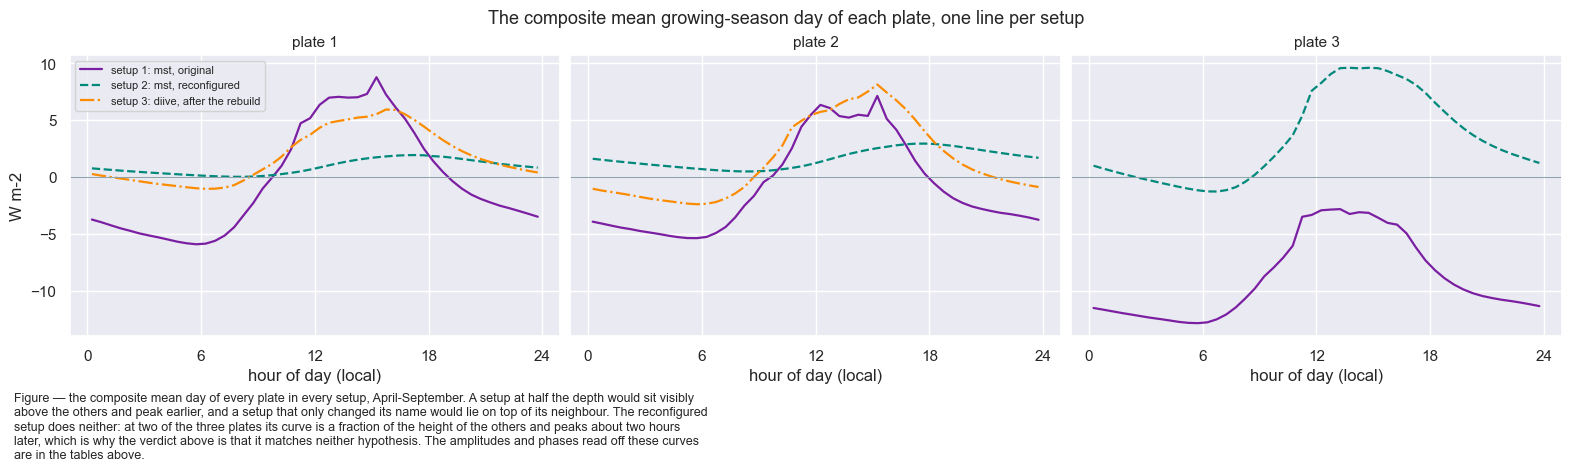

In [29]:
_pairs = [(p, c) for p in PLATES for c in SETUP_NAMES if (p, c) in COMPOSITES]
_plates_drawn = sorted({p for p, _ in _pairs})
fig, axs = plt.subplots(ncols=len(_plates_drawn), figsize=(5.2 * len(_plates_drawn), 4.6),
                        dpi=100, layout='constrained', sharey=True, squeeze=False)
fig.suptitle('The composite mean growing-season day of each plate, one line per setup', fontsize=13)
_style = {FLAG_MST_ORIGINAL: ('#7B1FA2', '-', f'setup 1: {SETUP_NAMES[FLAG_MST_ORIGINAL]}'),
          FLAG_MST_RECONFIGURED: ('#00897B', '--',
                                  f'setup 2: {SETUP_NAMES[FLAG_MST_RECONFIGURED]}'),
          FLAG_DIIVE_005: ('#FB8C00', '-.', f'setup 3: {SETUP_NAMES[FLAG_DIIVE_005]}')}
for _ax, p in zip(axs[0], _plates_drawn):
    for _code, (_col, _ls, _lbl) in _style.items():
        if (p, _code) not in COMPOSITES:
            continue
        _cg = COMPOSITES[(p, _code)][0]
        _ax.plot(_cg.index, _cg.values, color=_col, ls=_ls, lw=1.6, label=_lbl)
    _ax.axhline(0, color='#90A4AE', lw=0.8)
    _ax.set_xlabel('hour of day (local)')
    _ax.set_title(f'plate {p}', fontsize=11)
    _ax.set_xticks(range(0, 25, 6))
axs[0][0].set_ylabel('W m-2')
axs[0][0].legend(fontsize=8, loc='upper left')
figcap(fig, 'the composite mean day of every plate in every setup, April-September. A setup at '
            'half the depth would sit visibly above the others and peak earlier, and a setup that '
            'only changed its name would lie on top of its neighbour. The reconfigured setup does '
            'neither: at two of the three plates its curve is a fraction of the height of the '
            'others and peaks about two hours later, which is why the verdict above is that it '
            'matches neither hypothesis. The amplitudes and phases read off these curves are in '
            'the tables above.')

### Additive and multiplicative

`09` faced a version of this choice for soil moisture and settled it with the within-month spread.
Here the answer is that **both** terms are needed, and the table below is what establishes it.

A heat flux plate reports `gain * true + offset`. The two terms do different work and are visible in
different statistics, which is what makes it possible to fit them one after the other:

- the **gain** shows in the spread. It is what a change of plate, of multiplier or of depth moves,
  and the within-month standard deviation measures it. A gain is blind to the offset, because
  adding a constant to a series does not change its standard deviation, so the gain can be fitted
  first without knowing the offset.
- the **offset** shows in the level. Physics fixes what that level should be: over a year the soil
  returns to roughly the temperature it started at, so the mean of a soil heat flux record at a few
  centimetres must sit near zero.

An earlier version of this notebook fitted only the gain, on the argument that an additive
difference between two setups is a difference between two small numbers of unstable sign. The table
below falsifies that for the original acquisition, whose mean sits several W m-2 below the reference
setup's **at every plate and with the same sign**, and the section above shows it walking year by
year at one plate. Two setups do satisfy the near-zero constraint to a few tenths of a W m-2, which
is what shows the constraint is met when the instrument is sound, and therefore that missing it by
several W m-2 is the instrument rather than the soil.

So the correction has two terms: the gain puts the amplitudes on one scale, and the offset puts the
zero where physics says it must be. What a single constant cannot do is follow a zero point that
moves, and the section *Putting the three setups on one scale* measures the trend that survives the
correction and says so.

The cell below turns the argument into a check that can fail. If the mean differences ever come back
small and of unstable sign, the offset is unnecessary and the cell says so, rather than the prose
asserting either way.

In [30]:
_rows = []
for p in PLATES:
    _ref = g[field(p)].where(g[flagcol(p)] == REFERENCE_FLAG).dropna()
    if _ref.empty:
        continue
    _sd_ref = float(_ref.groupby([_ref.index.year, _ref.index.month]).std().mean())
    _mu_ref = float(_ref.mean())
    for _code in (FLAG_MST_ORIGINAL, FLAG_MST_RECONFIGURED):
        _src = g[field(p)].where(g[flagcol(p)] == _code).dropna()
        if _src.empty:
            continue
        _sd_src = float(_src.groupby([_src.index.year, _src.index.month]).std().mean())
        _mu_src = float(_src.mean())
        _rows.append({'plate': p, 'flag': _code, 'setup': SETUP_NAMES[_code],
                      'sd_within_month': round(_sd_src, 3),
                      'sd_within_month_reference': round(_sd_ref, 3),
                      'sd_ratio': round(_sd_ref / _sd_src, 3),
                      'mean': round(_mu_src, 3), 'mean_reference': round(_mu_ref, 3),
                      'mean_difference': round(_mu_ref - _mu_src, 3)})
VARTAB = pd.DataFrame(_rows).set_index(['plate', 'flag'])
tabcap('the within-month spread and the mean of each setup against the reference setup. The spread '
       'ratio is what the gain removes and the mean difference is what the additive constant '
       'removes, and the check below is whether the second term is needed at all.')
display(VARTAB)

print(f"spread ratios span {VARTAB['sd_ratio'].min():.3f} .. {VARTAB['sd_ratio'].max():.3f}")
print(f"mean differences span {VARTAB['mean_difference'].min():+.3f} .. "
      f"{VARTAB['mean_difference'].max():+.3f} W m-2")

# The escape clause of an earlier version of this notebook was "the means are small and of unstable
# sign". That is a testable statement, so it is tested here per setup rather than asserted in
# prose. A setup whose mean differences are large AND all of one sign has an offset, and saying so
# is the point of this cell.
OFFSET_MATTERS_WM2 = 1.0
for _code, _grp in VARTAB.groupby(level='flag'):
    _d = _grp['mean_difference']
    _consistent = bool((_d > 0).all() or (_d < 0).all())
    _large = bool(_d.abs().min() > OFFSET_MATTERS_WM2)
    print(f"\nsetup {_code} ({SETUP_NAMES[int(_code)]}): mean differences "
          f"{', '.join(f'{_v:+.2f}' for _v in _d)} W m-2")
    if _large and _consistent:
        print(f"  Large at every plate and all of one sign, so this setup differs from the "
              f"reference in its\n  ZERO POINT as well as in its spread, and an additive term is "
              f"needed as well as a gain.")
    elif _consistent:
        print(f"  All of one sign but under {OFFSET_MATTERS_WM2} W m-2 at some plate: a zero-point "
              f"difference this small\n  would be within what the reference setup's own years "
              f"scatter by.")
    else:
        print("  Not consistent in sign across the plates, which is what a near-zero mean with no "
              "offset\n  looks like. An additive term for this setup would be fitting noise.")

print("\nThe homogenisation below applies BOTH terms: a multiplicative gain per calendar month, "
      "fitted on\nthe within-month spread, and then one additive constant per setup, fitted on the "
      "season-matched\nlevel. The gain is fitted first because a standard deviation does not see "
      "an offset, so the gain\nis the same whether or not the offset has been removed.")

Table — the within-month spread and the mean of each setup against the reference setup. The spread
ratio is what the gain removes and the mean difference is what the additive constant removes, and
the check below is whether the second term is needed at all.



setup  sd_within_month  sd_within_month_reference  sd_ratio   mean  mean_reference  mean_difference
plate flag                                                                                                                 
1     1         mst, original            6.872                      3.619     0.527 -3.760          -0.114            3.647
      2     mst, reconfigured            1.377                      3.619     2.629 -0.102          -0.114           -0.012
2     1         mst, original            6.108                      4.614     0.755 -3.268          -0.378            2.890
      2     mst, reconfigured            1.944                      4.614     2.374  0.016          -0.378           -0.394

spread ratios span 0.527 .. 2.629
mean differences span -0.394 .. +3.647 W m-2

setup 1 (mst, original): mean differences +3.65, +2.89 W m-2
  Large at every plate and all of one sign, so this setup differs from the reference in its
  ZERO POINT as well as in its spread, and an additive term is needed as well as a gain.

setup 2 (mst, reconfigured): mean differences -0.01, -0.39 W m-2
  All of one sign but under 1.0 W m-2 at some plate: a zero-point difference this small
  would be within what the reference setup's own years scatter by.

The homogenisation below applies BOTH terms: a multiplicative gain per calendar month, fitted on
the within-month spread, and then one additive constant per setup, fitted on the season-matched
level. The gain is fitted first because a standard deviation does not see an offset, so the gain
is the same whether or not the offset has been removed.


***

## ✴️ Corrections

One correction is applied in this section, and it removes values rather than altering them: records
that fall outside the physical band.

The band is deliberately wide, because each plate's own absolute limits were already applied in
`20_SCREENING/G/`. All this band has to catch is a wrong unit, a wrong sensitivity, or a decoding
failure that survived screening. So if it removes anything at all, that is a question for the
screening notebook rather than a routine cleanup here.

Values are removed and never clipped. Clipping a bad record to the edge of the band would replace it
with a number that looks plausible and that nothing downstream could identify as false. A removed
record becomes flag `0` rather than getting a new code, because the flag vocabulary says what
measured a value, and a decoding failure measured nothing.

In [31]:
print("Removing values outside the physical band "
      f"{G_PLAUSIBLE_WM2[0]}..{G_PLAUSIBLE_WM2[1]} W m-2 (removed, never clipped):\n")

_rows = []
for p in PLATES:
    f, fc = field(p), flagcol(p)
    bad = g[f].notna() & ~g[f].between(*G_PLAUSIBLE_WM2)
    n = int(bad.sum())
    if n:
        for _code in sorted(g.loc[bad, fc].unique()):
            _m = bad & (g[fc] == _code)
            _rows.append({'plate': p, 'flag': int(_code), 'setup': ALL_FLAG_NAMES[int(_code)],
                          'n_removed': int(_m.sum()), 'min': round(float(g.loc[_m, f].min()), 3),
                          'max': round(float(g.loc[_m, f].max()), 3),
                          'first': g.index[_m][0], 'last': g.index[_m][-1]})
        g.loc[bad, f] = np.nan
        g.loc[bad, fc] = FLAG_NOT_MEASURED
    print(f"  {f:<20} removed {n:>5,}")

REMOVED = pd.DataFrame(_rows)
if len(REMOVED):
    tabcap('every record removed for lying outside the physical band, by plate and setup. This '
           'band is a guard against a unit or sensitivity error, so anything it catches is a '
           'question for the screening notebook that let it through.')
    display(REMOVED.set_index(['plate', 'flag']))
else:
    print("\nNothing outside the band, which is the expected result: the screening notebooks "
          "applied\neach plate's own absolute limits before this product read the record.")

for p in PLATES:
    assert (g[field(p)].notna() == g[flagcol(p)].isin(MEASURED_FLAGS)).all(), \
        f"plate {p}: flag and value disagree after the removal"
    assert g[field(p)].dropna().between(*G_PLAUSIBLE_WM2).all(), \
        f"plate {p}: a value survived outside the band"
print("\nFlag and value still agree at every plate, and nothing outside the band survives.")

Removing values outside the physical band -200.0..250.0 W m-2 (removed, never clipped):

  G_FF1_0.05_1         removed     0
  G_FF1_0.05_2         removed     0
  G_FF1_0.05_3         removed     0

Nothing outside the band, which is the expected result: the screening notebooks applied
each plate's own absolute limits before this product read the record.

Flag and value still agree at every plate, and nothing outside the band survives.


### What is *not* corrected, and why

| correction applied elsewhere in `30_PRODUCTS/` | applied here? | why |
|---|---|---|
| nighttime zero-offset (`01`, `03`) | no | That correction works because incoming radiation really is zero at night. Soil heat flux at night is not zero, it is at its most negative, so forcing night to zero would delete half of the daily cycle. |
| +15.5 h clock shift, Aug 2012 (`01`-`05`) | no, and the question stays open | The shift is a fault of the tower logger. These plates hang off the forest-floor logger, and both `09` and `10` establish that the 2012 tower faults do not carry over to this station unless the evidence says so. Soil heat flux does have a daily cycle that could in principle be used to detect a clock error, but only against a reference with a trustworthy clock of its own, and the soil thermistors share the same logger. It is listed in the closing notes instead. |
| removal of the 2012 damaged periods (`01`-`05`) | no | Deleting sound data because a different system failed would be superstition. Where the forest-floor logger did share the fault, the coverage table already shows a gap. |
| unit harmonisation (`05`) | no | All three setups carry one unit tag and no stored offset, and the magnitudes match the tag. All three are checked above. |
| gap-filling (`01`-`03`, `08`) | no | There is no soil heat flux reference near this plot, and the gaps are dead loggers and a rebuild rather than weather. See *What is not filled*. |
| rescaling a setup in place | no | The setups are scaled, but only into `G_FF1_0.05_HOMOGENIZED`. The measured columns keep the values that were measured. |
| removing the 2012 reconfiguration block | no | Those records are real readings of a station whose logger program was being rewritten, and the fieldbook says so. They are flagged `4`, kept out of every fit and out of the reconciled column, and exported with their values intact. Deleting them would hide a month of site history; passing them on unflagged would put a daily mean of tens of W m-2 into a soil heat flux record. |
| removing a plate's zero-point offset from the measured columns | no | The original acquisition sits several W m-2 below the reference setup at every plate, which *Additive and multiplicative* measures, and the correction removes it — but into `G_FF1_0.05_HOMOGENIZED` only. A measured column keeps what was measured, exactly as the plate reported it. |

: Each correction that other notebooks in this folder apply, and why this one does or does not apply
it. {#tbl-corrections}

::: {.callout-note title="The trap from notebook 03"}
Notebook `03` once had a correction that wrote values into gaps, and it turned 7,543 modelled
records into records that looked measured. The same trap here would be a gain applied to a record
that holds no measurement.

It is closed by construction rather than by care. The gains multiply `G_FF1_0.05_<n>`, which is
`NaN` wherever there is a gap, and `NaN` times a gain is still `NaN`. The export then asserts that
the reconciled column holds a value in exactly those records where at least one plate does. So the
only correction in this notebook that touches measured values is the one that removes them.
:::

***

## 🧭 25 June 2015: soil moisture stepped. Did the plates?

`09` finds one discontinuity in the pre-2020 soil moisture record that can be dated: a drop of about
3.9 % VWC on 25 June 2015, at every depth within one hour, which it attributes to work on the
forest-floor logger's wiring. `10` looks for the same thing in soil temperature at the same
half-hour and finds nothing, and that is what places the fault in the soil moisture chain rather
than in the station as a whole.

The plates hang off that same logger, through the same enclosure and the same power supply, so the
question has to be asked here too. It is not quite the same question as in `09`, though. Soil
moisture is a state variable, so a rewiring shows up as a step in its level. Soil heat flux swings
about zero, so a rewiring would show up as a change in the size of that swing instead. The statistic
below is therefore the ratio of the spread after the date to the spread before it.

A ratio on its own would say nothing, because the spread of `G` changes from week to week with the
weather. So the ratio is compared against the same ratio at the same day of the year in every other
year the plate measured. That is the only comparison that knows how much this ratio normally moves
in late June.

::: {.callout-note title="A null of a dozen years reports a rank, not a percentile"}
The comparison is against a dozen or so other years, the exact number depending on how many the
plate covers, so the finest thing it can say is where the observation ranks among them. Two
neighbouring ranks are several percentage points apart - the cell prints how many for each plate -
and a percentile quoted to a tenth of a point invites a precision the null does not have.

That matters for the threshold as well as for the reporting. A percentile threshold closer to 100
than the distance between two ranks can only ever be met by the single largest value, which turns a
tail test into a maximum test without saying so. An earlier version of this notebook compared
against 97.5 while the null could resolve no more than 94.1, and it therefore called a plate at the
second-highest rank of eighteen unremarkable.

So both tests below are ranks. The verdict asks whether the observation is the most extreme late
June that plate has had, which is the only thing this null separates cleanly. The edge test asks
whether it is within one resolvable rank of the top, and its percentile equivalent is derived from
each plate's own null size, with an assertion that it is reachable. The question itself is
one-sided, because a rewiring would raise the spread and not lower it, so a plate one rank below the
top has not been cleared.
:::

In [32]:
FF_WIRING_BREAK = '2015-06-25 08:45'   # the timestamp 09 derives; used here, not re-derived
BREAK_WINDOW_DAYS = 60

# A null of a dozen or so years can report a RANK and nothing finer. Its smallest percentile step is
# 100/n, so a threshold set closer to 100 than that can only ever be met by the single largest value
# in the null - which silently turns a tail test into a maximum test. An earlier version of this
# notebook did exactly that: it compared a percentile against 97.5 while the null could resolve no
# more than 94.1, and so reported a plate at the second-highest rank of eighteen as unremarkable.
#
# Both tests below are therefore written as RANKS, and their percentile equivalents are derived from
# each plate's own null size rather than chosen.
BREAK_TAIL_STEPS = 1        # at the edge = within this many resolvable ranks of the top
BREAK_MIN_NULL_YEARS = 8    # below this, a rank inside the null carries no information at all


def spread_ratio_at(series: pd.Series, when, days: int = BREAK_WINDOW_DAYS):
    """Ratio of the within-window standard deviation after `when` to the one before it.

    Returns NaN where either window holds fewer than half its possible records, so a ratio is never
    computed across a gap and then read as a change in the instrument.
    """
    when = pd.Timestamp(when)
    before = series.loc[when - pd.Timedelta(days=days):when].dropna()
    after = series.loc[when:when + pd.Timedelta(days=days)].dropna()
    need = days * 48 * 0.5
    if len(before) < need or len(after) < need or float(before.std()) == 0:
        return np.nan
    return float(after.std() / before.std())


_rows = []
for p in PLATES:
    _s = g[field(p)]
    _obs = spread_ratio_at(_s, FF_WIRING_BREAK)
    # The null: the same day of the year, every other year this plate measured.
    _null = []
    for _y in range(_s.first_valid_index().year, _s.last_valid_index().year + 1):
        if _y == pd.Timestamp(FF_WIRING_BREAK).year:
            continue
        _r = spread_ratio_at(_s, pd.Timestamp(FF_WIRING_BREAK).replace(year=_y))
        if np.isfinite(_r):
            _null.append(_r)
    _n = len(_null)
    if not _n or not np.isfinite(_obs):
        _rows.append({'plate': p, 'spread_ratio_2015': np.nan, 'n_null_years': _n,
                      'n_compared': _n + 1, 'null_median': np.nan, 'rank_from_top': np.nan,
                      'rank_from_bottom': np.nan, 'percentile_in_null': np.nan,
                      'resolution_pct': np.nan, 'edge_pct': np.nan})
        continue
    _arr = np.asarray(_null, dtype=float)
    # Rank of the observation among itself plus its null: 1 means the largest of them all. A tie
    # does not demote it, which is the conservative direction for a test looking for an unusually
    # LARGE change in spread.
    _rank_top = 1 + int((_arr > _obs).sum())
    _rank_bot = 1 + int((_arr < _obs).sum())
    _pct = 100.0 * float((_arr <= _obs).mean())
    _res = 100.0 / _n                              # the finest percentile difference this null has
    _edge = 100.0 - BREAK_TAIL_STEPS * _res        # reachable by construction, unlike a constant
    _rows.append({'plate': p, 'spread_ratio_2015': round(_obs, 3), 'n_null_years': _n,
                  'n_compared': _n + 1, 'null_median': round(float(np.median(_arr)), 3),
                  'rank_from_top': _rank_top, 'rank_from_bottom': _rank_bot,
                  'percentile_in_null': round(_pct, 1),
                  # kept unrounded: the reachability assertion below compares the two against each
                  # other, and rounding them apart would make it fire on nothing but arithmetic
                  'resolution_pct': _res, 'edge_pct': _edge})
BREAKTAB = pd.DataFrame(_rows).set_index('plate')

# The verdict, as a rank. A null of this size can separate "the most extreme of them all" from "not
# the most extreme" and nothing finer, because every other threshold falls inside one resolvable
# step of the end of the distribution. Saying so is not a relaxation: the (5, 95) percentile band an
# earlier version used amounted to exactly this test at this null size, while looking finer than it
# was.
BREAKTAB['is_extreme'] = ((BREAKTAB['rank_from_top'] == 1)
                          | (BREAKTAB['rank_from_bottom'] == 1))
BREAKTAB['at_edge'] = BREAKTAB['rank_from_top'] <= 1 + BREAK_TAIL_STEPS
BREAKTAB['verdict'] = np.where(
    BREAKTAB['spread_ratio_2015'].isna(), 'not judged (a window is too empty)',
    np.where(BREAKTAB['is_extreme'], '(!) the most extreme late June this plate has had',
             np.where(BREAKTAB['at_edge'], 'at the edge of what this null can resolve',
                      'ordinary for late June')))
tabcap('the change in spread across 25 June 2015 at each plate, placed among the same change at '
       'the same day of the year in every other year that plate measured. The rank is what a null '
       'of this size can report; the percentile beside it is that rank written as a fraction, and '
       '`resolution_pct` is the distance between two neighbouring ranks, which is the finest '
       'difference the percentile column is able to mean.')
display(BREAKTAB.round(2))

# Reachability. A threshold closer to 100 than one resolvable step can never be met by anything but
# the single largest value, so a null too small for its threshold disables the test in silence. The
# first assertion fires when the record shrinks; the second is the regression guard, and fires if
# `edge_pct` is ever replaced by a constant.
_judged = BREAKTAB.dropna(subset=['spread_ratio_2015'])
assert len(_judged) > 0, "no plate could be judged at all against 25 June 2015"
for _p, _r in _judged.iterrows():
    assert int(_r['n_null_years']) >= BREAK_MIN_NULL_YEARS, (
        f"plate {_p} has only {int(_r['n_null_years'])} null years, fewer than "
        f"{BREAK_MIN_NULL_YEARS}. A rank inside a null that small carries no information, and the "
        f"edge test below would be reporting noise.")
    assert _r['edge_pct'] <= 100.0 - _r['resolution_pct'] + 1e-9, (
        f"plate {_p}: the edge threshold {_r['edge_pct']:.1f} sits closer to 100 than this null "
        f"can resolve ({_r['resolution_pct']:.2f} per rank), so only the single largest value "
        f"could ever meet it. Derive the threshold from the null size rather than setting it.")
print(f"null sizes {sorted(int(_v) for _v in _judged['n_null_years'])}: the finest percentile they "
      f"can resolve is\n{_judged['resolution_pct'].min():.2f} to "
      f"{_judged['resolution_pct'].max():.2f} points, and the edge test therefore sits at "
      f"{_judged['edge_pct'].min():.1f} to {_judged['edge_pct'].max():.1f}.\nBoth are reachable, "
      f"which is what the assertions above check.")

_flagged = _judged[_judged['is_extreme']]
_edge = _judged[_judged['at_edge'] & ~_judged['is_extreme']]
if len(_flagged):
    print(f"\n(!) {len(_flagged)} plate(s) change spread across 25 June 2015 by more than late June "
          f"has ever done at\nthat plate. That makes the rewiring a candidate discontinuity INSIDE "
          f"the reconfigured setup,\nwhich the per-month gains below cannot represent - they fit "
          f"one factor to the whole setup.\nRecorded here rather than corrected, and carried into "
          f"the closing notes.")
elif len(_edge) >= 2:
    _where = ', '.join(f"plate {_p} ranks {int(_r['rank_from_top'])} of {int(_r['n_compared'])}"
                       for _p, _r in _edge.iterrows())
    print(f"\nNo plate has its most extreme late June here, so nothing is measured as a "
          f"discontinuity. But\n{len(_edge)} plates sit within one resolvable rank of the top: "
          f"{_where}.\nThat is as close to the edge as a null of this size can put anything short "
          f"of the maximum.")
    print("The question is one-sided, because a rewiring would RAISE the spread and not lower it, "
          "so only\nthe upper end is doing any work here and a plate one rank below the top has "
          "not been cleared.\nTwo plates arriving there independently is weak but real evidence "
          "that 25 June 2015 did reach\nthe plates. It is too weak to correct on and it is not "
          "measured as a step, so the honest\nstatement is that this date sits at the edge of what "
          "this null can resolve. That is what the\nclosing notes say, as an open question rather "
          "than as a negative result.")
else:
    print("\nNo plate has its most extreme late June here, and fewer than two sit within one "
          "resolvable rank\nof the top. The rewiring that moved soil moisture left no trace this "
          "test can see in the plates,\nwhich matches what 10 finds for soil temperature and keeps "
          "the fault in the soil-moisture chain.")
print(f"\nThe fieldbook, asked afterwards:")
fieldbook_near(FF_WIRING_BREAK, days=3)

Table — the change in spread across 25 June 2015 at each plate, placed among the same change at the
same day of the year in every other year that plate measured. The rank is what a null of this size
can report; the percentile beside it is that rank written as a fraction, and `resolution_pct` is the
distance between two neighbouring ranks, which is the finest difference the percentile column is
able to mean.



,spread_ratio_2015,n_null_years,n_compared,null_median,rank_from_top,rank_from_bottom,percentile_in_null,resolution_pct,edge_pct,is_extreme,at_edge,verdict
plate,,,,,,,,,,,,
1,1.29,17,18,0.95,2,17,94.1,5.88,94.12,False,True,at the edge of what this null can resolve
2,1.19,17,18,0.96,2,17,94.1,5.88,94.12,False,True,at the edge of what this null can resolve
3,1.17,12,13,1.02,3,11,83.3,8.33,91.67,False,False,ordinary for late June


null sizes [12, 17, 17]: the finest percentile they can resolve is
5.88 to 8.33 points, and the edge test therefore sits at 91.7 to 94.1.
Both are reachable, which is what the assertions above check.

No plate has its most extreme late June here, so nothing is measured as a discontinuity. But
2 plates sit within one resolvable rank of the top: plate 1 ranks 2 of 18, plate 2 ranks 2 of 18.
That is as close to the edge as a null of this size can put anything short of the maximum.
The question is one-sided, because a rewiring would RAISE the spread and not lower it, so only
the upper end is doing any work here and a plate one rank below the top has not been cleared.
Two plates arriving there independently is weak but real evidence that 25 June 2015 did reach
the plates. It is too weak to correct on and it is not measured as a step, so the honest
statement is that this date sits at the edge of what this null can resolve. That is what the
closing notes say, as an open question rather than a

***

## ⚖️ Putting the three setups on one scale

::: {.callout-important title="Read this before using the reconciled column"}
`08` was able to rescale one precipitation era onto another because an independent gauge measured
straight through the break, and that anchor is what made its factors defensible. There is no such
anchor here. No service measures soil heat flux at this plot, the setups do not overlap by even one
half-hour, and all three plates change together at both boundaries, so they cannot check each other
either.

Both terms therefore come from climatology alone: the gain month by month, as the ratio between the
reference setup's within-month spread and the source setup's, and then one additive constant per
setup, as the season-matched difference in level that survives the gain. That rests on three
assumptions, and none of them can be tested with the data in this product.

1. That the three periods had the same monthly soil heat flux climate. If 2004-2011, 2012-2021 and
   2021-2025 genuinely differed, because the summers ran differently or the canopy grew, that
   difference is absorbed into the correction and then reissued as though it were an instrument
   correction. The offset has one anchor the gain does not: physics says a year of soil heat flux
   must average near zero, and two of the three setups satisfy that on their own. So the offset is
   pinned by something outside the record as well as by the reference setup, while the gain is not.
2. That each setup is internally consistent. The reconfigured setup spans nine years and contains
   one candidate discontinuity, which the section above tests. If that test comes back positive,
   then a single factor per calendar month describes the setup on neither side of it. The hold-out
   check below tests the same assumption in a second way, by fitting the gains on half the years
   and scoring them on the other half.
3. That the diive setup is the right thing to scale onto. It was chosen because it is modern, still
   running and screened by diive, and its own annual means sit within a few tenths of a W m-2 of
   zero. That last fact is the only positive evidence that any setup's zero point is sound, and it
   is what the offsets below are measured against.

So `G_FF1_0.05_HOMOGENIZED` exists for continuity across the 2012 and 2021 boundaries. Within a
single setup it tells you nothing that the measured columns do not.
:::

The correction has two terms and they are applied in this order:

1. a **multiplicative gain** per calendar month, fitted on the within-month spread, which puts the
   amplitudes of the three setups onto one scale;
2. a **single additive constant** per plate per setup, fitted on the season-matched level of the
   *gained* series, which puts the zero where physics says it must be.

The order matters and the second step has to be measured after the first, because multiplying a
series whose mean is not zero moves that mean as well: part of what the constant removes is a level
the gain itself introduced. Fitting in this order is algebraically the same as subtracting a raw
offset before the gain, and it is the order in which the printed numbers can be read.

One constant per setup, not one per calendar month. The zero point of a plate is a property of the
instrument and does not know what month it is; it is *estimated* season-matched, comparing like
calendar months so that the setups' different year and season coverage cannot leak in, but it is
*applied* flat.

What neither term can do is repair a change of timing. The reconfigured setup's composite day peaks
about two hours later than the original one's, and no gain and no constant moves a peak.

In [33]:
# A copy of every measured column, taken before the correction is derived. The measured columns
# must come out of this section exactly as they went in, and comparing against a copy is the only
# way to say so - a check written against the columns themselves would compare them with themselves.
MEASURED_BEFORE_HOMOG = {p: g[field(p)].copy() for p in PLATES}

GAINS = {}      # {plate: {flag_code: (table, fallback)}}
OFFSETS = {}    # {plate: {flag_code: the single additive constant, in W m-2}}
gained = {}     # {plate: the series after the gain, before the offset}
homog = {}      # {plate: the series after both terms}


def derive_offset(gained_setup: pd.Series, reference: pd.Series, label: str,
                  min_months: int = None):
    """The single additive constant that puts a gained setup onto the reference setup's level.

    Season-matched: each calendar month's mean is taken on its own and the months present in both
    are averaged with equal weight, so the different year and season coverage of two setups cannot
    leak into the constant. ONE number comes back, not twelve, because the zero point of a plate is
    a property of the instrument and does not know what month it is.

    Subtracting the result is what the correction does, so a positive value means the gained setup
    reads high against the reference.

    Raises if too few calendar months are shared, or if the constant lands outside
    HOMOG_OFFSET_BAND_WM2, which is not a zero-point error but a wrong sensitivity or a wrong
    field, and the product should stop rather than ship a series shifted by it.
    """
    min_months = HOMOG_MIN_MONTHS if min_months is None else min_months
    _, src_m = season_level(gained_setup)
    _, ref_m = season_level(reference)
    shared = src_m.index.intersection(ref_m.index)
    if len(shared) < min_months:
        raise ValueError(
            f"{label}: only {len(shared)} calendar month(s) are covered by both the setup and the "
            f"reference. An offset estimated on that is a statement about those months.")
    value = float((src_m[shared] - ref_m[shared]).mean())
    if not abs(value) <= HOMOG_OFFSET_BAND_WM2:
        raise ValueError(
            f"{label}: the offset comes out at {value:+.2f} W m-2, outside "
            f"+/-{HOMOG_OFFSET_BAND_WM2}. A plate's zero point does not move that far; this is a "
            f"wrong sensitivity or a wrong field, not something to subtract.")
    print(f"  {label:<46} offset {value:+7.3f} W m-2 over {len(shared):>2} shared months")
    return value, len(shared)


for p in PLATES:
    ref = g[field(p)].where(g[flagcol(p)] == REFERENCE_FLAG).dropna()
    _scaled = g[field(p)].copy()
    if ref.empty:
        # The discarded plate never reaches the reference setup, so neither term can be fitted for
        # it, and it takes no part in the reconciled column at any point in the record - not before
        # the rebuild either. It keeps its own exported column, which is its own measurement. See
        # the next cell.
        print(f"  plate {p}: no records in the reference setup - neither term can be fitted, and "
              f"it takes no part in the reconciled column")
        GAINS[p], OFFSETS[p] = {}, {}
        gained[p] = pd.Series(np.nan, index=full_index)
        homog[p] = pd.Series(np.nan, index=full_index)
        continue
    GAINS[p], OFFSETS[p] = {}, {}
    for _code in SCALED_FLAGS:
        src = g[field(p)].where(g[flagcol(p)] == _code).dropna()
        if src.empty:
            continue
        _tab, _fb = derive_monthly_gains(src, ref, f'plate {p}  setup {_code} -> setup '
                                                   f'{REFERENCE_FLAG}')
        GAINS[p][_code] = (_tab, _fb)
        _gain_series = pd.Series(_tab['gain'].reindex(g.index.month).to_numpy(), index=g.index)
        _mask = g[flagcol(p)] == _code
        _scaled = _scaled.where(~_mask, g[field(p)] * _gain_series)
    gained[p] = _scaled.where(g[flagcol(p)].isin(SETUP_FLAGS))

    # The gain first, everywhere, then the offset on top of it. The offset is measured on the
    # GAINED series rather than on the raw one, because multiplying a series whose mean is not zero
    # moves that mean too, so part of what the offset removes is the level the gain itself
    # introduced. Fitting the two in this order is algebraically the same as subtracting a raw
    # offset before the gain, and it is the order the printed numbers can be read in.
    _corrected = gained[p].copy()
    for _code in SCALED_FLAGS:
        _gs = gained[p].where(g[flagcol(p)] == _code).dropna()
        if _gs.empty:
            continue
        _off, _nm = derive_offset(_gs, ref, f'plate {p}  setup {_code} -> setup {REFERENCE_FLAG}')
        OFFSETS[p][_code] = _off
        _corrected = _corrected.where(g[flagcol(p)] != _code, gained[p] - _off)
    # The 2012 reconfiguration records belong to no setup, so neither term was fitted for them and
    # neither is applied. They are dropped rather than passed through uncorrected, which would put
    # values on a scale nothing in this notebook has characterised into the reconciled column.
    homog[p] = _corrected.where(g[flagcol(p)].isin(SETUP_FLAGS))

_tabg = pd.DataFrame({f'plate {p}  setup {c}': GAINS[p][c][0]['gain']
                      for p in PLATES for c in GAINS[p]})
_tabg.index.name = 'month'
print()
tabcap('the multiplicative gain applied to each non-reference setup, per calendar month. A gain of '
       '1.00 means that month\'s spread already matches the reference setup and nothing is '
       'changed; a column that varies strongly down the rows is a gain that depends on the season, '
       'which an instrument gain cannot.')
display(_tabg.round(3))

# How much each column varies across the year. An instrument gain does not know what month it is,
# so this ratio is a direct measure of how much season has leaked into the correction.
_spread = (_tabg.max() / _tabg.min()).rename('max / min across the year').to_frame().round(2)
tabcap('how far each setup\'s twelve monthly gains spread across the year. A gain that is a '
       'property of the electronics should be flat down the column; the distance from 1.00 is the '
       'part of the correction that depends on the season rather than on the instrument.')
display(_spread)

OFFSETTAB = pd.DataFrame(
    [{'plate': p, 'flag': c, 'setup': SETUP_NAMES[c], 'offset_wm2': round(OFFSETS[p][c], 3),
      'mean_measured': round(float(g[field(p)].where(g[flagcol(p)] == c).mean()), 3),
      'mean_after_gain': round(float(gained[p].where(g[flagcol(p)] == c).mean()), 3),
      'mean_after_both': round(float(homog[p].where(g[flagcol(p)] == c).mean()), 3),
      'mean_reference': round(float(g[field(p)].where(g[flagcol(p)] == REFERENCE_FLAG).mean()), 3)}
     for p in PLATES for c in OFFSETS[p]]).set_index(['plate', 'flag'])
tabcap('the single additive constant subtracted from each non-reference setup after its gain, with '
       'the setup mean at each stage. One number per plate per setup: the zero point of a plate is '
       'a property of the instrument, so the constant is estimated season-matched but applied flat.')
display(OFFSETTAB)

print(f"offsets span {OFFSETTAB['offset_wm2'].min():+.3f} .. {OFFSETTAB['offset_wm2'].max():+.3f} "
      f"W m-2, inside a band of +/-{HOMOG_OFFSET_BAND_WM2:.0f}")
for _code, _grp in OFFSETTAB.groupby(level='flag'):
    print(f"  setup {int(_code)} ({SETUP_NAMES[int(_code)]}): "
          f"{', '.join(f'{_v:+.2f}' for _v in _grp['offset_wm2'])} W m-2 across the plates")
print("Each plate is corrected on its own and never sees the other's numbers, so offsets of a "
      "similar\nsize at both plates are evidence that what is being removed belongs to the "
      "acquisition rather\nthan to one plate.")
print("The offsets of the reconfigured setup are the ones to read as a check rather than as a "
      "repair:\nthat setup already sat close to the reference before any correction, so a small "
      "constant there is\nthe expected result and a large one would say the gain had moved "
      "something it should not have.")

_worst_spread = float(_spread.iloc[:, 0].max())
print(f"widest spread of monthly gains within one setup: {_worst_spread:.2f}x "
      f"(warning above {HOMOG_GAIN_SPREAD_WARN}x)")
if _worst_spread > HOMOG_GAIN_SPREAD_WARN:
    print("(!) A gain that varies by this much across the calendar is not an instrument gain. Part "
          "of it is\n    the difference between the setups' electronics and part of it is the "
          "difference between the\n    years they cover: a summer with more leaf-off sunflecks, "
          "or a canopy that grew, moves the\n    within-month spread exactly as a multiplier "
          "would. This is the seasonal-climate leakage the\n    callout above names as an "
          "assumption, and here it is realised rather than hypothetical.")
    print("    The per-month form is kept. A single gain per setup would carry less season inside "
          "it and\n    would match each month less closely, and this notebook has not measured "
          "which of the two is\n    the smaller error, so replacing one with the other would be a "
          "guess. What changes is what the\n    reader is told: the reconciled column carries an "
          "unknown amount of climate inside its\n    instrument correction, and the closing notes "
          "say so.")

  plate 1  setup 1 -> setup 3                    12/12 months fitted   gains 0.368 .. 0.562   mean 0.456


  plate 1  setup 2 -> setup 3                    12/12 months fitted   gains 1.801 .. 3.054   mean 2.413
  plate 1  setup 1 -> setup 3                    offset  -1.276 W m-2 over 12 shared months
  plate 1  setup 2 -> setup 3                    offset  +0.133 W m-2 over 12 shared months
  plate 2  setup 1 -> setup 3                    12/12 months fitted   gains 0.483 .. 1.020   mean 0.719


  plate 2  setup 2 -> setup 3                    12/12 months fitted   gains 1.498 .. 2.989   mean 2.335


  plate 2  setup 1 -> setup 3                    offset  -1.291 W m-2 over 12 shared months
  plate 2  setup 2 -> setup 3                    offset  +1.172 W m-2 over 12 shared months
  plate 3: no records in the reference setup - neither term can be fitted, and it takes no part in the reconciled column

Table — the multiplicative gain applied to each non-reference setup, per calendar month. A gain of
1.00 means that month's spread already matches the reference setup and nothing is changed; a column
that varies strongly down the rows is a gain that depends on the season, which an instrument gain
cannot.



,plate 1 setup 1,plate 1 setup 2,plate 2 setup 1,plate 2 setup 2
month,,,,
1,0.445,2.298,0.502,2.171
2,0.485,2.335,0.497,2.175
3,0.547,2.785,0.483,2.044
4,0.562,3.054,0.816,2.989
5,0.499,2.621,1.020,2.983
6,0.412,2.553,0.947,2.891
7,0.368,2.470,0.777,2.485
8,0.433,2.424,0.928,2.663
9,0.453,2.393,0.836,2.363


Table — how far each setup's twelve monthly gains spread across the year. A gain that is a property
of the electronics should be flat down the column; the distance from 1.00 is the part of the
correction that depends on the season rather than on the instrument.



,max / min across the year
plate 1 setup 1,1.53
plate 1 setup 2,1.70
plate 2 setup 1,2.11
plate 2 setup 2,2.00


Table — the single additive constant subtracted from each non-reference setup after its gain, with
the setup mean at each stage. One number per plate per setup: the zero point of a plate is a
property of the instrument, so the constant is estimated season-matched but applied flat.



setup  offset_wm2  mean_measured  mean_after_gain  mean_after_both  mean_reference
plate flag                                                                                                
1     1         mst, original      -1.276         -3.760           -1.681           -0.405          -0.114
      2     mst, reconfigured       0.133         -0.102           -0.018           -0.152          -0.114
2     1         mst, original      -1.291         -3.268           -1.954           -0.663          -0.378
      2     mst, reconfigured       1.172          0.016            0.746           -0.426          -0.378

offsets span -1.291 .. +1.172 W m-2, inside a band of +/-25
  setup 1 (mst, original): -1.28, -1.29 W m-2 across the plates
  setup 2 (mst, reconfigured): +0.13, +1.17 W m-2 across the plates
Each plate is corrected on its own and never sees the other's numbers, so offsets of a similar
size at both plates are evidence that what is being removed belongs to the acquisition rather
than to one plate.
The offsets of the reconfigured setup are the ones to read as a check rather than as a repair:
that setup already sat close to the reference before any correction, so a small constant there is
the expected result and a large one would say the gain had moved something it should not have.
widest spread of monthly gains within one setup: 2.11x (warning above 1.5x)
(!) A gain that varies by this much across the calendar is not an instrument gain. Part of it is
    the difference between the setups' electronics and part of it is the difference between the
    years they cover: a summer with more le

### Does it land where it should?

Both terms land exactly by construction, and for the same reason in each case: the gain is the ratio
of the two spreads, and the offset is the difference of the two season-matched levels. Re-measuring
either on the records it was fitted on is checking arithmetic, so the tables below print those
residuals and the notebook does not call them tests.

Five checks carry weight instead:

- the **reference setup is untouched** by either term;
- the **measured columns are unchanged** - the correction exists only in the homogenised path;
- **neither term writes into a gap**, and the records of the 2012 reconfiguration, which belong to
  no setup, stay out of the corrected series;
- the **gain preserves the sign of every record**, which is a property of multiplication by a
  positive number and is where a misaligned gain series would show. The offset deliberately does
  not preserve it: shifting a signed flux is meant to move records across zero, so that check is
  made on the gained series, before the offset;
- two **hold-outs**, one per term: each is refitted on half the years of a setup and scored on the
  years it never saw. These can fail, and they ask the question a fitted residual cannot - whether a
  constant fitted on some years describes the others.

In [34]:
_rows = []
for p in PLATES:
    if not GAINS[p]:
        continue
    _ref = g[field(p)].where(g[flagcol(p)] == REFERENCE_FLAG).dropna()
    for _code, (_tab, _fb) in GAINS[p].items():
        _sh = homog[p].where(g[flagcol(p)] == _code).dropna()
        _fitted = _tab.index[_tab['fitted']]
        _a = _sh.groupby(_sh.index.month).std().reindex(_fitted)
        _b = _ref.groupby(_ref.index.month).std().reindex(_fitted)
        _lvl_after, _ = season_level(_sh)
        _lvl_ref, _ = season_level(_ref)
        _rows.append({'plate': p, 'flag': _code, 'months_fitted': len(_fitted),
                      'max_rel_residual': float(((_a - _b) / _b).abs().max()),
                      'sd_before': round(float(g[field(p)].where(g[flagcol(p)] == _code).std()), 3),
                      'sd_after': round(float(_sh.std()), 3),
                      'sd_reference': round(float(_ref.std()), 3),
                      'mean_before': round(float(g[field(p)].where(g[flagcol(p)] == _code).mean()), 3),
                      'mean_after': round(float(_sh.mean()), 3),
                      'level_after': round(_lvl_after, 3),
                      'level_reference': round(_lvl_ref, 3),
                      'level_residual': round(_lvl_after - _lvl_ref, 9)})
LANDING = pd.DataFrame(_rows).set_index(['plate', 'flag'])
tabcap('each corrected setup against the reference setup: the spread residual in the months the '
       'gains were fitted on and the season-matched level residual after the offset, both zero by '
       'construction and printed rather than tested, beside the spread and the mean before and '
       'after the correction.')
display(LANDING.round(6))
print(f"in-sample spread residual: {float(LANDING['max_rel_residual'].max()):.2e}; in-sample level "
      f"residual: {float(LANDING['level_residual'].abs().max()):.2e}.")
print("Both are zero, and neither could be anything else: the gain IS the ratio of the two spreads "
      "and\nthe offset IS the difference of the two season-matched levels. They are printed so "
      "that the\narithmetic is visible, and the hold-outs below are what test the correction.")

# The reference setup must be untouched by EITHER term. An assertion that states what a correction
# does, so a future change to the correction breaks it - which is the system working.
for p in PLATES:
    _ref_mask = g[flagcol(p)] == REFERENCE_FLAG
    if not _ref_mask.any():
        continue
    assert gained[p].where(_ref_mask).equals(g[field(p)].where(_ref_mask)), \
        f"plate {p}: the reference setup was modified by the gain"
    assert homog[p].where(_ref_mask).equals(g[field(p)].where(_ref_mask)), \
        f"plate {p}: the reference setup was modified by the offset"
    # ... and neither term turns a gap into a value. The corrected series holds a value in exactly
    # the records that were measured AND belong to a setup: the 2012 reconfiguration records are
    # measured but belong to none, so they are the one deliberate difference.
    _in_setup = g[field(p)].notna() & g[flagcol(p)].isin(SETUP_FLAGS)
    assert gained[p].notna().equals(_in_setup) and homog[p].notna().equals(_in_setup), (
        f"plate {p}: the corrected series is non-null in different records than the measured "
        f"records that belong to a setup")
print("\nThe reference setup is untouched by either term at every plate, and neither wrote a value "
      "into a gap.")

# The measured columns must be exactly what they were before this section ran. The correction lives
# in the homogenised path only, and this is the assertion that says so.
for p in PLATES:
    assert g[field(p)].equals(MEASURED_BEFORE_HOMOG[p]), (
        f"plate {p}: the measured column changed while the setups were being put on one scale. "
        f"The correction belongs in the homogenised path only.")
print("Every measured column is bit-identical to what it held before the correction was derived.")

# The GAIN cannot move a record across zero, because every gain is positive, and a misaligned gain
# series is exactly what would break that. The OFFSET is meant to move records across zero - that
# is what shifting the zero point of a signed flux does - so the check is made before it.
for p in PLATES:
    if not GAINS[p]:
        continue
    _both = g[field(p)].notna() & gained[p].notna()
    assert (np.sign(g.loc[_both, field(p)]) == np.sign(gained[p][_both])).all(), (
        f"plate {p}: a gained record has a different sign from the record it came from. Every gain "
        f"is positive, so this means the gain series is misaligned against the records it "
        f"multiplies.")
print("Every gained record keeps the sign of the record it came from, at every plate. The offset "
      "then\nmoves records across zero on purpose, which is what correcting a zero point means, "
      "and how many\nit moves is reported below.")

_moved = {p: int(((np.sign(gained[p]) != np.sign(homog[p])) & gained[p].notna()).sum())
          for p in PLATES if GAINS[p]}
_n_corrected = {p: int(homog[p].notna().sum()) for p in _moved}
print("records the offset moved across zero: "
      + ', '.join(f"plate {p} {_moved[p]:,} of {_n_corrected[p]:,} "
                  f"({100 * _moved[p] / max(_n_corrected[p], 1):.1f} %)" for p in _moved))

# --- the hold-out: gains fitted on half the years, scored on the other half ---------------------
_rows = []
for p in PLATES:
    if not GAINS[p]:
        continue
    _ref = g[field(p)].where(g[flagcol(p)] == REFERENCE_FLAG).dropna()
    for _code in GAINS[p]:
        _src = g[field(p)].where(g[flagcol(p)] == _code).dropna()
        _fit_years = _src[_src.index.year % 2 == 1]
        _test_years = _src[_src.index.year % 2 == 0]
        if _fit_years.empty or _test_years.empty:
            continue
        _tab_ho, _ = derive_monthly_gains(_fit_years, _ref, f'plate {p} setup {_code} (hold-out)',
                                          verbose=False)
        _scaled_ho = _test_years * pd.Series(
            _tab_ho['gain'].reindex(_test_years.index.month).to_numpy(), index=_test_years.index)
        _a = _scaled_ho.groupby(_scaled_ho.index.month).std()
        _b = _ref.groupby(_ref.index.month).std()
        _common = _a.index.intersection(_b.index)
        _rel = ((_a[_common] - _b[_common]) / _b[_common])
        _rows.append({'plate': p, 'flag': _code, 'setup': SETUP_NAMES[_code],
                      'months': len(_common),
                      'mean_rel_residual': round(float(_rel.mean()), 3),
                      'max_abs_rel_residual': round(float(_rel.abs().max()), 3),
                      'worst_month': int(_rel.abs().idxmax())})
HOLDOUT = pd.DataFrame(_rows).set_index(['plate', 'flag'])
tabcap('the hold-out: gains fitted on the odd years of a setup and applied to its even years, '
       'scored against the reference spread the fit never saw. Unlike the in-sample residual, '
       'this one can fail, and it asks whether a gain fitted for a calendar month describes that '
       'month in a year the fit did not see.')
display(HOLDOUT)

_ho_worst = float(HOLDOUT['max_abs_rel_residual'].max())
print(f"\nworst held-out departure: {100 * _ho_worst:.0f} % (tolerance "
      f"{100 * HOMOG_HOLDOUT_TOL:.0f} %, wall {100 * HOMOG_HOLDOUT_WALL:.0f} %)")
_ho_bad = HOLDOUT[HOLDOUT['max_abs_rel_residual'] > HOMOG_HOLDOUT_TOL]
if len(_ho_bad):
    print(f"(!) {len(_ho_bad)} of {len(HOLDOUT)} setup-plate combinations miss the tolerance. The "
          f"per-month gains do NOT\n    generalise inside their own setup: a month's gain fitted "
          f"on one half of the years does not\n    describe the other half. That is the same "
          f"finding as the seasonal spread of the gains above,\n    seen from the other side - "
          f"what varies month to month also varies year to year, so it is\n    weather rather "
          f"than electronics.")
    for (_p, _c), _r in _ho_bad.iterrows():
        print(f"    plate {_p}, setup {_c}: worst month {_r['worst_month']:>2}, "
              f"{100 * _r['max_abs_rel_residual']:.0f} %")
    print("    The correction is kept and the failure is reported, because the alternative is not "
          "a better\n    correction but no correction at all. It is carried into the closing "
          "notes.")
else:
    print("Every held-out half lands within the tolerance, so the per-month gains describe years "
          "the fit\nnever saw.")
assert _ho_worst < HOMOG_HOLDOUT_WALL, (
    f"a held-out half departs from the reference spread by {100 * _ho_worst:.0f} %. That is not a "
    f"noisy fit, it is a gain series applied to the wrong records or a setup that is not one "
    f"setup.")

# --- the same hold-out for the offset ----------------------------------------------------------
# The offset is one number per setup, so the question it has to answer is whether that number is
# the same in years the fit never saw. If the zero point drifts inside a setup, this is where it
# shows: a constant fitted on half the years will not describe the other half.
_rows = []
for p in PLATES:
    if not OFFSETS[p]:
        continue
    _ref = g[field(p)].where(g[flagcol(p)] == REFERENCE_FLAG).dropna()
    _, _ref_m = season_level(_ref)
    for _code in OFFSETS[p]:
        _gs = gained[p].where(g[flagcol(p)] == _code).dropna()
        _fit_years = _gs[_gs.index.year % 2 == 1]
        _test_years = _gs[_gs.index.year % 2 == 0]
        if _fit_years.empty or _test_years.empty:
            continue
        _c_ho, _ = derive_offset(_fit_years, _ref, f'plate {p} setup {_code} (hold-out)')
        _, _test_m = season_level(_test_years - _c_ho)
        _shared = _test_m.index.intersection(_ref_m.index)
        _rows.append({'plate': p, 'flag': _code, 'setup': SETUP_NAMES[_code],
                      'months': len(_shared),
                      'offset_all_years': round(OFFSETS[p][_code], 3),
                      'offset_odd_years': round(_c_ho, 3),
                      'held_out_residual': round(float((_test_m[_shared]
                                                        - _ref_m[_shared]).mean()), 3)})
OFFSET_HOLDOUT = pd.DataFrame(_rows).set_index(['plate', 'flag'])
tabcap('the offset hold-out: the constant fitted on the odd years of a setup and applied to its '
       'even years, scored against the reference level the fit never saw. A constant that is a '
       'property of the instrument should describe both halves of its own setup.')
display(OFFSET_HOLDOUT)

_oho_worst = float(OFFSET_HOLDOUT['held_out_residual'].abs().max())
print(f"\nworst held-out offset residual: {_oho_worst:.3f} W m-2 (tolerance "
      f"{HOMOG_OFFSET_HOLDOUT_TOL})")
if _oho_worst <= HOMOG_OFFSET_HOLDOUT_TOL:
    print("Every held-out half lands on the reference level within the tolerance, so one constant "
          "per\nsetup does describe years the fit never saw. That is the opposite of what the gain "
          "hold-out\nfound, and it is what a zero point should look like: the gain varies with the "
          "season and with\nthe year because part of it is climate, while the offset holds still "
          "because it is the plate.")
else:
    print("(!) A held-out half misses the tolerance, so the zero point is not one constant inside "
          "its own\n    setup. A single offset then removes the average of a moving zero point and "
          "leaves the rest.\n    Reported here and carried into the closing notes; a per-year "
          "offset is NOT the fix, because\n    it would force each year's mean onto the reference "
          "and erase any real interannual signal.")
assert _oho_worst < HOMOG_OFFSET_BAND_WM2, (
    f"a held-out half of a setup lands {_oho_worst:.2f} W m-2 from the reference level. That is not "
    f"a drifting zero point, it is an offset applied to the wrong records.")

# --- what a single constant cannot remove: the residual trend ------------------------------------
# A plate whose zero point walks year by year keeps that walk after a constant offset. The trend is
# measured here rather than described, and the closing notes carry it.
#
# Only years a setup covers well enough enter. A setup's first and last years are usually partial,
# and a partial year of soil heat flux is seasonally biased - the first months of 2012 are winter
# alone - so including one puts a season into what is meant to be a trend across years.
TREND_MIN_RECORDS_PER_YEAR = 8000     # about half a year of 30MIN records


def annual_means(series: pd.Series, min_records: int = None) -> pd.Series:
    """Annual means over the years the series covers well enough to average."""
    min_records = TREND_MIN_RECORDS_PER_YEAR if min_records is None else min_records
    s = series.dropna()
    if s.empty:
        return pd.Series(dtype=float)
    grouped = s.groupby(s.index.year)
    return grouped.mean()[grouped.size() >= min_records]


_rows = []
for p in PLATES:
    for _code in (OFFSETS[p] if OFFSETS[p] else {}):
        _before = annual_means(g[field(p)].where(g[flagcol(p)] == _code))
        _after = annual_means(homog[p].where(g[flagcol(p)] == _code))
        if len(_after) < 4:
            continue
        _yr = _after.index.to_numpy().astype(float)
        _rows.append({'plate': p, 'flag': _code, 'setup': SETUP_NAMES[_code],
                      'years': len(_after),
                      'trend_before': round(float(np.polyfit(
                          _before.index.to_numpy().astype(float), _before.to_numpy(), 1)[0]), 3),
                      'trend_after': round(float(np.polyfit(_yr, _after.to_numpy(), 1)[0]), 3),
                      'mean_after': round(float(_after.mean()), 3),
                      'spread_of_annual_means_after': round(float(_after.std()), 3)})
TRENDTAB = pd.DataFrame(_rows).set_index(['plate', 'flag'])
tabcap('the trend in the annual means of each corrected setup, before and after the correction, '
       'over the years that setup covers well enough to average. A constant offset moves the level '
       'and leaves the slope, so what this table is for is the size of what remains.')
display(TRENDTAB)

_worst_trend = float(TRENDTAB['trend_after'].abs().max())
print(f"\nlargest residual trend in a corrected setup: {_worst_trend:.3f} W m-2 per year")
print("A single constant removes the average of a moving zero point and leaves its slope, and that "
      "is\ndeliberate. Fitting one offset per year instead would force every year's mean onto the "
      "reference\nand would erase any interannual signal the record genuinely holds, which is a "
      "worse error than\nthe one it would remove. The residual trend is a known limitation of the "
      "reconciled column and\nis stated in the closing notes.")

# The plate that is NOT corrected, because it never reaches the reference setup, and whose zero
# point walks furthest. It is not in the reconciled column, so this is a statement about its own
# exported column.
for p in PLATES:
    if OFFSETS.get(p):
        continue
    _a = annual_means(g[field(p)].where(g[flagcol(p)] == FLAG_MST_ORIGINAL))
    if len(_a) < 4:
        continue
    _sl = float(np.polyfit(_a.index.to_numpy().astype(float), _a.to_numpy(), 1)[0])
    print(f"\nplate {p} reaches no reference setup, so it carries NEITHER term and stays exactly "
          f"as measured.\nOver the years of the original acquisition it covers well enough to "
          f"average ({int(_a.index.min())}-{int(_a.index.max())}), its\nannual means walk from "
          f"{float(_a.iloc[0]):+.2f} to {float(_a.iloc[-1]):+.2f} W m-2, a trend of {_sl:+.2f} "
          f"W m-2 per year - several times\nthe walk that survives at the two corrected plates. "
          f"It is not in the reconciled column, so that\nwalk reaches nothing derived; it is in "
          f"its own exported column, and the closing notes say not to\nuse that column across the "
          f"original acquisition without reading this.")

Table — each corrected setup against the reference setup: the spread residual in the months the
gains were fitted on and the season-matched level residual after the offset, both zero by
construction and printed rather than tested, beside the spread and the mean before and after the
correction.



months_fitted  max_rel_residual  sd_before  sd_after  sd_reference  mean_before  mean_after  level_after  level_reference  level_residual
plate flag                                                                                                                                           
1     1                12               0.0      8.878     4.015         4.573       -3.760      -0.405       -0.176           -0.176             0.0
      2                12               0.0      1.909     4.633         4.573       -0.102      -0.152       -0.176           -0.176             0.0
2     1                12               0.0      7.546     5.248         5.817       -3.268      -0.663       -0.429           -0.429            -0.0
      2                12               0.0      2.805     6.724         5.817        0.016      -0.426       -0.429           -0.429             0.0

in-sample spread residual: 4.23e-15; in-sample level residual: 0.00e+00.
Both are zero, and neither could be anything else: the gain IS the ratio of the two spreads and
the offset IS the difference of the two season-matched levels. They are printed so that the
arithmetic is visible, and the hold-outs below are what test the correction.

The reference setup is untouched by either term at every plate, and neither wrote a value into a gap.
Every measured column is bit-identical to what it held before the correction was derived.
Every gained record keeps the sign of the record it came from, at every plate. The offset then
moves records across zero on purpose, which is what correcting a zero point means, and how many
it moves is reported below.
records the offset moved across zero: plate 1 16,589 of 357,310 (4.6 %), plate 2 19,161 of 341,367 (5.6 %)


Table — the hold-out: gains fitted on the odd years of a setup and applied to its even years, scored
against the reference spread the fit never saw. Unlike the in-sample residual, this one can fail,
and it asks whether a gain fitted for a calendar month describes that month in a year the fit did
not see.



setup  months  mean_rel_residual  max_abs_rel_residual  worst_month
plate flag                                                                                 
1     1         mst, original      12             -0.103                 0.876           12
      2     mst, reconfigured      12              0.107                 0.307            5
2     1         mst, original      12              0.059                 1.091           12
      2     mst, reconfigured      12              0.023                 0.283            1

...

setup  months  offset_all_years  offset_odd_years  held_out_residual
plate flag                                                                                  
1     1         mst, original      12            -1.276            -1.191             -0.195
      2     mst, reconfigured      12             0.133             0.080              0.103
2     1         mst, original      12            -1.291            -1.130             -0.407
      2     mst, reconfigured      12             1.172             1.048              0.253


worst held-out offset residual: 0.407 W m-2 (tolerance 0.5)
Every held-out half lands on the reference level within the tolerance, so one constant per
setup does describe years the fit never saw. That is the opposite of what the gain hold-out
found, and it is what a zero point should look like: the gain varies with the season and with
the year because part of it is climate, while the offset holds still because it is the plate.


Table — the trend in the annual means of each corrected setup, before and after the correction, over
the years that setup covers well enough to average. A constant offset moves the level and leaves the
slope, so what this table is for is the size of what remains.



setup  years  trend_before  trend_after  mean_after  spread_of_annual_means_after
plate flag                                                                                               
1     1         mst, original      7        -0.772       -0.342      -0.350                         0.918
      2     mst, reconfigured      9        -0.027       -0.048      -0.040                         0.248
2     1         mst, original      6        -0.601       -0.383      -0.821                         0.783
      2     mst, reconfigured      9        -0.008        0.009      -0.297                         0.317


largest residual trend in a corrected setup: 0.383 W m-2 per year
A single constant removes the average of a moving zero point and leaves its slope, and that is
deliberate. Fitting one offset per year instead would force every year's mean onto the reference
and would erase any interannual signal the record genuinely holds, which is a worse error than
the one it would remove. The residual trend is a known limitation of the reconciled column and
is stated in the closing notes.

plate 3 reaches no reference setup, so it carries NEITHER term and stays exactly as measured.
Over the years of the original acquisition it covers well enough to average (2005-2011), its
annual means walk from -6.48 to -20.28 W m-2, a trend of -1.76 W m-2 per year - several times
the walk that survives at the two corrected plates. It is not in the reconciled column, so that
walk reaches nothing derived; it is in its own exported column, and the closing notes say not to
use that column across the original acquisit

### The reconciled column

`G_FF1_0.05_HOMOGENIZED` is the average of the corrected series of the **two** plates that reach the
reference setup - gain then offset - taken over whichever of the two measured at each record.
`FLAG_G_FF1_0.05_HOMOGENIZED_NPLATES` records how many that was, so it takes the values `0`, `1` and
`2` and never `3`.

The third plate is left out of this column throughout, not only after the rebuild. A plate that
never reaches the reference setup cannot be scaled onto it: including it unscaled would mix two
scales inside one average, and scaling it against a climatology it shares with no reference would be
an invention. So the count never starts at three and does not fall to two at the rebuild. It falls for
three reasons: a gap at one of the two contributing plates, the 2012 reconfiguration, where one
plate's records belong to no setup, and the second half of 2011, where plate `2` read with its sign
reversed.

The third plate still has its own exported column, which is its own measurement, and the annual-mean
table above is where its zero point is discussed. Nothing in the reconciled column depends on it.

In [35]:
CONTRIB = [p for p in PLATES if GAINS[p]]
print(f"plates contributing to {OVERALL}: {CONTRIB}")
print(f"plates excluded (they never reach the reference setup): "
      f"{[p for p in PLATES if p not in CONTRIB]}")
assert CONTRIB, "no plate can be scaled onto the reference setup - there is nothing to reconcile"

_stack = pd.DataFrame({p: homog[p] for p in CONTRIB})
g[OVERALL] = _stack.mean(axis=1)
g[OVERALL_NPLATES] = _stack.notna().sum(axis=1).astype(int)

assert (g[OVERALL].notna() == (g[OVERALL_NPLATES] > 0)).all(), \
    "the reconciled column has a value where no plate contributed, or the reverse"

assert int(g[OVERALL_NPLATES].max()) == len(CONTRIB), (
    f"{OVERALL_NPLATES} reaches {int(g[OVERALL_NPLATES].max())} but only {len(CONTRIB)} plate(s) "
    f"can contribute")

_np_counts = g[OVERALL_NPLATES].value_counts().sort_index().rename('records').to_frame()
_np_counts['share_%'] = (100 * _np_counts['records'] / len(g)).round(2)
tabcap('how many of the two contributing plates are behind the reconciled column at each record. '
       'Zero means neither measured; one means a gap at the other, or a record that belongs to the '
       '2012 reconfiguration and is therefore on no setup\'s scale.')
display(_np_counts)

print(f"\n{OVERALL}: {int(g[OVERALL].notna().sum()):,} records "
      f"({100 * float(g[OVERALL].notna().mean()):.1f} % of the index), "
      f"mean {float(g[OVERALL].mean()):.3f} W m-2, sd {float(g[OVERALL].std()):.3f} W m-2")

plates contributing to G_FF1_0.05_HOMOGENIZED: ['1', '2']
plates excluded (they never reach the reference setup): ['3']
Table — how many of the two contributing plates are behind the reconciled column at each record.
Zero means neither measured; one means a gap at the other, or a record that belongs to the 2012
reconfiguration and is therefore on no setup's scale.



,records,share_%
FLAG_G_FF1_0.05_HOMOGENIZED_NPLATES,,
0,16414,4.39
1,15951,4.27
2,341363,91.34



G_FF1_0.05_HOMOGENIZED: 357,314 records (95.6 % of the index), mean -0.388 W m-2, sd 5.093 W m-2


### 📊 Plot: plates and the reconciled series

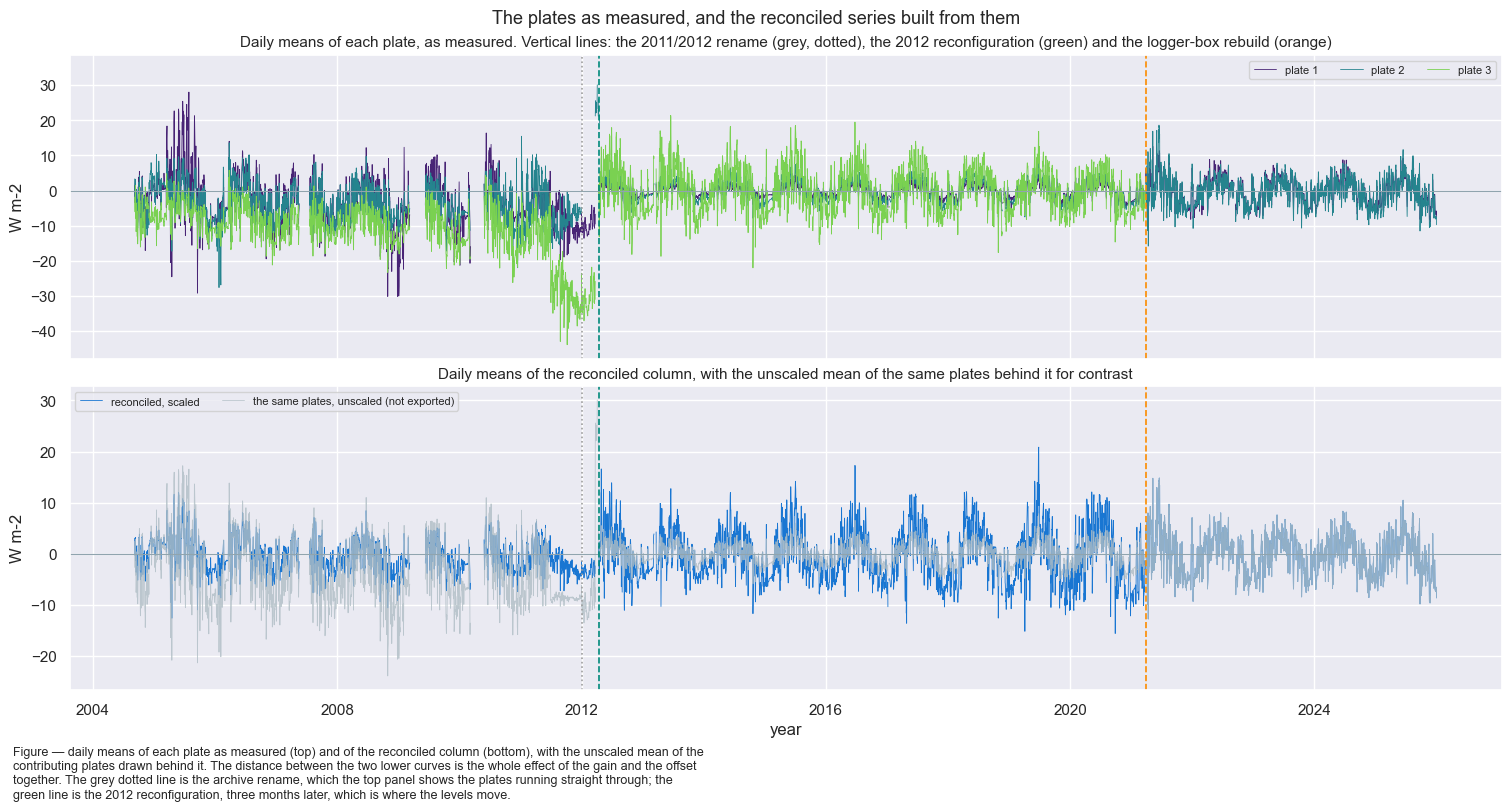

In [36]:
fig, axs = plt.subplots(nrows=2, figsize=(15, 8.0), dpi=100, layout='constrained', sharex=True)
fig.suptitle('The plates as measured, and the reconciled series built from them', fontsize=13)

_colors = plt.cm.viridis(np.linspace(0.1, 0.8, len(PLATES)))
for _c, p in zip(_colors, PLATES):
    _d = g[field(p)].resample('1D').mean()
    axs[0].plot(_d.index, _d.values, lw=0.6, color=_c, label=f'plate {p}')
axs[0].axhline(0, color='#90A4AE', lw=0.8)
axs[0].axvline(NAME_CHANGE_AT, color='#9E9E9E', ls=':', lw=1.2)
axs[0].axvline(SETUP2_START, color='#00897B', ls='--', lw=1.2)
axs[0].axvline(REBUILD_START, color='#FB8C00', ls='--', lw=1.2)
axs[0].set_ylabel('W m-2')
axs[0].set_title('Daily means of each plate, as measured. Vertical lines: the 2011/2012 rename '
                 '(grey, dotted), the 2012 reconfiguration (green) and the logger-box rebuild '
                 '(orange)', fontsize=11)
axs[0].legend(fontsize=8, ncol=3)

_dh = g[OVERALL].resample('1D').mean()
axs[1].plot(_dh.index, _dh.values, lw=0.6, color='#1976D2', label='reconciled, scaled')
_dm = pd.DataFrame({p: g[field(p)] for p in CONTRIB}).mean(axis=1).resample('1D').mean()
axs[1].plot(_dm.index, _dm.values, lw=0.6, color='#B0BEC5', alpha=.8,
            label='the same plates, unscaled (not exported)')
axs[1].axhline(0, color='#90A4AE', lw=0.8)
axs[1].axvline(NAME_CHANGE_AT, color='#9E9E9E', ls=':', lw=1.2)
axs[1].axvline(SETUP2_START, color='#00897B', ls='--', lw=1.2)
axs[1].axvline(REBUILD_START, color='#FB8C00', ls='--', lw=1.2)
axs[1].set_xlabel('year')
axs[1].set_ylabel('W m-2')
axs[1].set_title('Daily means of the reconciled column, with the unscaled mean of the same plates '
                 'behind it for contrast', fontsize=11)
axs[1].legend(fontsize=8, ncol=2)
figcap(fig, 'daily means of each plate as measured (top) and of the reconciled column (bottom), '
            'with the unscaled mean of the contributing plates drawn behind it. The distance '
            'between the two lower curves is the whole effect of the gain and the offset '
            'together. The grey '
            'dotted line is the archive rename, which the top panel shows the plates running '
            'straight through; the green line is the 2012 reconfiguration, three months later, '
            'which is where the levels move.')

### Does the reconciled column still step?

The reconciled column exists so that an analysis can cross the two setup boundaries. Whether it
succeeds is a question with an answer, and this is where the answer is measured rather than assumed
from the fact that a correction was applied.

The statistic is a season-matched level, for the reason `season_level` exists: three years either
side of a boundary need not cover the same months, and a plain mean would then compare a stretch
weighted towards summer with one weighted towards winter. Each calendar month is averaged on its own
and the twelve are weighted equally.

A number on its own would not say whether a step is large, so the same statistic is computed at a
set of dates that lie **well inside a single setup**, where nothing changed. That null says how much
this level moves between one three-year stretch and the next for reasons that have nothing to do
with the instrument, and a boundary step is read against it.

This is where the two terms of the correction are judged together, on the column that is actually
exported rather than on the setups they were fitted to. The gain and the offset are each fitted per
plate and per setup against the reference setup; whether a **boundary** disappears from the
**average of two plates** is a different question, and neither fit was told to make it do so.

An earlier version of this notebook applied the gain alone, and this check failed at the 2012
boundary: the reconciled column stepped by more than the same statistic ever produced inside a
settled setup, because a multiplicative gain scales the swings and leaves the zero point where it
is. The additive term exists because of that failure, so this section is where it is shown to have
worked or not worked.

In [37]:
LEVEL_WINDOW_YEARS = 3

def boundary_step(series: pd.Series, when, years: int = LEVEL_WINDOW_YEARS) -> float:
    """The season-matched change in level across `when`, in W m-2.

    Positive means the level after the date is higher. Only the calendar months represented on both
    sides enter, so a boundary that falls in spring does not compare a summer-heavy stretch with a
    winter-heavy one.
    """
    when = pd.Timestamp(when)
    _, before = season_level(series.loc[when - pd.DateOffset(years=years):when])
    _, after = season_level(series.loc[when:when + pd.DateOffset(years=years)])
    common = before.index.intersection(after.index)
    if len(common) < 6:
        return np.nan
    return float((after[common] - before[common]).mean())


BOUNDARIES = [(SETUP2_START, 'the 2012 reconfiguration'),
              (REBUILD_START, 'the 2021 logger-box rebuild')]

# The null: the same statistic at dates that lie well inside one setup, where nothing changed.
_null_dates = []
for _lo, _hi in [(pd.Timestamp(RECORD_START) + pd.DateOffset(years=1),
                  SETUP1_LAST - pd.DateOffset(years=3)),
                 (SETUP2_START + pd.DateOffset(years=1), REBUILD_START - pd.DateOffset(years=3))]:
    _null_dates += list(pd.date_range(_lo, _hi, freq='QS'))
_null = pd.Series({_d: boundary_step(g[OVERALL], _d) for _d in _null_dates}).dropna()
assert len(_null) >= 10, (
    f"only {len(_null)} usable null dates inside a single setup; the boundary steps below would "
    f"have nothing to be judged against.")

_rows = []
for _when, _what in BOUNDARIES:
    _step = boundary_step(g[OVERALL], _when)
    # A rank, for the same reason as in the 25 June 2015 section: a null of this size can say where
    # the observation sits among its members and nothing finer. Rank 1 means the boundary step is
    # larger than every date inside a settled setup, and that is the only clean verdict available.
    _rank_top = 1 + int((_null.abs() > abs(_step)).sum()) if np.isfinite(_step) else np.nan
    _pct = 100.0 * float((_null.abs() <= abs(_step)).mean()) if np.isfinite(_step) else np.nan
    _rows.append({'boundary': _what, 'at': _when, 'step_wm2': round(_step, 3),
                  'null_median_abs': round(float(_null.abs().median()), 3),
                  'null_max_abs': round(float(_null.abs().max()), 3),
                  'rank_from_top': _rank_top, 'n_compared': len(_null) + 1,
                  'exceeds_null_max': bool(abs(_step) > float(_null.abs().max())),
                  'percentile_in_null': round(_pct, 1)})
STEPTAB = pd.DataFrame(_rows).set_index('boundary')
tabcap('the season-matched change in the level of the reconciled column across each setup '
       'boundary, against the same statistic computed at dates well inside a single setup where '
       'nothing changed. The verdict is the rank: a step that outranks every null date is a step '
       'the correction did not remove, and the percentile beside it is that rank written as a '
       'fraction.')
display(STEPTAB)

_step_res = 100.0 / len(_null)
print(f"null: {len(_null)} dates inside a single setup, |step| median "
      f"{float(_null.abs().median()):.2f}, max {float(_null.abs().max()):.2f} W m-2")
print(f"the verdict is a rank among {len(_null) + 1} values, so the finest percentile it can "
      f"resolve is {_step_res:.1f} points;\nthe threshold it uses - outranking every null date - "
      f"is the one threshold a null of any size can\nalways reach.")
print("Two cautions on the null itself. Its dates are quarterly and each window spans three years, "
      "so\nneighbouring dates share most of their records and the number of INDEPENDENT values "
      "behind it is\nseveral times smaller than its count. And its two stretches lie inside the "
      "two mst setups, so it\ndescribes how far this level wanders under those acquisitions "
      "rather than under the modern one.")
for _b, _r in STEPTAB.iterrows():
    if _r['exceeds_null_max']:
        print(f"\n(!) {_b}: the reconciled column steps by {_r['step_wm2']:+.2f} W m-2, larger "
              f"than the largest\n    change the same statistic produces anywhere inside a single "
              f"setup ({_r['null_max_abs']:.2f}). The\n    homogenisation has NOT removed this "
              f"boundary from the column.")
    else:
        print(f"\n{_b}: the reconciled column steps by {_r['step_wm2']:+.2f} W m-2, within what "
              f"the same\n    statistic does inside a single setup (up to {_r['null_max_abs']:.2f})"
              f". Nothing measurable is left at this boundary.")

_left = STEPTAB[STEPTAB['exceeds_null_max']]
if len(_left):
    print(f"\nSo the reconciled column does what it was built to do at "
          f"{len(STEPTAB) - len(_left)} of {len(STEPTAB)} boundaries, and not at the\nother(s): "
          f"{', '.join(_left.index)}. Neither term of the correction reaches whatever is left "
          f"there, and\nsince the offset already puts the season-matched levels of the setups on "
          f"top of each other by\nconstruction, a step that survives it is a statement about the "
          f"PLATES disagreeing rather than\nabout the setups: the two contributing plates enter "
          f"the average over different records either\nside of the boundary.")
    print("This is a limitation of the column, so it is stated in the closing notes rather than "
          "corrected\nhere. An analysis crossing that boundary should expect a level step of this "
          "size and should not\nread a trend across it.")
else:
    print("\nNeither boundary leaves a step the same statistic does not also produce inside a "
          "settled setup.\nThat is the check the additive term was added for: with the gain alone "
          "the 2012 boundary failed\nit, because a multiplicative gain scales the swings and "
          "leaves the zero point where it is.")
    print("Read the size of the null before reading this as 'no step'. The null says how far this "
          "level\nwanders between one three-year stretch and the next for reasons that have "
          "nothing to do with the\ninstrument, and a boundary step smaller than that is not a "
          "measured zero - it is a step this\ntest cannot see.")

# The residual trend the constant offsets cannot remove is a separate matter from a step, and it is
# what a reader crossing the early years is most likely to trip over.
_early = annual_means(g[OVERALL].loc[:SETUP1_LAST])
if len(_early) >= 4:
    _sl = float(np.polyfit(_early.index.to_numpy().astype(float), _early.to_numpy(), 1)[0])
    print(f"\nThe reconciled column's annual means over the original acquisition run "
          f"{float(_early.min()):+.2f} .. {float(_early.max()):+.2f} W m-2\nwith a trend of "
          f"{_sl:+.3f} W m-2 per year. A constant offset removes a level and leaves a slope, so "
          f"this is\nwhat survives at the plates whose zero point walks. It is smaller than the "
          f"walk in the measured\ncolumns and it is not zero.")

Table — the season-matched change in the level of the reconciled column across each setup boundary,
against the same statistic computed at dates well inside a single setup where nothing changed. The
verdict is the rank: a step that outranks every null date is a step the correction did not remove,
and the percentile beside it is that rank written as a fraction.



,at,step_wm2,null_median_abs,null_max_abs,rank_from_top,n_compared,exceeds_null_max,percentile_in_null
boundary,,,,,,,,
the 2012 reconfiguration,2012-04-12 13:45:00,0.613,0.456,1.891,11,34,False,69.7
the 2021 logger-box rebuild,2021-03-26 15:15:00,-0.032,0.456,1.891,32,34,False,6.1


null: 33 dates inside a single setup, |step| median 0.46, max 1.89 W m-2
the verdict is a rank among 34 values, so the finest percentile it can resolve is 3.0 points;
the threshold it uses - outranking every null date - is the one threshold a null of any size can
always reach.
Two cautions on the null itself. Its dates are quarterly and each window spans three years, so
neighbouring dates share most of their records and the number of INDEPENDENT values behind it is
several times smaller than its count. And its two stretches lie inside the two mst setups, so it
describes how far this level wanders under those acquisitions rather than under the modern one.

the 2012 reconfiguration: the reconciled column steps by +0.61 W m-2, within what the same
    statistic does inside a single setup (up to 1.89). Nothing measurable is left at this boundary.

the 2021 logger-box rebuild: the reconciled column steps by -0.03 W m-2, within what the same
    statistic does inside a single setup (up to 1.

***

## 🌡️ The storage term above the plates

A plate at 0.05 m measures the heat that crosses that depth. The soil above the plate also stores
heat and releases it again, and the plate cannot see any of that. So an energy balance written with
the plate flux alone gets the ground heat flux at the surface wrong. What it is missing is the
storage term

$$ S = C \cdot \Delta z \cdot \frac{\partial T}{\partial t} $$

where $C$ is the volumetric heat capacity of the layer and $\Delta z$ is the depth of the plate.

This product exports the plate flux, not the surface flux. The section exists so that the size of
the missing term is known rather than assumed. It estimates the term and reports it, and it exports
nothing.

Two of the three ingredients are measured at this station: soil temperature comes from `10` and soil
water content from `09`, both at 0.05 m. The third is not measured at all.

::: {.callout-warning title="Bulk density is not measured at this site"}
The dry volumetric heat capacity used below is a literature value for a mineral forest soil. Because
of that, the estimate is reported at that value and also at 30 % above and below it, so a reader
sees the range rather than one number that looks more precise than it is.

There is a second approximation underneath. The temperature at the plate's own depth is used as the
average temperature of the whole layer above it, which overstates the layer's thermal inertia in the
morning and understates it in the evening. Between them, these two approximations make this an
order-of-magnitude statement, and it is used as one.
:::

::: {.callout-warning title="The temperature reference is not one instrument, so the estimate is reported per setup"}
The whole term is proportional to `dT/dt` of `10`'s soil temperature at 0.05 m, and the section
*How closely does each plate follow the soil around it?* measures how that series' own composite day
changes between the setups. Whichever era has the larger diurnal signal will produce a larger
storage term, whatever the soil did.

So a single number computed over the whole record would mix eras of the reference with eras of the
plates, and would describe neither. The table below is per setup for that reason, and the figure
that follows is drawn inside the reference setup only. The proportion the term bears to the measured
flux is a statement about one setup at a time.
:::

In [38]:
swc = dv.load_parquet(filepath=PATH_SWC)
assert COL_SWC_005 in swc.columns, (
    f"{COL_SWC_005} is not in {Path(PATH_SWC).name}. Notebook 09's export schema has changed - fix "
    f"COL_SWC_005 rather than dropping the storage estimate.")
THETA = (swc[COL_SWC_005].reindex(full_index) / 100.0)   # % VWC -> m3 m-3
print(f"soil water content at 0.05 m: {int(THETA.notna().sum()):,} records, "
      f"median {float(THETA.median()):.3f} m3 m-3")

# The homogenised column is a measured value plus a fitted monthly offset, so `09` does not bound
# it the way it bounds its measured columns: a dry month shifted down can land below zero. Records
# outside the physical range are dropped from this estimate with a printed count, rather than
# stopping the notebook over a diagnostic that exports nothing. The assertion is on the BULK of the
# distribution, which is what would move if the column or its unit were wrong.
_theta_bad = THETA.notna() & ~THETA.between(0.0, 0.8)
if int(_theta_bad.sum()):
    print(f"  {int(_theta_bad.sum()):,} records outside 0..0.8 m3 m-3 "
          f"({100 * float(_theta_bad.sum()) / int(THETA.notna().sum()):.3f} % of measured, range "
          f"{float(THETA[_theta_bad].min()):.3f}..{float(THETA[_theta_bad].max()):.3f}) - dropped "
          f"from the storage estimate")
    THETA = THETA.where(~_theta_bad)
assert 0.0 <= float(THETA.quantile(0.01)) and float(THETA.quantile(0.99)) <= 0.8, (
    "the central 98 % of the soil water content lies outside 0..0.8 m3 m-3. That is a unit or "
    "column error rather than dry soil - check COL_SWC_005.")

# The layer thickness is one number, 0.05 m, because the depth test found no support for the 0.025
# label - see LAYER_DEPTH_M in the settings and the assertion that ties it to the verdict. What
# taking the label at face value would do is reported below as a sensitivity rather than applied.
_leader = max(CONTRIB, key=lambda p: int(g[field(p)].notna().sum()))
DZ = LAYER_DEPTH_M
print(f"layer thickness: {DZ} m for every setup ({DEPTH_VERDICT})")


def storage_term(c_dry: float) -> pd.Series:
    """S = C * dz * dT/dt, in W m-2, on the 30MIN grid. Positive means the layer is gaining heat."""
    C = c_dry + RHO_W_C_W * THETA
    return C * DZ * (DTS_DT / (30 * 60))     # K per 30 min -> K per s


S_MID = storage_term(C_DRY_J_M3_K)
S_LO = storage_term(C_DRY_J_M3_K * (1 - C_DRY_SENSITIVITY))
S_HI = storage_term(C_DRY_J_M3_K * (1 + C_DRY_SENSITIVITY))

_common = g[OVERALL].notna() & S_MID.notna()
print(f"\nrecords where both the reconciled flux and the storage estimate exist: "
      f"{int(_common.sum()):,}")

# Per setup, because both sides of the ratio change between them: the plate flux carries whatever
# its own setup did, and the storage term carries the diurnal amplitude of the temperature
# reference in that era. A ratio over the whole record is a ratio between two mixtures.
_rows = []
for _code, _name in SETUP_NAMES.items():
    _m = _common & (g[flagcol(_leader)] == _code)
    if int(_m.sum()) < 5000:
        continue
    for _lbl, _s in [('C_dry -30 %', S_LO), ('C_dry as set', S_MID), ('C_dry +30 %', S_HI)]:
        _sc, _gc = _s[_m], g[OVERALL][_m]
        _rows.append({'setup': _name, 'flag': _code, 'assumption': _lbl, 'n': int(_m.sum()),
                      'mean_|S|': round(float(_sc.abs().mean()), 2),
                      'sd_S': round(float(_sc.std()), 2),
                      'sd_G': round(float(_gc.std()), 2),
                      'sd_S / sd_G': round(float(_sc.std() / _gc.std()), 3),
                      'mean_S': round(float(_sc.mean()), 3),
                      'p95_|S|': round(float(_sc.abs().quantile(0.95)), 2)})
STORAGE = pd.DataFrame(_rows).set_index(['flag', 'assumption'])
tabcap('the estimated storage term of the soil layer above the plates, per setup, at the assumed '
       'dry heat capacity and at plus and minus 30 % of it, against the reconciled plate flux over '
       'the same records. `sd_S / sd_G` is how much of the plate signal the missing layer would '
       'add, in that setup.')
display(STORAGE)

_ref_row = STORAGE.loc[(REFERENCE_FLAG, 'C_dry as set')]
_ratio = float(_ref_row['sd_S / sd_G'])
_all_ratios = STORAGE.xs('C_dry as set', level='assumption')['sd_S / sd_G']
print(f"\nIn the reference setup - the modern one, and the one the figure below is drawn in - the "
      f"layer\nabove the plates carries a term about {100 * _ratio:.0f} % the size of the measured "
      f"flux, in spread\n({_ref_row['sd_S']:.2f} against {_ref_row['sd_G']:.2f} W m-2).")
print(f"\nAcross the three setups the same ratio runs "
      f"{float(_all_ratios.min()):.2f} .. {float(_all_ratios.max()):.2f}, a factor of "
      f"{float(_all_ratios.max() / _all_ratios.min()):.1f}. That spread is\nnot the soil changing. "
      f"Both sides of the ratio move: the plates' own spread changes at each\nsetup boundary, and "
      f"the temperature reference's diurnal amplitude changes with it, so the\nnumerator and the "
      f"denominator belong to different instruments in each row. Quote the row of the\nsetup you "
      f"are working in, never the average of the three.")
print(f"\nThe mean of the term is near zero in every setup, as it must be over a long record, so "
      f"it is a\nDIURNAL and SEASONAL correction rather than a level one.")

# What the archive's 0.025 label would do, reported rather than applied. The depth test found no
# support for it, and the term is linear in the layer thickness, so the sensitivity is exact.
print(f"\nIf the 0.025 m label the archive carries between 2012 and 2021 were taken at face value, "
      f"the term in\nthat setup would be exactly halved, because it is linear in the layer "
      f"thickness: its ratio to the\nmeasured flux would fall from "
      f"{float(_all_ratios.loc[FLAG_MST_RECONFIGURED]):.2f} to "
      f"{float(_all_ratios.loc[FLAG_MST_RECONFIGURED]) / 2:.2f}. The depth test found no support "
      f"for the label, so the\nestimate above uses {LAYER_DEPTH_M} m throughout.")

print("\nWhat this settles: an energy-balance closure computed from the exported column is a "
      "closure\nat 0.05 m, not at the surface, and it will be short by roughly this much at the "
      "times of day\nwhen the soil is warming or cooling fastest. Adding the term to the product "
      "would require a\nmeasured bulk density and a temperature above the plate; neither exists "
      "here, and a storage\nterm resting on two assumptions is not something to fold silently "
      "into a measured column.")

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\09_METEO_SWC_FF1_2004-2025.parquet (0.177 seconds).

soil water content at 0.05 m: 302,058 records, median 0.303 m3 m-3
layer thickness: 0.05 m for every setup (NEITHER hypothesis)

records where both the reconciled flux and the storage estimate exist: 295,018
Table — the estimated storage term of the soil layer above the plates, per setup, at the assumed dry
heat capacity and at plus and minus 30 % of it, against the reconciled plate flux over the same
records. `sd_S / sd_G` is how much of the plate signal the missing layer would add, in that setup.



setup       n  mean_|S|   sd_S  sd_G  sd_S / sd_G  mean_S  p95_|S|
flag assumption                                                                                         
1    C_dry -30 %              mst, original  113406      6.46  12.50  4.25        2.941  -0.030    21.54
     C_dry as set             mst, original  113406      7.57  14.60  4.25        3.435  -0.036    25.33
     C_dry +30 %              mst, original  113406      8.69  16.70  4.25        3.929  -0.042    29.06
2    C_dry -30 %          mst, reconfigured   99839      5.25   9.96  5.67        1.756   0.004    16.90
     C_dry as set         mst, reconfigured   99839      6.16  11.67  5.67        2.059   0.003    19.83
     C_dry +30 %          mst, reconfigured   99839      7.07  13.39  5.67        2.362   0.002    22.78
3    C_dry -30 %   diive, after the rebuild   81769      1.30   2.01  5.09        0.395  -0.001     3.74
     C_dry as set  diive, after the rebuild   81769      1.52   2.36  5.09        0.464  -0.001     4.41
     C_dry +30 %   diive, after the rebuild   81769      1.75   2.71  5.09        0.532  -0.001     5.09


In the reference setup - the modern one, and the one the figure below is drawn in - the layer
above the plates carries a term about 46 % the size of the measured flux, in spread
(2.36 against 5.09 W m-2).

Across the three setups the same ratio runs 0.46 .. 3.44, a factor of 7.4. That spread is
not the soil changing. Both sides of the ratio move: the plates' own spread changes at each
setup boundary, and the temperature reference's diurnal amplitude changes with it, so the
numerator and the denominator belong to different instruments in each row. Quote the row of the
setup you are working in, never the average of the three.

The mean of the term is near zero in every setup, as it must be over a long record, so it is a
DIURNAL and SEASONAL correction rather than a level one.

If the 0.025 m label the archive carries between 2012 and 2021 were taken at face value, the term in
that setup would be exactly halved, because it is linear in the layer thickness: its ratio to the
measured flux 

### 📊 Plot: plate flux against storage term

  reconciled plate flux (reference setup)      composite over   891 days, amplitude   8.62 W m-2
  storage term above the plates                composite over   891 days, amplitude   4.88 W m-2
  their sum, the surface flux                  composite over   891 days, amplitude  13.42 W m-2
  composite amplitudes: storage / plate flux = 0.57 in the reference setup


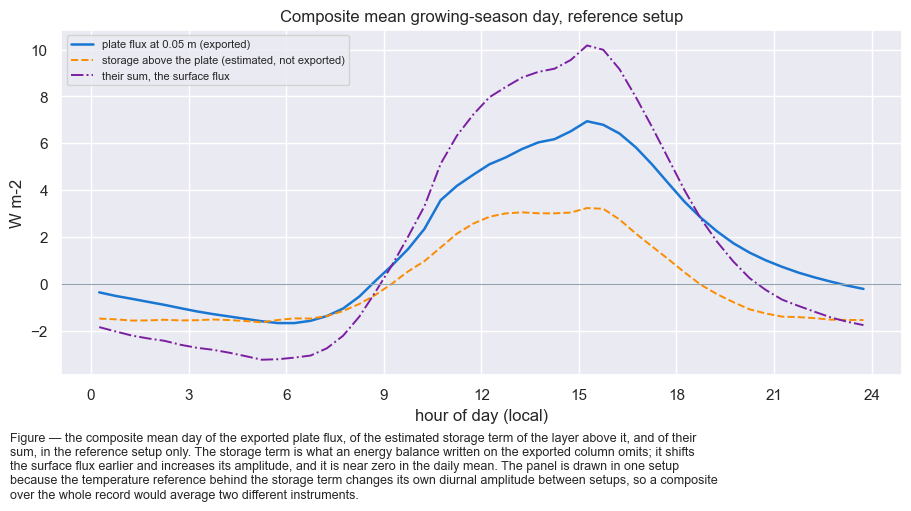

In [39]:
_mask_ref = _common & (g[flagcol(_leader)] == REFERENCE_FLAG)
_cg = diurnal_composite(g[OVERALL][_mask_ref], 'reconciled plate flux (reference setup)')
_cs = diurnal_composite(S_MID[_mask_ref], 'storage term above the plates')
_ct = diurnal_composite((g[OVERALL] + S_MID)[_mask_ref], 'their sum, the surface flux')
print(f"  composite amplitudes: storage / plate flux = "
      f"{float((_cs.max() - _cs.min()) / (_cg.max() - _cg.min())):.2f} in the reference setup")

fig, ax = plt.subplots(figsize=(9, 5), dpi=100, layout='constrained')
ax.plot(_cg.index, _cg.values, color='#1976D2', lw=1.8, label='plate flux at 0.05 m (exported)')
ax.plot(_cs.index, _cs.values, color='#FB8C00', lw=1.4, ls='--',
        label='storage above the plate (estimated, not exported)')
ax.plot(_ct.index, _ct.values, color='#7B1FA2', lw=1.4, ls='-.',
        label='their sum, the surface flux')
ax.axhline(0, color='#90A4AE', lw=0.8)
ax.set_xlabel('hour of day (local)')
ax.set_ylabel('W m-2')
ax.set_xticks(range(0, 25, 3))
ax.set_title('Composite mean growing-season day, reference setup', fontsize=12)
ax.legend(fontsize=8)
figcap(fig, 'the composite mean day of the exported plate flux, of the estimated storage term of '
            'the layer above it, and of their sum, in the reference setup only. The storage term is '
            'what an energy balance written on the exported column omits; it shifts the surface '
            'flux earlier and increases its amplitude, and it is near zero in the daily mean. The '
            'panel is drawn in one setup because the temperature reference behind the storage term '
            'changes its own diurnal amplitude between setups, so a composite over the whole '
            'record would average two different instruments.')

***

## 🚫 What is not filled, and why

Nothing in this product is gap-filled, and there are two separate reasons for that.

The first is that there is nothing to fill from. No weather service measures soil heat flux, and the
nearest plates of the same make sit at other sites in other soils. `01` to `03` can be filled
because an independent instrument measured the same sky. This variable has no equivalent witness
anywhere.

The second is that the gaps are instrumental rather than meteorological. The forest-floor logger of
the pre-2020 era ran on a battery, so a power failure takes every plate out at once and leaves a
block of days or months. Interpolating a daily cycle across a block like that would produce a
record that is smooth, plausible and entirely invented, and an energy-balance closure would accept
it without complaint.

The table below shows where the record is thin, per plate and per year, so that anyone using the
product sees it before an analysis does.

In [40]:
_gaps = []
for p in PLATES:
    _s = g[field(p)].dropna()
    if _s.empty:
        continue
    _d = _s.index.to_series().diff()
    _big = _d[_d > pd.Timedelta(days=5)]
    for _end, _len in _big.items():
        _start = _end - _len
        _gaps.append({'plate': p, 'from': _start, 'to': _end, 'days': int(_len.days),
                      'setup_before': int(g.loc[_start, flagcol(p)]),
                      'setup_after': int(g.loc[_end, flagcol(p)])})
GAPS = pd.DataFrame(_gaps).sort_values('days', ascending=False)
tabcap('every gap longer than five days in a plate column, with the setup on either side of it. A '
       'gap whose two setups differ is a boundary rather than an outage.')
display(GAPS.set_index(['plate', 'from']).head(30))
print(f"\ngaps longer than five days: {len(GAPS)}   "
      f"longest: {int(GAPS['days'].max()) if len(GAPS) else 0} days")

# The gaps that hit every plate at once are the station's, not a plate's. They are the ones the
# fieldbook can be asked about.
_all_missing = pd.concat([g[field(p)].isna() for p in PLATES], axis=1).all(axis=1)
_blocks = (_all_missing != _all_missing.shift()).cumsum()[_all_missing]
_station = (pd.DataFrame({'n': _blocks.groupby(_blocks).size()})
            .assign(days=lambda d: (d['n'] / 48).round(1)))
_station = _station[_station['days'] >= 5]
if len(_station):
    _rows = []
    for _b in _station.index:
        _ix = _blocks.index[_blocks == _b]
        _rows.append({'from': _ix[0], 'to': _ix[-1], 'days': round(len(_ix) / 48, 1)})
    STATION_GAPS = pd.DataFrame(_rows).sort_values('days', ascending=False)
    tabcap('the periods in which no plate measured at all. These are the station\'s gaps - a dead '
           'logger or a dead battery - and are the ones the fieldbook can explain.')
    display(STATION_GAPS.set_index('from').head(15))
    print("\nThe fieldbook around the three longest:")
    for _, r in STATION_GAPS.head(3).iterrows():
        print(f"\n--- {r['from']:%Y-%m-%d} -> {r['to']:%Y-%m-%d} ({r['days']} days)")
        fieldbook_near(r['from'], r['to'], days=5)
        if pd.Timestamp(r['from']).year <= 2011:
            print("   (setup 1: the dated record for these years is inside the legacy row)")
            _ = legacy_search(pd.Timestamp(r['from']).strftime(r'%d\.%m\.%Y|%m\.%Y'), limit=4)
else:
    print("\nNo period of five days or more in which every plate was silent.")

Table — every gap longer than five days in a plate column, with the setup on either side of it. A
gap whose two setups differ is a boundary rather than an outage.



to  days  setup_before  setup_after
plate from                                                                    
1     2009-03-10 15:45:00 2009-06-11 12:45:00    92             1            1
2     2009-03-10 15:45:00 2009-06-11 13:15:00    92             1            1
3     2009-03-10 15:45:00 2009-06-11 12:45:00    92             1            1
2     2010-03-06 12:45:00 2010-05-28 10:45:00    82             1            1
      2011-12-31 23:15:00 2012-03-23 14:15:00    82             5            4
3     2010-03-06 12:45:00 2010-05-28 10:45:00    82             1            1
1     2010-03-06 12:45:00 2010-05-28 10:45:00    82             1            1
2     2007-05-18 11:15:00 2007-07-20 10:15:00    62             1            1
3     2007-05-18 11:15:00 2007-07-20 10:15:00    62             1            1
1     2007-05-18 11:15:00 2007-07-20 10:15:00    62             1            1
      2012-03-22 08:45:00 2012-04-12 13:45:00    21             1            2
3     2012-03-22 08:45:00 2012-04-12 13:45:00    21             1            2
2     2012-04-21 10:45:00 2012-05-05 04:15:00    13             4            2
      2012-07-29 22:45:00 2012-08-11 13:15:00    12             2            2
1     2013-03-09 23:15:00 2013-03-22 15:15:00    12             2            2
2     2013-03-09 23:15:00 2013-03-22 15:15:00    12             2            2
3     2013-03-09 23:15:00 2013-03-22 15:15:00    12             2            2
2     2022-09-06 08:45:00 2022-09-16 14:45:00    10             3            3
1     2022-09-06 08:45:00 2022-09-16 14:45:00    10             3            3
      2018-11-20 16:15:00 2018-11-29 12:45:00     8             2            2
3     2018-11-20 16:15:00 2018-11-29 12:45:00     8             2            2
2     2018-11-20 16:15:00 2018-11-29 12:45:00     8             2            2
      2006-09-16 08:45:00 2006-09-22 09:45:00     6             1            1
3     2006-09-16 07:45:00 2006-09-22 09:45:00     6             1            1
1     2021-03-27 12:45:00 2021-04-02 14:15:00     6             3            3
      2006-09-16 08:45:00 2006-09-22 09:45:00     6             1            1
2     2021-03-27 12:45:00 2021-04-02 14:15:00     6             3            3
1     2017-01-06 16:45:00 2017-01-12 14:15:00     5             2            2
2     2012-04-04 02:15:00 2012-04-09 19:45:00     5             4            4
      2017-01-06 16:45:00 2017-01-12 14:15:00     5             2            2


gaps longer than five days: 31   longest: 92 days
Table — the periods in which no plate measured at all. These are the station's gaps - a dead logger
or a dead battery - and are the ones the fieldbook can explain.



,to,days
from,,
2009-03-10 16:15:00,2009-06-11 12:15:00,92.9
2010-03-06 13:15:00,2010-05-28 10:15:00,82.9
2007-05-18 11:45:00,2007-07-20 09:45:00,62.9
2013-03-09 23:45:00,2013-03-22 14:45:00,12.6
2022-09-06 09:15:00,2022-09-16 14:15:00,10.2
2018-11-20 16:45:00,2018-11-29 12:15:00,8.8
2006-09-16 09:15:00,2006-09-22 09:15:00,6.0
2021-03-27 13:15:00,2021-04-02 13:45:00,6.0
2017-01-06 17:15:00,2017-01-12 13:45:00,5.9



The fieldbook around the three longest:

--- 2009-03-10 -> 2009-06-11 (92.9 days)
   (no fieldbook entry within +/-5 days)
   (setup 1: the dated record for these years is inside the legacy row)
legacy sub-entries matching /10\.03\.2009|03\.2009/: 1
   2009-03-16  16.03.2009 (person 07) EC-Computer (ACER) broken down, restart

--- 2010-03-06 -> 2010-05-28 (82.9 days)
   (no fieldbook entry within +/-5 days)
   (setup 1: the dated record for these years is inside the legacy row)
legacy sub-entries matching /06\.03\.2010|03\.2010/: 1
   2010-03-04  04.03.2010 (person 07 & person 11) Zweifel-Dendrometer an der Esche wieder montiert. Dabei festgestellt, dass das Kabel ca. 2m neben dem Baum durchgebissen war repariert. Die 3 Zweifel Dendrometer auf eine Grundspannung von 200 bis 300mV justiert. Messdaten Waldbodenstation geholt.

--- 2007-05-18 -> 2007-07-20 (62.9 days)
   (no fieldbook entry within +/-5 days)
   (setup 1: the dated record for these years is inside the legacy row)
legacy s

***

## ➡️ Prepare dataframe for export

The columns are grouped by plate, value first and flag second, so the provenance of a number is never
more than one column away from it. The reconciled column and its composition flag come last. This is
the same layout as `09` and `10` use, with the plate taking the place of the depth.

In [41]:
EXPORT_COLS = []
for p in PLATES:
    EXPORT_COLS += [field(p), flagcol(p)]
EXPORT_COLS += [OVERALL, OVERALL_NPLATES]

export_df = g[EXPORT_COLS].copy()
for p in PLATES:
    export_df[flagcol(p)] = export_df[flagcol(p)].astype(int)
export_df[OVERALL_NPLATES] = export_df[OVERALL_NPLATES].astype(int)

print(f"{len(EXPORT_COLS)} columns: {len(PLATES)} measured plates, {len(PLATES)} source flags, "
      f"1 reconciled column, 1 composition flag")
tabcap('the exported frame: value and source flag for each plate, grouped so the two stay '
       'adjacent, then the reconciled column and the number of plates behind it.')
export_df

8 columns: 3 measured plates, 3 source flags, 1 reconciled column, 1 composition flag
Table — the exported frame: value and source flag for each plate, grouped so the two stay adjacent,
then the reconciled column and the number of plates behind it.



,G_FF1_0.05_1,FLAG_G_FF1_0.05_1_SOURCE,G_FF1_0.05_2,FLAG_G_FF1_0.05_2_SOURCE,G_FF1_0.05_3,FLAG_G_FF1_0.05_3_SOURCE,G_FF1_0.05_HOMOGENIZED,FLAG_G_FF1_0.05_HOMOGENIZED_NPLATES
TIMESTAMP_MIDDLE,,,,,,,,
2004-09-07 00:15:00,NaN,0,NaN,0,NaN,0,NaN,0
2004-09-07 00:45:00,NaN,0,NaN,0,NaN,0,NaN,0
2004-09-07 01:15:00,NaN,0,NaN,0,NaN,0,NaN,0
2004-09-07 01:45:00,NaN,0,NaN,0,NaN,0,NaN,0
2004-09-07 02:15:00,NaN,0,NaN,0,NaN,0,NaN,0
...,...,...,...,...,...,...,...,...
2025-12-31 21:45:00,-7.623570,3,-10.083217,3,NaN,0,-8.853394,2
2025-12-31 22:15:00,-7.657959,3,-10.118965,3,NaN,0,-8.888462,2
2025-12-31 22:45:00,-7.659050,3,-10.165545,3,NaN,0,-8.912298,2


Now the sanity checks. This product is not expected to be complete, so what gets checked is that the
index is sound, that at each plate the flag and the value tell the same story, and that the frame
about to be written still holds what the notebook computed.

Two of these are worth distinguishing from each other. Re-testing the physical band on the plate
columns cannot fail, because the corrections cell removed everything outside it, so that check is
printed as a restatement rather than asserted. What **can** fail is the reconciled column against
the same band, since it holds scaled values that nothing has forced into it, and whether the frame
about to be written is still identical to `g`: a column reordered or an index re-derived between the
two would pass every other check here.

The reconciled column has its own invariants. It must hold a value in exactly those records where
its composition flag is not zero, it must never claim more contributing plates than exist, and it
must be empty wherever every contributing plate is unmeasured or belongs to no setup.

In [42]:
_lo, _hi = G_PLAUSIBLE_WM2

print(f"Records:          {len(export_df):,}")
print(f"Index:            {export_df.index[0]} -> {export_df.index[-1]}")
print(f"Duplicate index:  {int(export_df.index.duplicated().sum())}")
print(f"Index gaps:       "
      f"{int((export_df.index.to_series().diff().dropna() != pd.Timedelta('30min')).sum())}\n")

assert export_df.index.duplicated().sum() == 0, "duplicate timestamps"
assert (export_df.index.to_series().diff().dropna() == pd.Timedelta('30min')).all(), \
    "index not continuous 30MIN"
assert export_df.index.name == 'TIMESTAMP_MIDDLE', "the index is not named TIMESTAMP_MIDDLE"

# The frame about to be written must still be the frame the notebook computed. Everything else in
# this cell describes export_df; this is the only check that ties it back to g, and it is the one a
# reordered column or a re-derived index would break.
for _c in EXPORT_COLS:
    assert export_df[_c].equals(g[_c].astype(export_df[_c].dtype)), \
        f"{_c}: the exported frame no longer matches the frame it was taken from"
assert export_df.index.equals(g.index), "the exported index is not the index of the merged frame"
print("The exported frame is identical to the merged frame, column by column.\n")

_rows = []
for p in PLATES:
    v, fl = export_df[field(p)], export_df[flagcol(p)]
    assert (v.notna() == fl.isin(MEASURED_FLAGS)).all(), \
        f"plate {p}: a value without a flag, or a flag without a value"
    assert fl.isin(FLAG_SOURCE_LEGEND).all(), f"{flagcol(p)}: unknown flag code"
    assert fl.notna().all(), f"{flagcol(p)}: a record carries no flag"
    _vals = v.dropna()
    _rows.append({'plate': p, 'measured': int(v.notna().sum()),
                  'coverage_%': round(100 * float(v.notna().mean()), 2),
                  'min': round(float(_vals.min()), 2), 'max': round(float(_vals.max()), 2),
                  'mean': round(float(_vals.mean()), 3), 'sd': round(float(_vals.std()), 2),
                  'in_reconciled': p in CONTRIB})
PLATESUM = pd.DataFrame(_rows).set_index('plate')
tabcap('range and coverage of every exported plate column. Coverage is against the full 2004-2025 '
       'index, which is why the discarded plate reads low: it has no instrument after the rebuild.')
display(PLATESUM)

# The measured columns against the physical band. This CANNOT fail - the corrections cell removed
# everything outside it - so it is printed as a restatement of what that cell did, not asserted.
print(f"measured columns run {float(PLATESUM['min'].min()):.1f} .. "
      f"{float(PLATESUM['max'].max()):.1f} W m-2 inside the band {_lo:.0f} .. {_hi:.0f}, which the "
      f"corrections\ncell enforced; re-asserting it here would test nothing.")

# The reconciled column's own invariants. The band check on THIS column can fail: it holds scaled
# values, and no cell has forced them into the band.
assert (export_df[OVERALL].notna() == (export_df[OVERALL_NPLATES] > 0)).all(), \
    f"{OVERALL}: a value with no contributing plate, or a contributing plate with no value"
assert export_df[OVERALL_NPLATES].between(0, len(CONTRIB)).all(), \
    f"{OVERALL_NPLATES}: claims more plates than can contribute"
_ov = export_df[OVERALL].dropna()
assert _ov.between(_lo, _hi).all(), (
    f"{OVERALL}: values outside the physical band after scaling. The gains multiply, so a scaled "
    f"record can leave a band that every measured record sat inside.")
print(f"the reconciled column runs {float(_ov.min()):.1f} .. {float(_ov.max()):.1f} W m-2, inside "
      f"the same band after scaling")

# It must also be empty wherever no contributing plate has a value that belongs to a setup - the
# 2012 reconfiguration records are measured but belong to none, and must not reach this column.
_usable = pd.concat([export_df[field(p)].notna() & export_df[flagcol(p)].isin(SETUP_FLAGS)
                     for p in CONTRIB], axis=1).any(axis=1)
assert export_df[OVERALL].notna().equals(_usable), (
    f"{OVERALL} holds a value where no contributing plate has one that belongs to a setup, or the "
    f"reverse. The 2012 reconfiguration records and the reversed stretches must not reach this "
    f"column.")
print("All checks passed.\n")

_fc = pd.DataFrame({f'plate {p}': export_df[flagcol(p)].value_counts() for p in PLATES})
_fc = _fc.fillna(0).astype(int).sort_index()
_fc['meaning'] = [FLAG_SOURCE_LEGEND[i] for i in _fc.index]
tabcap('how many records each source flag holds at each plate.')
display(_fc)

Records:          373,728
Index:            2004-09-07 00:15:00 -> 2025-12-31 23:45:00
Duplicate index:  0
Index gaps:       0

The exported frame is identical to the merged frame, column by column.

Table — range and coverage of every exported plate column. Coverage is against the full 2004-2025
index, which is why the discarded plate reads low: it has no instrument after the rebuild.



,measured,coverage_%,min,max,mean,sd,in_reconciled
plate,,,,,,,
1,357310,95.61,-90.7,84.1,-1.334,5.99,True
2,352157,94.23,-84.5,129.3,-1.259,5.78,True
3,274659,73.49,-65.9,100.6,-5.034,9.93,False


measured columns run -90.7 .. 129.3 W m-2 inside the band -200 .. 250, which the corrections
cell enforced; re-asserting it here would test nothing.
the reconciled column runs -80.6 .. 45.6 W m-2, inside the same band after scaling
All checks passed.

Table — how many records each source flag holds at each plate.



,plate 1,plate 2,plate 3,meaning
0,16418,21571,99069,"0 = no measurement (gap, or outside this plate..."
1,120058,105878,112809,"1 = original forest-floor acquisition, mst scr..."
2,154604,152837,154604,"2 = reconfigured forest-floor acquisition, mst..."
3,82648,82652,0,"3 = diive screening, after the logger-box rebu..."
4,0,519,0,"4 = the 2012 reconfiguration itself: measured,..."
5,0,10271,7246,5 = the plate read against the other plates: m...


### Per-year coverage, by setup

The columns `n_1`, `n_2` and `n_3` count the records belonging to each setup, and `n_4` those
belonging to the 2012 reconfiguration and therefore to none. If a year has more than one non-zero
count among the first three, the acquisition changed part way through it, and that year's average is
not the average of a single instrument.

In [43]:
_rows = []
for p in PLATES:
    fl = export_df[flagcol(p)]
    _yr = fl.index.year
    _t = pd.DataFrame({f'n_{c}': (fl == c).groupby(_yr).sum() for c in MEASURED_FLAGS})
    _t['possible'] = fl.groupby(_yr).size()
    _t['coverage_%'] = (100 * _t[[f'n_{c}' for c in MEASURED_FLAGS]].sum(axis=1)
                        / _t['possible']).round(1)
    _t['mean_wm2'] = export_df[field(p)].groupby(_yr).mean().round(3)
    _t['plate'] = p
    _rows.append(_t.reset_index(names='year'))
COVER = pd.concat(_rows).set_index(['plate', 'year'])
tabcap('records per year and setup, per plate. A year with two non-zero counts changed acquisition '
       'mid-year, and its mean mixes two setups.')
display(COVER)

_mixed = COVER[(COVER[[f'n_{c}' for c in SETUP_FLAGS]] > 0).sum(axis=1) > 1]
print(f"years mixing two setups (do not read their annual means): "
      f"{sorted(set(_mixed.index.get_level_values('year')))}")
_recon = COVER[COVER[f'n_{FLAG_RECONFIG_2012}'] > 0]
if len(_recon):
    print(f"years holding records of the 2012 reconfiguration, which belong to no setup: "
          f"{sorted(set(_recon.index.get_level_values('year')))}")

Table — records per year and setup, per plate. A year with two non-zero counts changed acquisition
mid-year, and its mean mixes two setups.



n_1   n_2  n_3  n_4  n_5  possible  coverage_%  mean_wm2
plate year                                                            
1     2004   5541     0    0    0    0      5568        99.5    -2.922
      2005  17518     0    0    0    0     17520       100.0     0.420
      2006  17094     0    0    0    0     17520        97.6    -2.658
      2007  14366     0    0    0    0     17520        82.0    -4.587
      2008  17566     0    0    0    0     17568       100.0    -4.391
...           ...   ...  ...  ...  ...       ...         ...       ...
3     2021      0  3956    0    0    0     17520        22.6    -2.680
      2022      0     0    0    0    0     17520         0.0       NaN
      2023      0     0    0    0    0     17520         0.0       NaN
      2024      0     0    0    0    0     17568         0.0       NaN
      2025      0     0    0    0    0     17520         0.0       NaN

[66 rows x 8 columns]

years mixing two setups (do not read their annual means): [2012, 2021]
years holding records of the 2012 reconfiguration, which belong to no setup: [2012]


### 📊 Plot: coverage, setups and annual means

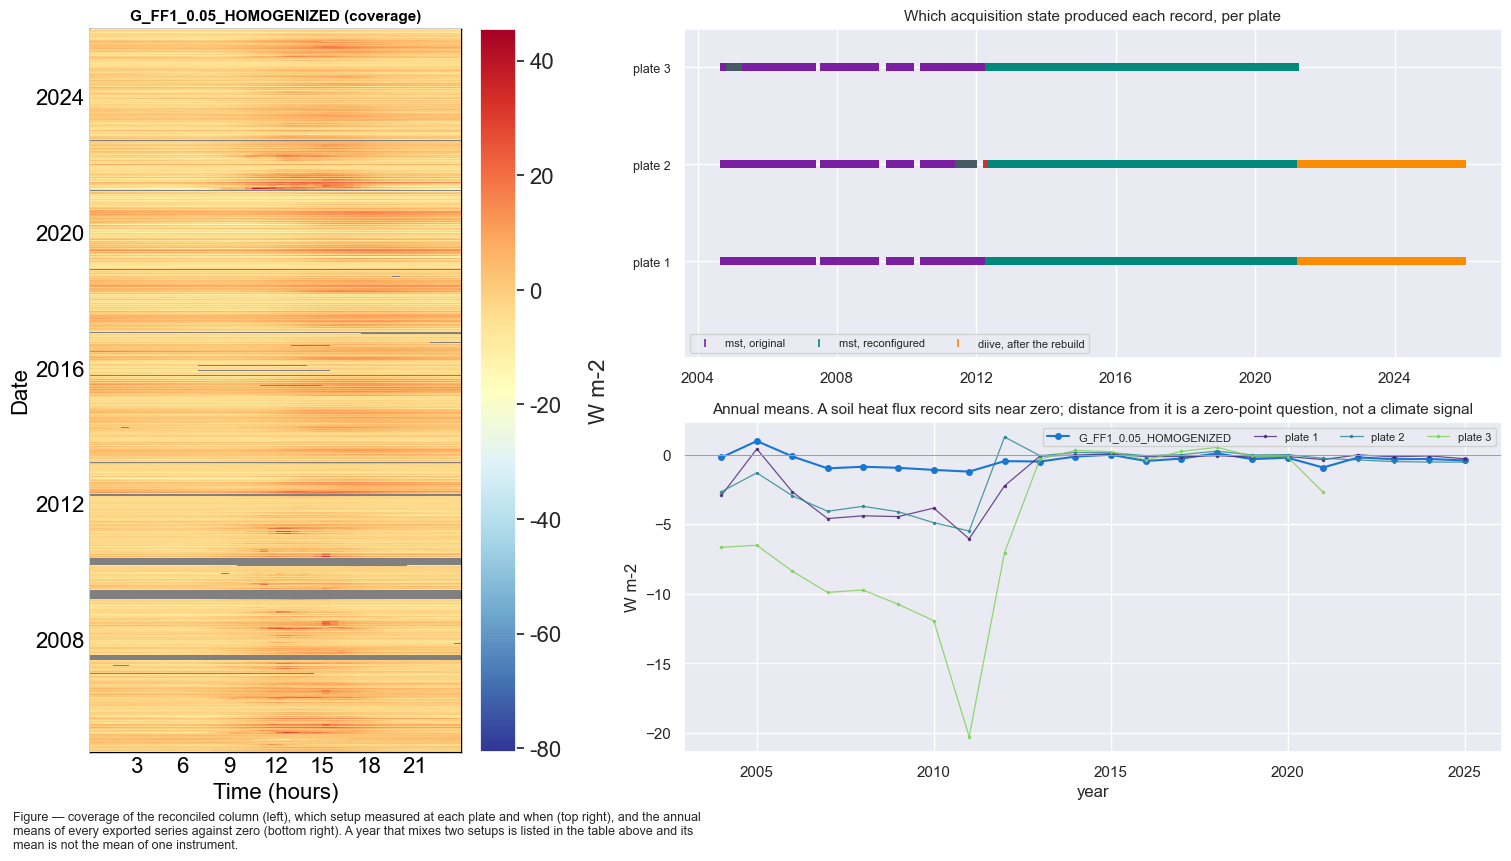

In [44]:
fig = plt.figure(figsize=(15, 8.5), dpi=100, layout='constrained')
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 2.2], figure=fig)
ax_hm = fig.add_subplot(gs[:, 0])
ax_fl = fig.add_subplot(gs[0, 1])
ax_yr = fig.add_subplot(gs[1, 1])

dv.plotting.HeatmapDateTime(series=export_df[OVERALL]).plot(
    ax=ax_hm, cb_digits_after_comma=0, zlabel='W m-2',
    format_style=dv.plotting.FormatStyle(title=f'{OVERALL} (coverage)', title_fontsize=11))

_style = {FLAG_MST_ORIGINAL: '#7B1FA2', FLAG_MST_RECONFIGURED: '#00897B',
          FLAG_DIIVE_005: '#FB8C00', FLAG_RECONFIG_2012: '#D32F2F',
          FLAG_SIGN_REVERSED: '#455A64'}
for _i, p in enumerate(PLATES):
    _fl = export_df[flagcol(p)]
    for _code, _col in _style.items():
        _ix = _fl.index[_fl == _code]
        if len(_ix):
            # mew is not decoration: "|" is drawn entirely from the marker EDGE, and
            # sns.set_theme() sets lines.markeredgewidth to 0, which renders this panel - and its
            # legend handles - completely blank.
            ax_fl.plot(_ix, np.full(len(_ix), _i), '|', color=_col, ms=6, mew=1.2,
                       label=ALL_FLAG_NAMES[_code] if _i == 0 else None)
ax_fl.set_yticks(range(len(PLATES)))
ax_fl.set_yticklabels([f'plate {p}' for p in PLATES], fontsize=9)
ax_fl.set_title('Which acquisition state produced each record, per plate', fontsize=11)
ax_fl.set_ylim(-1.0, len(PLATES) - 0.6)
ax_fl.legend(fontsize=8, loc='lower left', ncol=4)

_ann = export_df[OVERALL].resample('YS').mean()
ax_yr.plot(_ann.index.year, _ann.values, marker='o', ms=4, color='#1976D2', label=OVERALL)
for _c, p in zip(plt.cm.viridis(np.linspace(0.1, 0.8, len(PLATES))), PLATES):
    _a = export_df[field(p)].resample('YS').mean()
    ax_yr.plot(_a.index.year, _a.values, marker='.', ms=3, lw=0.9, color=_c, alpha=.8,
               label=f'plate {p}')
ax_yr.axhline(0, color='#90A4AE', lw=0.8)
ax_yr.set_xlabel('year')
ax_yr.set_ylabel('W m-2')
ax_yr.set_title('Annual means. A soil heat flux record sits near zero; distance from it is a '
                'zero-point question, not a climate signal', fontsize=11)
ax_yr.legend(fontsize=8, ncol=4)
figcap(fig, 'coverage of the reconciled column (left), which setup measured at each plate and when '
            '(top right), and the annual means of every exported series against zero (bottom '
            'right). A year that mixes two setups is listed in the table above and its mean is not '
            'the mean of one instrument.')

***

## 💾 Save to file

In [45]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
# na_rep='' keeps a gap empty in the csv. Read back, a missing record must not become 0 W m-2 -
# which for a signed flux is not "no data" but "no heat crossing the plate", a physically meaningful
# and quite different statement.
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv", na_rep='')
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\11_METEO_G_FF1_2004-2025.parquet (0.147 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS\11_METEO_G_FF1_2004-2025.parquet


### Verify the written file

Both files are read back from disk and checked, rather than trusting the frame still held in memory.
What has to survive the round trip is the number of non-null values in each column, and the flags.

The csv is the fragile one. An empty field can come back as `0.0`, and for a signed flux `0.0` does
not mean missing, it means that no heat crossed the plate. So a gap that turned into a zero would
read as a measurement.

In [46]:
_written = dv.load_parquet(filepath=str(Path(OUTPATH) / f"{OUTNAME}.parquet"))

print(f"columns ({len(_written.columns)}): {list(_written.columns)}")
print(f"index:   {_written.index[0]} -> {_written.index[-1]}  ({len(_written):,} records)\n")

assert list(_written.columns) == EXPORT_COLS, "unexpected columns in the written file"
assert len(_written) == len(export_df), "record count changed on write"
for _c in EXPORT_COLS:
    assert int(_written[_c].notna().sum()) == int(export_df[_c].notna().sum()), \
        f"{_c}: non-null count changed on write - gaps may have become zeros"
for p in PLATES:
    assert _written[flagcol(p)].equals(export_df[flagcol(p)]), f"{flagcol(p)} changed on write"
    assert abs(float(_written[field(p)].sum()) - float(export_df[field(p)].sum())) < 1e-6, \
        f"plate {p}: values changed on write"
assert _written[OVERALL_NPLATES].equals(export_df[OVERALL_NPLATES]), \
    f"{OVERALL_NPLATES} changed on write"
assert abs(float(_written[OVERALL].sum()) - float(export_df[OVERALL].sum())) < 1e-6, \
    f"{OVERALL}: values changed on write"
print("Written parquet verified.")

_csv = pd.read_csv(Path(OUTPATH) / f"{OUTNAME}.csv", index_col=0, parse_dates=True)
assert len(_csv) == len(export_df), "csv: record count changed"
assert list(_csv.columns) == EXPORT_COLS, "csv: columns changed"
for _c in EXPORT_COLS:
    assert int(_csv[_c].isna().sum()) == int(export_df[_c].isna().sum()), \
        f"csv: {_c} NaN count changed - gaps may have become zeros"
for p in PLATES:
    assert (_csv[flagcol(p)].astype(int) == export_df[flagcol(p)]).all(), f"csv: {flagcol(p)} changed"
print("Written csv verified (gaps preserved as empty, flags unchanged).")

tabcap('measured records per year and plate, counted in the parquet file as read back from disk.')
display(pd.DataFrame({f'plate {p}': _written[field(p)].groupby(_written.index.year).count()
                      for p in PLATES}).assign(
    reconciled=_written[OVERALL].groupby(_written.index.year).count()).rename_axis('year'))

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\11_METEO_G_FF1_2004-2025.parquet (0.020 seconds).

columns (8): ['G_FF1_0.05_1', 'FLAG_G_FF1_0.05_1_SOURCE', 'G_FF1_0.05_2', 'FLAG_G_FF1_0.05_2_SOURCE', 'G_FF1_0.05_3', 'FLAG_G_FF1_0.05_3_SOURCE', 'G_FF1_0.05_HOMOGENIZED', 'FLAG_G_FF1_0.05_HOMOGENIZED_NPLATES']
index:   2004-09-07 00:15:00 -> 2025-12-31 23:45:00  (373,728 records)

Written parquet verified.


Written csv verified (gaps preserved as empty, flags unchanged).
Table — measured records per year and plate, counted in the parquet file as read back from disk.



,plate 1,plate 2,plate 3,reconciled
year,,,,
2004,5541,5541,5541,5541
2005,17518,17517,17518,17518
2006,17094,17094,17092,17094
2007,14366,14366,14365,14366
2008,17566,17566,17566,17566
2009,13053,13052,13053,13053
2010,13496,13496,13496,13496
2011,17518,17517,17518,17518
2012,16311,11157,16311,16311


***

## ⚠️ Notes for downstream users

**Reading the columns**

- **Each plate column spans up to three acquisition setups, and the setup boundaries are not the
  field-name boundaries.** The archive renames `G_FF1_0.05_*` to `G_FF1_0.025_*` in the last
  half-hour of 2011 and back again at the March 2021 rebuild; the measurement changes at the March
  and April 2012 reconfiguration of the forest-floor logger and at that same 2021 rebuild.
  `FLAG_G_FF1_0.05_<n>_SOURCE` names the acquisition, which is what produced the values, and
  @tbl-renames gives the field names for anyone who needs them. Filter on that flag before computing
  anything from a measured column that crosses 2012 or 2021.
- **Flag `4` is not a measurement you can use.** It marks the records of the 2012 reconfiguration
  itself, when the forest-floor logger's program was being rewritten. One plate recorded right
  through it at daily means of tens of W m-2, which is not soil heat flux at 5 cm. Those records are
  exported with their values intact because they are real readings of a station in a known state,
  and they are excluded from every fit in this notebook and from the reconciled column. Exclude them
  too.
- **Flag `5` is a measurement with its sign reversed.** Two plates read backwards for a while
  inside the original acquisition: plate `3` from November 2004 to March 2005, and plate `2` from
  June to December 2011. Over those stretches the plate falls when the other plates rise. The
  section *Month by month, against the other plates* finds both from the data. The records are
  exported with their values intact, and they take no part in any fit or in the reconciled column.
  Exclude them, and do not simply negate them: the reversal comes with a large offset that negation
  leaves in place, which the same section sets out.
- **Use `G_FF1_0.05_HOMOGENIZED` to cross the setup boundaries, and read the next three notes
  first.** It is the average of the two surviving plates after each non-reference setup has been put
  onto the diive setup's scale and zero point: a multiplicative gain per calendar month, fitted on
  the within-month spread, and then one additive constant per setup, fitted on the season-matched
  level. Both are fitted on climatology. It is a derived estimate, it is useful for continuity and
  for seasonal cycles, and inside a single setup it is no better than the plate columns.
- **`FLAG_G_FF1_0.05_HOMOGENIZED_NPLATES` counts two plates, never three.** The third plate is
  excluded throughout, not only after the rebuild, because it was discarded before the reference
  setup began and neither correction term can be fitted for it. The count falls below two where one of the two has a gap
  across the 2012 reconfiguration, where one plate's records belong to no setup, and from June to
  December 2011, where plate `2` read with its sign reversed. When the count changes, what the
  column represents changes with it.
- **The plates are not repeat measurements.** They sit metres apart beneath a deciduous canopy. When
  the leaves are off, a patch of sunlight can fall on one and not the other, so one plate reads
  several times the other. The spread between them describes where the light fell.
- **Values are in W m-2, and positive means heat moving down into the soil.** That is verified rather
  than assumed, and in two ways. Each plate in each setup is checked for reading higher in the
  afternoon than before dawn, which is the direction heat actually moves; and each plate is checked
  month by month against the other plates, which is what finds a reversal that begins and ends
  inside one setup. Gaps are `NaN` and never `0`, because for a
  signed flux `0` means that no heat crossed the plate, so the csv is written with `na_rep=''`.

**What the correction does, and what it leaves**

- **Both boundaries come out inside the null.** The section *Does the reconciled column still step?*
  measures the season-matched level either side of each boundary and compares it against the same
  statistic computed at dates well inside a single setup, where nothing changed. Both boundaries land
  inside that null, which they did not with the gain alone: before the additive term was added, the
  2012 boundary stepped by more than the statistic ever produces inside a settled setup. Read the
  null's own size before reading this as zero, though. It says how far this level wanders between one
  three-year stretch and the next for reasons that have nothing to do with the instrument, and a step
  smaller than that is a step this test cannot see rather than a step that is not there.
- **A constant cannot follow a zero point that moves, and one is moving.** The offsets are one number
  per plate per setup, which is the right shape for an instrument's zero point but not for one that
  walks. The section *Putting the three setups on one scale* prints the trend that survives in each
  corrected setup and in the reconciled column itself. A per-year offset was considered and rejected:
  it would force every year's mean onto the reference and erase whatever interannual signal the
  record genuinely holds, which is a worse error than the one it would remove. So an analysis of
  interannual variability in the early years is reading a real signal plus a residual drift, and this
  product cannot separate them.
- **The offsets are validated out of sample; the gains are not.** Each term is refitted on half the
  years of a setup and scored on the years it never saw. The offset hold-out passes comfortably,
  which is what a property of an instrument should do. The gain hold-out fails for the original
  acquisition, in winter months above all, and the monthly gains of one setup vary by about a factor
  of two across the calendar. An instrument gain does not know what month it is, so what varies with
  the month is the difference between the years the setups cover rather than between their
  electronics. The per-month form is kept because a single flat gain would match each month less
  closely and this notebook has not measured which of the two errors is smaller, but the reconciled
  column contains an unknown amount of climate inside its scale correction.
- **The third plate is corrected by neither term, and its zero point walks furthest.** Plate `_3`
  never reaches the reference setup, so no gain and no offset can be fitted for it and it is exported
  exactly as measured. Its annual means drift monotonically through the original acquisition, from a
  few W m-2 below zero at the start of the record to about twenty by 2011, and the section *A year of
  soil heat flux must sum to nearly zero* prints the walk and its trend. It is not in the reconciled
  column, so none of this reaches that column, but the plate column should not be used across the
  original acquisition without reading that section. The hard wall on annual means is set at
  25 W m-2, and this plate's worst year is close enough to it that the check reports the margin on
  every run.

**What this product does not contain**

- **The heat stored in the soil above the plates is not added.** The exported column is the flux at
  plate depth, not at the surface. The section *The storage term above the plates* estimates the
  missing term per setup and reports its size. It is reported per setup rather than as one number
  because the temperature reference it is built from changes its own diurnal amplitude between
  setups, so a single ratio would compare two mixtures. Adding the term properly would need a
  measured bulk density and a temperature above the plate, and this site has neither.
- **Nothing is gap-filled**, because there is no soil heat flux reference near this plot and the gaps
  are dead loggers, a flat battery and a rebuild rather than weather.
- **The third plate stops at the rebuild and never resumes**, because it was discarded. Its column is
  flag `0` from then on, which means there was no instrument rather than that data are missing.

**Still open**

- **What the 2012 reconfiguration did to the plates.** The section *Did the plates move shallower in
  2012?* tests the archive's 0.025 m label against the composite mean day and finds that the
  observation matches neither hypothesis: the daily swing shrank instead of growing, and the phase
  moved later instead of earlier, and a shallower plate can produce neither sign. So the label has no
  support and `LAYER_DEPTH_M` stays at 0.05 m, but what did change is not identified. The fieldbook's
  candidate is the corrected multipliers in the new logger program; a plate disturbed while the
  wiring was being redone is not ruled out.
- **The reconfigured setup follows the soil temperature beside it less closely than either
  neighbour**, and at some plates very slightly the other way. The obvious explanation, that the
  pre-2021 temperature reference is damped, is the wrong way round: the section *How closely does
  each plate follow the soil around it?* measures the reference's own composite day in each era and
  finds the **post-2021** era to be the damped one, by a factor of about four, with its peak some
  four hours later. Two consequences follow. The lags that section and the depth test report for the
  diive setup are largely the reference's own phase shift rather than the plates'; read the peak hour
  of `G` itself, which no reference enters. And the storage term, which is built from `dT/dt` of that
  same series, is smaller in the diive era for the same reason, which is why it is reported per
  setup.
- **Whether 25 June 2015 reached the plates.** `09` dates a step in soil moisture there. The test
  here compares the change in the spread of `G` across that date against the same change on the same
  day of the year in every other year the plate measured, which is a null of twelve to seventeen
  years. No plate has its most extreme late June on that date, so nothing is measured as a
  discontinuity. But two plates rank **second of eighteen**, one rank below the top, which is as
  close to the edge as a null this size can place anything short of the maximum, and the section
  prints those ranks on every run. The question is one-sided, since a rewiring would raise the spread
  and not lower it, so those two plates have not been cleared: they have been shown to be
  unremarkable only against what a small null can resolve. Two plates arriving there independently is
  weak but real evidence, too weak to correct on. Treat this date as sitting at the edge of what the
  test can resolve rather than as settled.
- **Whether the August 2012 tower clock error reached the forest-floor logger.** `01` to `05` shift
  one block by +15.5 h. That is a tower fault, and both `09` and `10` establish that the 2012 tower
  windows do not transfer to this station without evidence. Soil heat flux does have a daily cycle
  that could be aligned against a reference, but only against a clock this station does not share. So
  sub-daily timestamps in August 2012 carry the same suspicion as the tower variables do.
- **Whether each setup is internally consistent.** The reconfigured setup spans nine years and the
  per-month gains fit one factor across all of them. The hold-out check says they do not describe
  years the fit never saw as well as they describe the years it did, the 25 June 2015 test covers the
  one dated candidate the site record offers and leaves it at the edge of what it can resolve, and
  neither can rule out a slow drift. The self-heated
  HFP01 is a sensor type whose sensitivity is known to age.
- **The two diive-era plates were not screened with the same absolute limits.** Plate `_1` was run
  with -20 to 40 W m-2 and plate `_2` with -25 to 999. The section *The plates were not screened with
  the same limits, and it did not bind* verifies both declarations against the data and finds that
  neither limit was ever reached, so no value was removed by one and the threefold difference between
  the two plates' maxima is a property of the plates rather than of the screening. The asymmetry is
  still worth removing in `20_SCREENING/G/`, because a future record could reach the narrower wall
  and the homogenisation fits its gains on the within-month spread, which a removed sunfleck lowers
  exactly as a genuinely smaller flux would.
- **Whether the pre-2021 record was ever screened for anything beyond limits.** The two mst setups
  were screened once, by the MeteoScreeningTool, and never re-screened by diive. Over the records the
  raw `G_M*` stream and the screened record share, the two are identical to the printed precision, so
  the screening did not alter a single value there. A plate that stopped responding while still
  reporting plausible numbers would survive that kind of screening, and the comparison between plates
  in this notebook is the only thing that would reveal it. That comparison has already found two
  reversed plates the limit screening passed, which is what the point is worth.

***

## End of notebook.

In [47]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-09-04 10:35:32
Finished: 2026-09-04 10:36:37
Runtime:  00:01:04 (hh:mm:ss)
